In [1]:
from IROS._pipeline_support import _handle_dirpaths

from pathlib import Path

import numpy as np
import pandas as pd

from bloodmoon.io import simulation_files
from bloodmoon.mask import codedmask

import darksun as ds


#SAVEFIG_PATH = "/home/edoardo/Desktop/mask_summer_2021_infdet_singleCAM"
SAVEFIG_PATH = "/home/edoardo/Desktop/mask_NTHT_infdet_singleCAM"
FRMT = "png"

def savefig(figname: str) -> str:
    """Defines dirpath location to save a Figure."""
    return f'{SAVEFIG_PATH}/{figname}.{FRMT}'

def is_img(name: str) -> str | None:
    """Checks if a Figure has been already saved."""
    filepath: str = savefig(name)
    if Path(filepath).is_file():
        return None
    return filepath

In [2]:
skyfield = "GalacticCenter"

#mask_FITS = "wfm_mask_summer2021.fits"
#data_FITS = "galctr_rxte-sax_mask_summer2021_infdet_2-50keV_1ks"

mask_FITS = "wfm_mask_NTHT_20250725.fits"
data_FITS = "galctr_rxte-sax_mask_050_1040x17_infdet_2-50keV_1ks"

#skyfield = "IROSDummy"
#data_FITS = "catalog_withCXB_1Crab_infdet_2-50keV_1ks"

N_TEST = "singleCAM_iros_testing"

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    run_name=N_TEST,
)

VIGNETTING = True
PSFY = False
UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = "cam1a"
cam_b = "cam1b"
dataset = 'detected'

filepaths = simulation_files(simul_data)
sdlA = ds.get_data(filepaths[cam_a][dataset])
catalogueA = ds.get_catalogue(filepaths[cam_a]['sources'])
sdlB = ds.get_data(filepaths[cam_b][dataset])
catalogueB = ds.get_catalogue(filepaths[cam_b]['sources'])

simul_sky_camA, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{N_TEST}.fits")
simul_sky_camB, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{N_TEST}.fits")
log_camA, log_camB = ds.load_database(save_path + f"IROS_sources_database_TEST_{N_TEST}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


In [3]:
dfA = pd.DataFrame(
    {
        log_camA.name: log_camA.log['ID'],
        f"{log_camA.name} SNR": log_camA.log['snr'],
        #"Same Source": np.array(log_camA.log['ID']) == np.array(log_camB.log['ID']),
    }
)

dfB = pd.DataFrame(
    {
        log_camB.name: log_camB.log['ID'],
        f"{log_camB.name} SNR": log_camB.log['snr'],
    }
)

In [4]:
dfA

,CAM1A,CAM1A SNR
0,scox1,749.152433
1,gx5-1,78.307137
2,gx349+2,60.073791
3,gx17+2,51.405661
4,gx9+1,46.722344
5,gx340+0,34.820543
6,groj1655-40,29.005915
7,gx3+1,26.115363
8,gx13+1,25.410615
9,x1820-303,24.144542


In [5]:
dfB

,CAM1B,CAM1B SNR
0,scox1,700.803456
1,gx5-1,83.246508
2,gx349+2,58.192484
3,gx17+2,57.313146
4,gx9+1,42.861091
5,gx340+0,34.842933
6,groj1655-40,28.363349
7,gx13+1,27.815238
8,gx3+1,26.175830
9,x1820-303,25.064436


Source LEMX-CAM1AS1 not in catalogue...


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


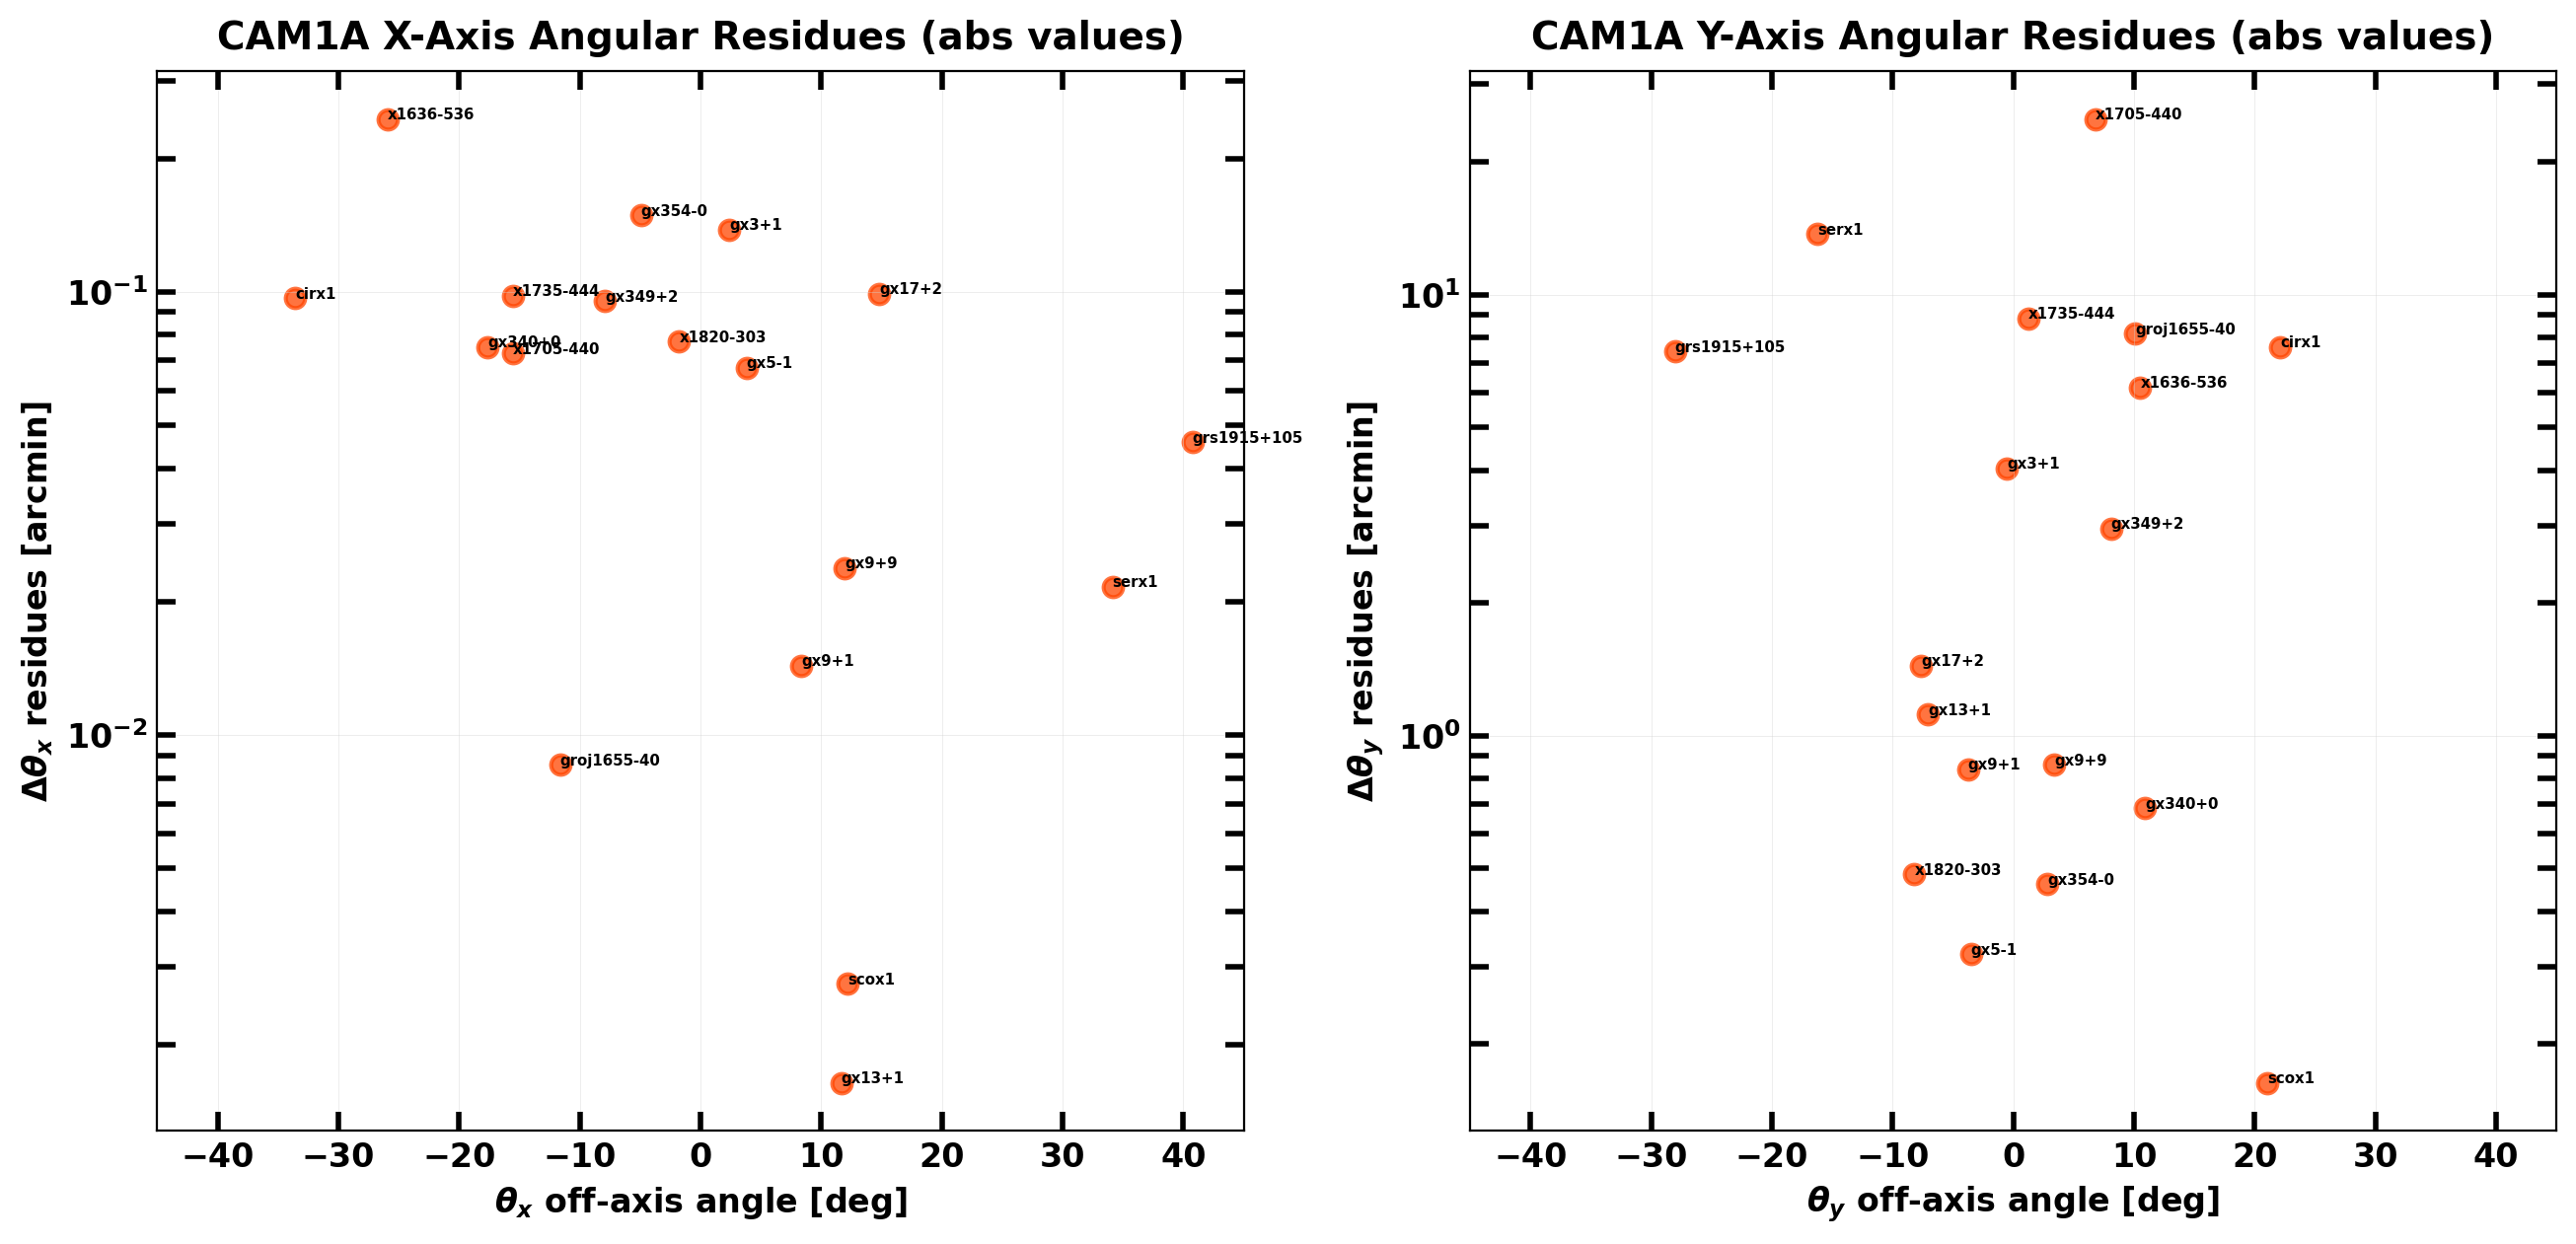

In [6]:
from typing import NamedTuple

from bloodmoon.mask import CodedMaskCamera
from bloodmoon.types import CoordEquatorial
from bloodmoon.coords import equatorial2shift, shift2angle

from darksun.types import Tag
from darksun.data import Log, DataLoader, CatalogueLoader

class CoordAngular(NamedTuple):
    """
    Local frame coded-mask camera angular coordinates.

    Args:
        theta_x (float): Angular coord along x-axis [deg]
        theta_y (float): Angular coord along y-axis [deg]
    """
    theta_x: float
    theta_y: float

def extract_catalogue_equatorial_coords(
    log: Log,
    catalogue: CatalogueLoader,
) -> tuple[tuple[str, CoordEquatorial]]:
    """
    """
    sources, ras, decs = [], [], []
    for s_id in log.log['ID']:
        if s_id in catalogue.DLdata['ID']:
            source = catalogue.DLdata[(catalogue.DLdata['ID'] == s_id)]
            sources.append(s_id)
            ras.append(source['RA'])
            decs.append(source['DEC'])
        else:
            print(f'Source {s_id.upper()} not in catalogue...')
            sources.append(s_id)
            ras.append(-999)
            decs.append(-999)
    return tuple(
        (name, CoordEquatorial(ra, dec)) for name, ra, dec in zip(sources, ras, decs)
    )

def extract_catalogue_angular_coords(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> tuple[tuple[str, CoordAngular]]:
    """
    """
    sources, thetas_x, thetas_y = [], [], []
    for s_id in log.log['ID']:
        if s_id in catalogue.DLdata['ID']:
            source = catalogue.DLdata[(catalogue.DLdata['ID'] == s_id)]
            sources.append(s_id)
            sx, sy = equatorial2shift(sdl, camera, source['RA'], source['DEC'])
            thetas_x.append(shift2angle(camera, sx))
            thetas_y.append(shift2angle(camera, sy))
        else:
            print(f'Source {s_id.upper()} not in catalogue...')
            sources.append(s_id)
            thetas_x.append(np.nan)
            thetas_y.append(np.nan)
    return tuple(
        (name, CoordAngular(tx, ty)) for name, tx, ty in zip(sources, thetas_x, thetas_y)
    )


_, cat_theta = zip(
    *extract_catalogue_angular_coords(log=log_camA, catalogue=catalogueA, sdl=sdlA, camera=wfm)
)
cat_thetax, cat_thetay = zip(*cat_theta)

tagsx = tuple(
    Tag(n, r, t) for n, r, t in zip(
        log_camA.log['ID'], 60 * np.abs(np.array(log_camA.log['angle_x']) - np.array(cat_thetax)), cat_thetax,
    )
)
dmapx = ds.map4biplot(
    arrs=60 * np.abs(np.array(log_camA.log['angle_x']) - np.array(cat_thetax)),
    title=f'{log_camA.name} X-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{x}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{x}}$ residues [arcmin]',
    x=np.array(cat_thetax),
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tagsx,
)
tagsy = tuple(
    Tag(n, r, t) for n, r, t in zip(
        log_camA.log['ID'], 60 * np.abs(np.array(log_camA.log['angle_y']) - np.array(cat_thetay)), cat_thetay,
    )
)
dmapy = ds.map4biplot(
    arrs=60 * np.abs(np.array(log_camA.log['angle_y']) - np.array(cat_thetay)),
    title=f'{log_camA.name} Y-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{y}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{y}}$ residues [arcmin]',
    x=np.array(cat_thetay),
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tagsy,
)
ds.biplot(dmapx, dmapy, is_img('theta_res'))

In [7]:
from typing import Any
from numpy.typing import NDArray
from pandas import DataFrame

def dict2df(data: dict[str, dict[str, Any]]) -> DataFrame:
    """
    Converts input data in a Pandas dataframe.

    Args:
        data (dict): Input data.
    
    Returns:
        output (DataFrame): Output dataframe.
    """
    df = DataFrame({
        (cam, param): values
        for cam, cam_data in data.items() 
        for param, values in cam_data.items()
    })
    return df


def get_angularcoords_residues(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> tuple[NDArray, NDArray]:
    """
    """
    _, cat_theta = zip(
        *extract_catalogue_angular_coords(log=log, catalogue=catalogue, sdl=sdl, camera=camera)
    )
    cat_thetax, cat_thetay = zip(*cat_theta)
    resx = 60 * np.abs(np.array(log.log['angle_x']) - np.array(cat_thetax))
    resy = 60 * np.abs(np.array(log.log['angle_y']) - np.array(cat_thetay))
    return resx, resy

resxA, resyA = get_angularcoords_residues(log=log_camA, catalogue=catalogueA, sdl=sdlA, camera=wfm)
resxB, resyB = get_angularcoords_residues(log=log_camB, catalogue=catalogueB, sdl=sdlB, camera=wfm)

dmapA = {
    log_camA.name: {
        'ID': log_camA.log['ID'],
        'SNR': log_camA.log['snr'],
        'DthetaX [arcmin]': resxA,
        'DthetaY [arcmin]': resyA,
    },
}

dmapB = {
    log_camB.name: {
        'ID': log_camB.log['ID'],
        'SNR': log_camB.log['snr'],
        'DthetaX [arcmin]': resxB,
        'DthetaY [arcmin]': resyB,
    },
}

Source LEMX-CAM1AS1 not in catalogue...


In [8]:
dict2df(dmapA)

CAM1A                                              
              ID         SNR DthetaX [arcmin] DthetaY [arcmin]
0          scox1  749.152433         0.002744         0.163509
1          gx5-1   78.307137         0.067463         0.319990
2        gx349+2   60.073791         0.095214         2.947947
3         gx17+2   51.405661         0.099053         1.444229
4          gx9+1   46.722344         0.014349         0.840368
5        gx340+0   34.820543         0.075151         0.685523
6    groj1655-40   29.005915         0.008560         8.167910
7          gx3+1   26.115363         0.138320         4.034684
8         gx13+1   25.410615         0.001642         1.118386
9      x1820-303   24.144542         0.077280         0.484996
10         gx9+9   23.199825         0.023794         0.859046
11         cirx1   28.257559         0.096787         7.616179
12     x1705-440   15.827236         0.072611        25.030271
13     x1735-444   13.723126         0.097918         8.849434
14       gx354-0    8.080452         0.148754         0.460684
15   grs1915+105   17.181956         0.045816         7.444333
16     x1636-536    7.619872         0.245477         6.157143
17         serx1    8.397074         0.021609        13.724945
18  lemx-cam1aS1    5.479674              NaN              NaN

In [9]:
dict2df(dmapB)

CAM1B                                              
                ID         SNR DthetaX [arcmin] DthetaY [arcmin]
0            scox1  700.803456         0.004386         0.031858
1            gx5-1   83.246508         0.070786         1.588536
2          gx349+2   58.192484         0.032491         3.878147
3           gx17+2   57.313146         0.107253         1.416015
4            gx9+1   42.861091         0.045401         0.213727
5          gx340+0   34.842933         0.070887         4.404818
6      groj1655-40   28.363349         0.316515         4.119974
7           gx13+1   27.815238         0.185405         2.086849
8            gx3+1   26.175830         0.090836        10.683110
9        x1820-303   25.064436         0.000449         0.047054
10           gx9+9   20.193261         0.036066         0.233261
11           cirx1   29.107155         0.059604         0.172927
12       x1705-440   15.507438         0.081249         8.206286
13       x1735-444   14.684073         0.208657         7.543776
14         gx354-0    7.679221         0.510667        18.996393
15     grs1915+105   20.493807         0.033233         3.151600
16      ks1731-260    6.335358         0.255386        35.652458
17  igrj17091-3624    5.935971         1.163444         0.933247
18       x1636-536    6.446486         0.222188         5.977099
19           serx1    7.237134         0.155546        11.971838

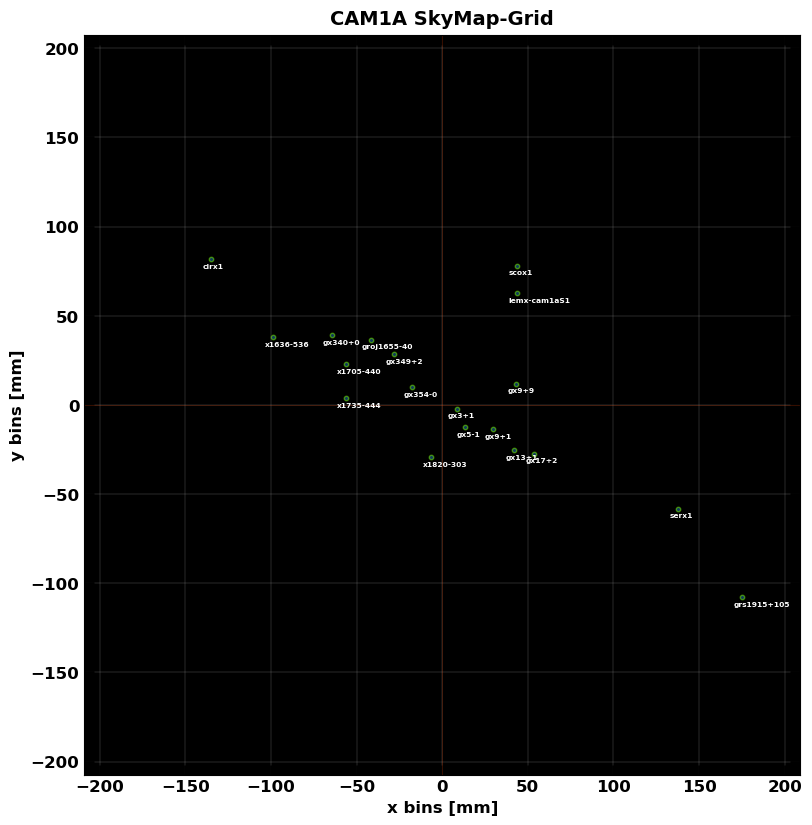

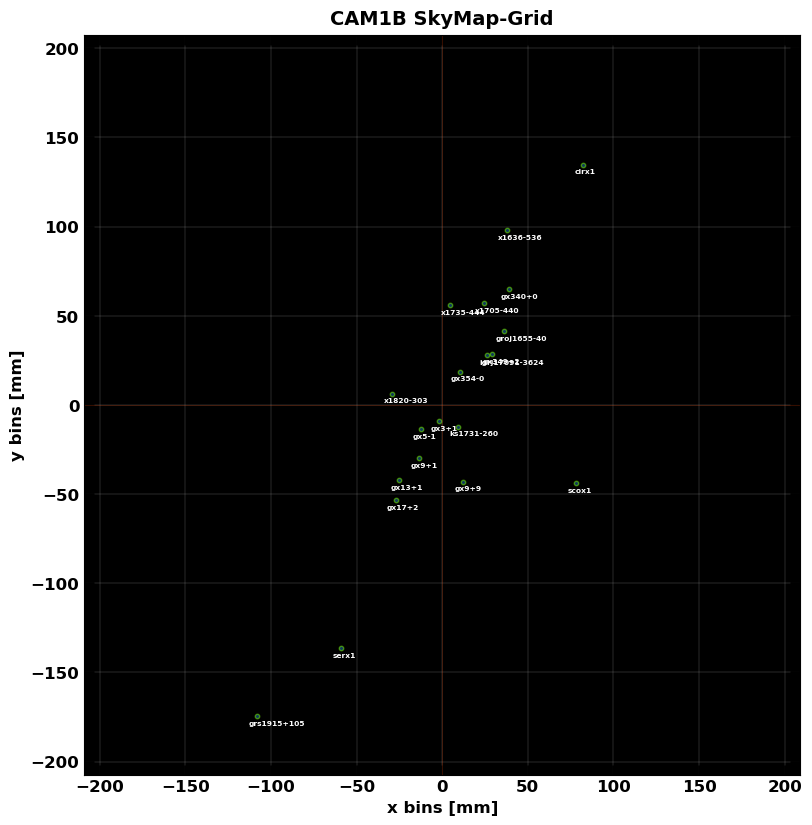

In [10]:
ds.skyfield_map(log_camA, wfm, save_to=is_img(f'skymap_grid_{log_camA.name}'))
ds.skyfield_map(log_camB, wfm, save_to=is_img(f'skymap_grid_{log_camB.name}'))

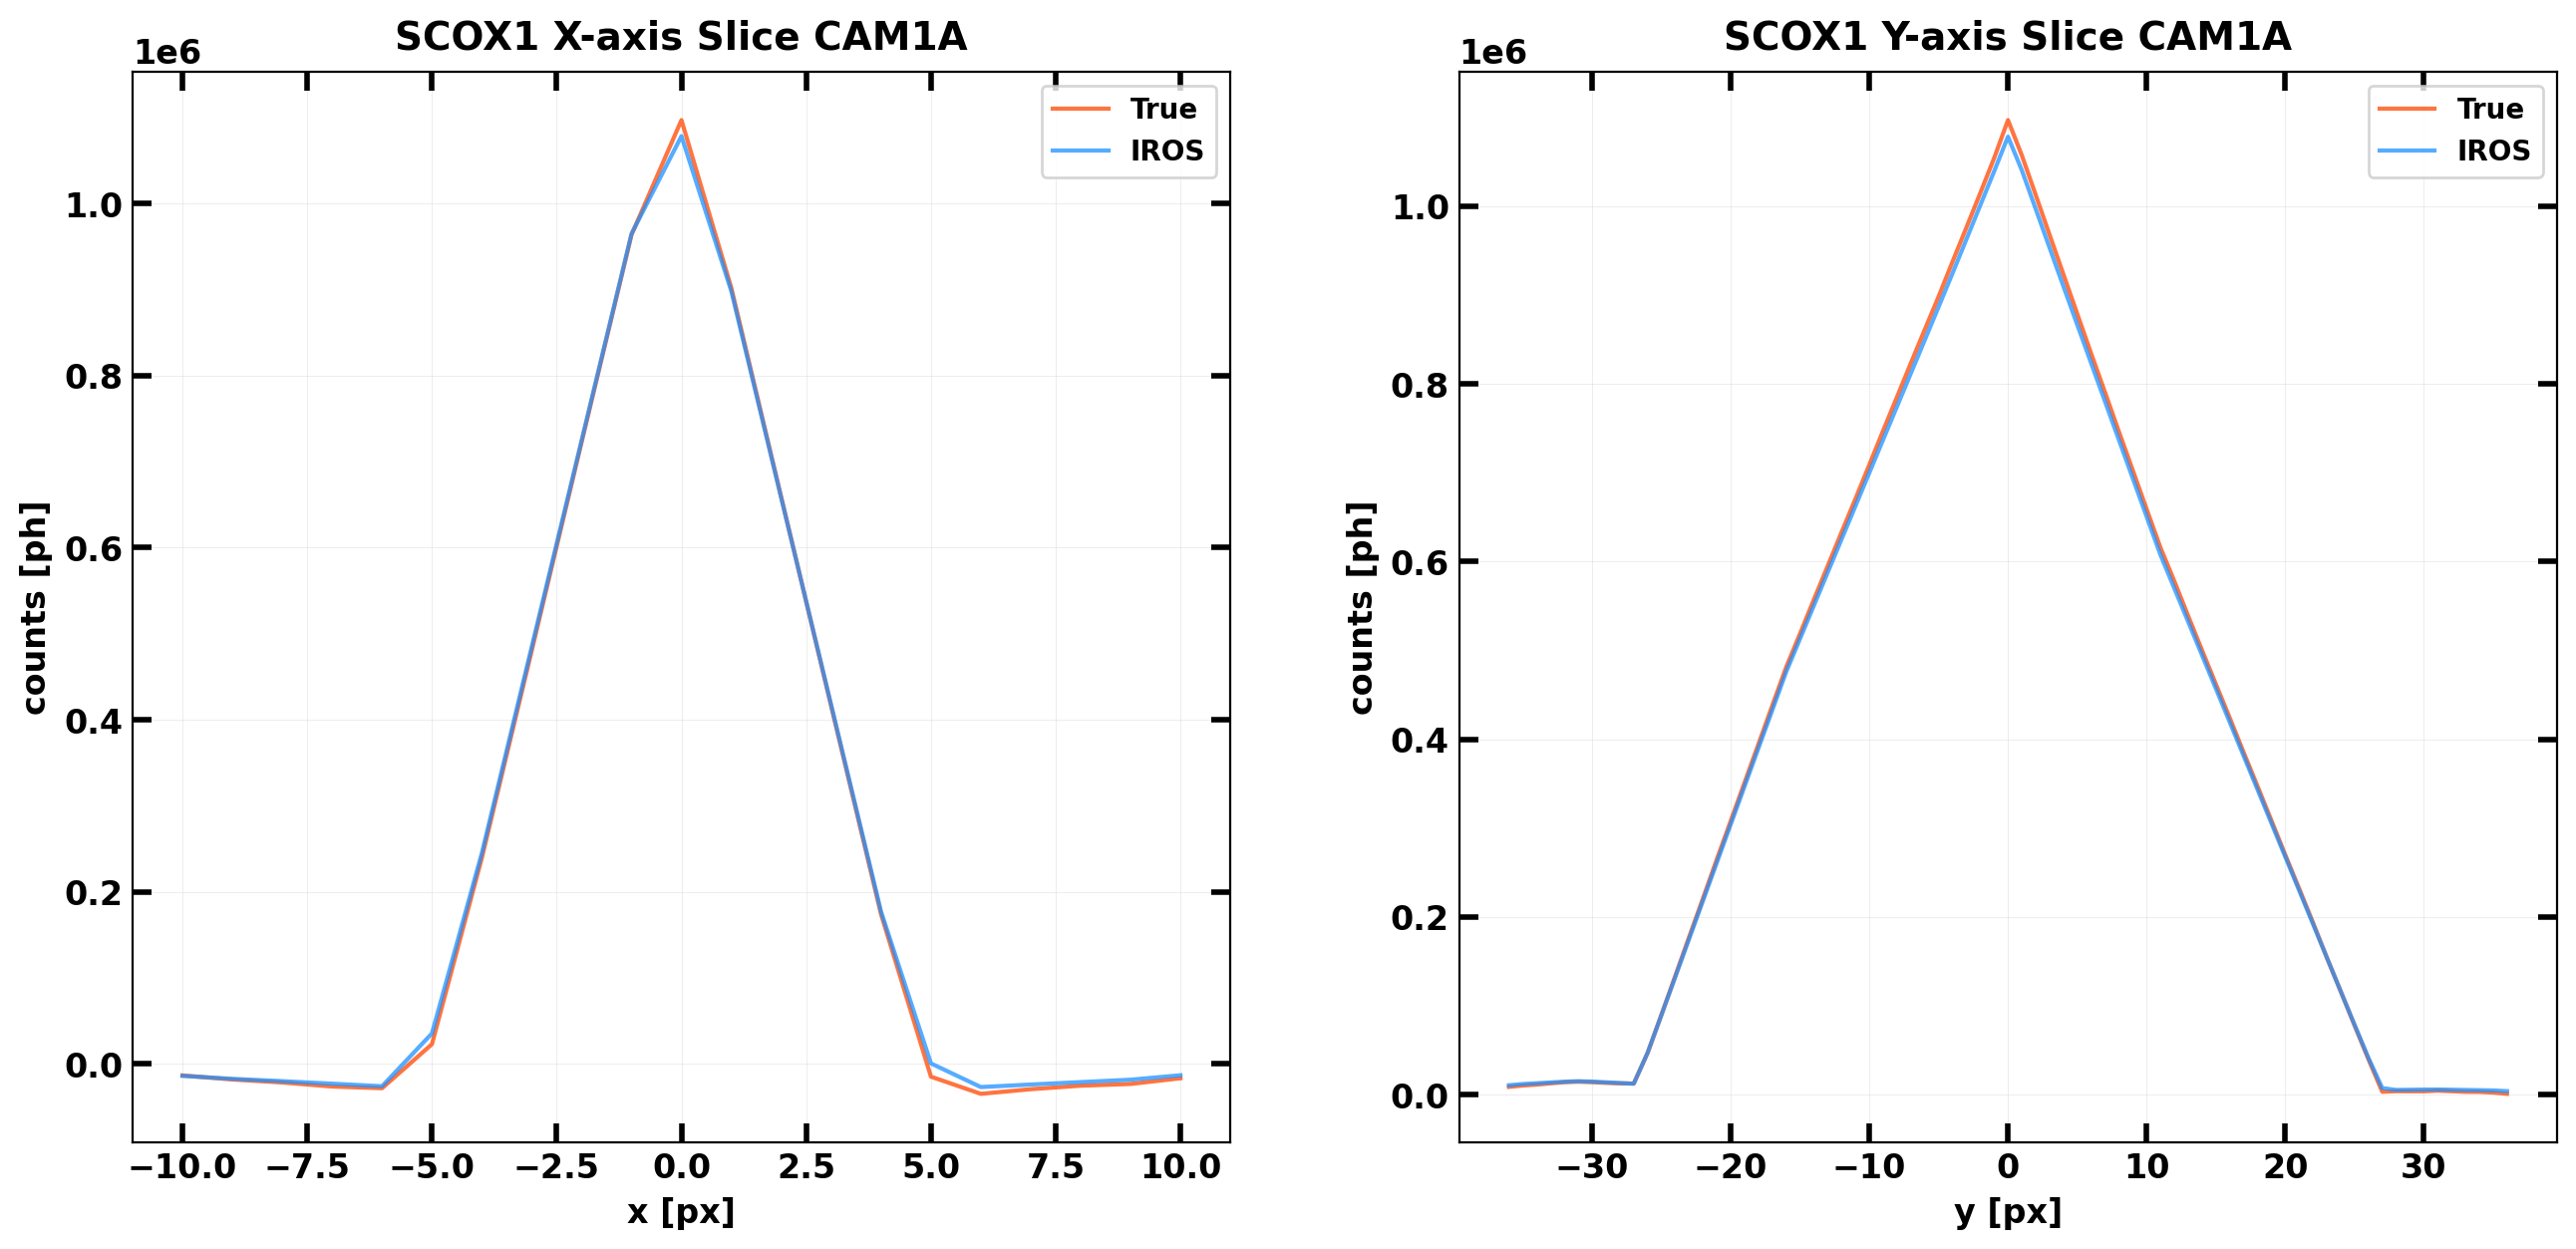

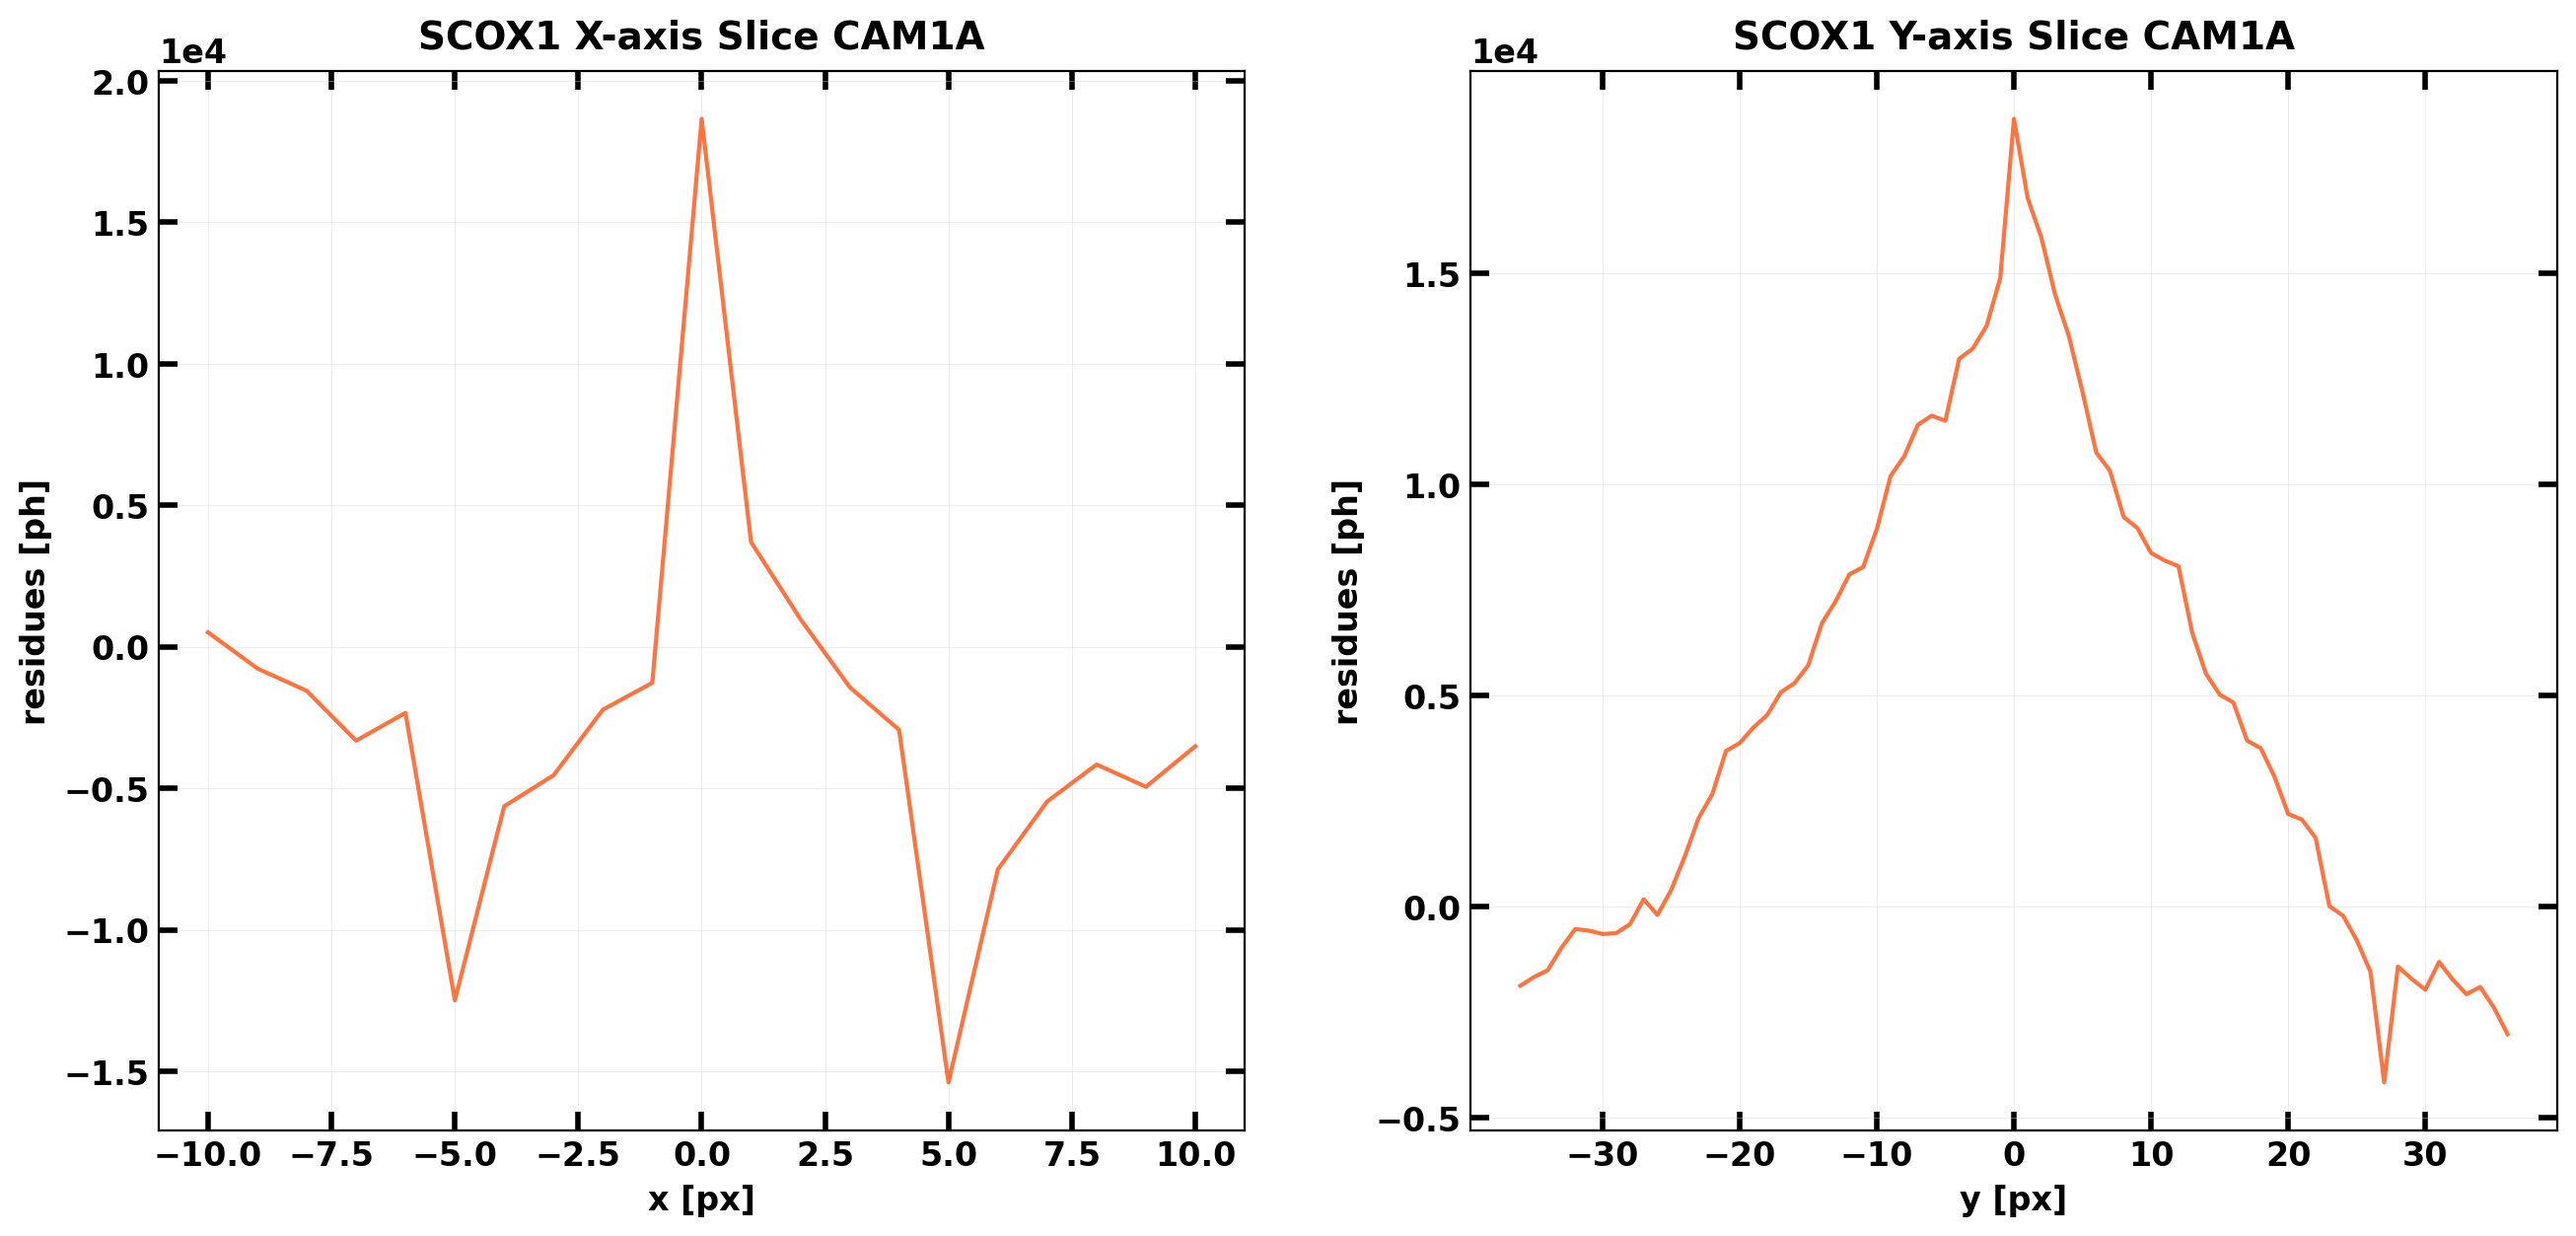

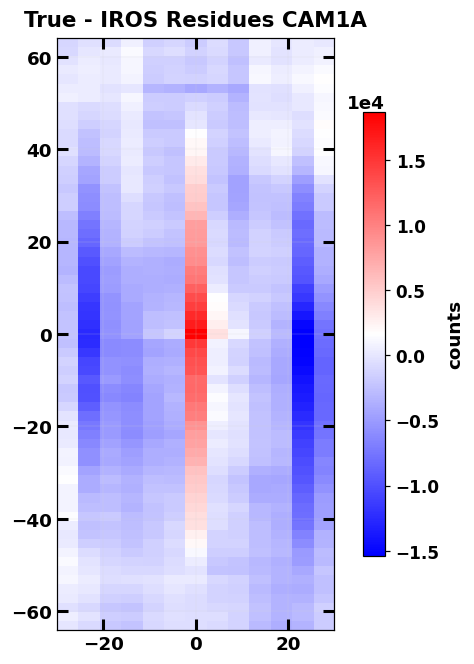

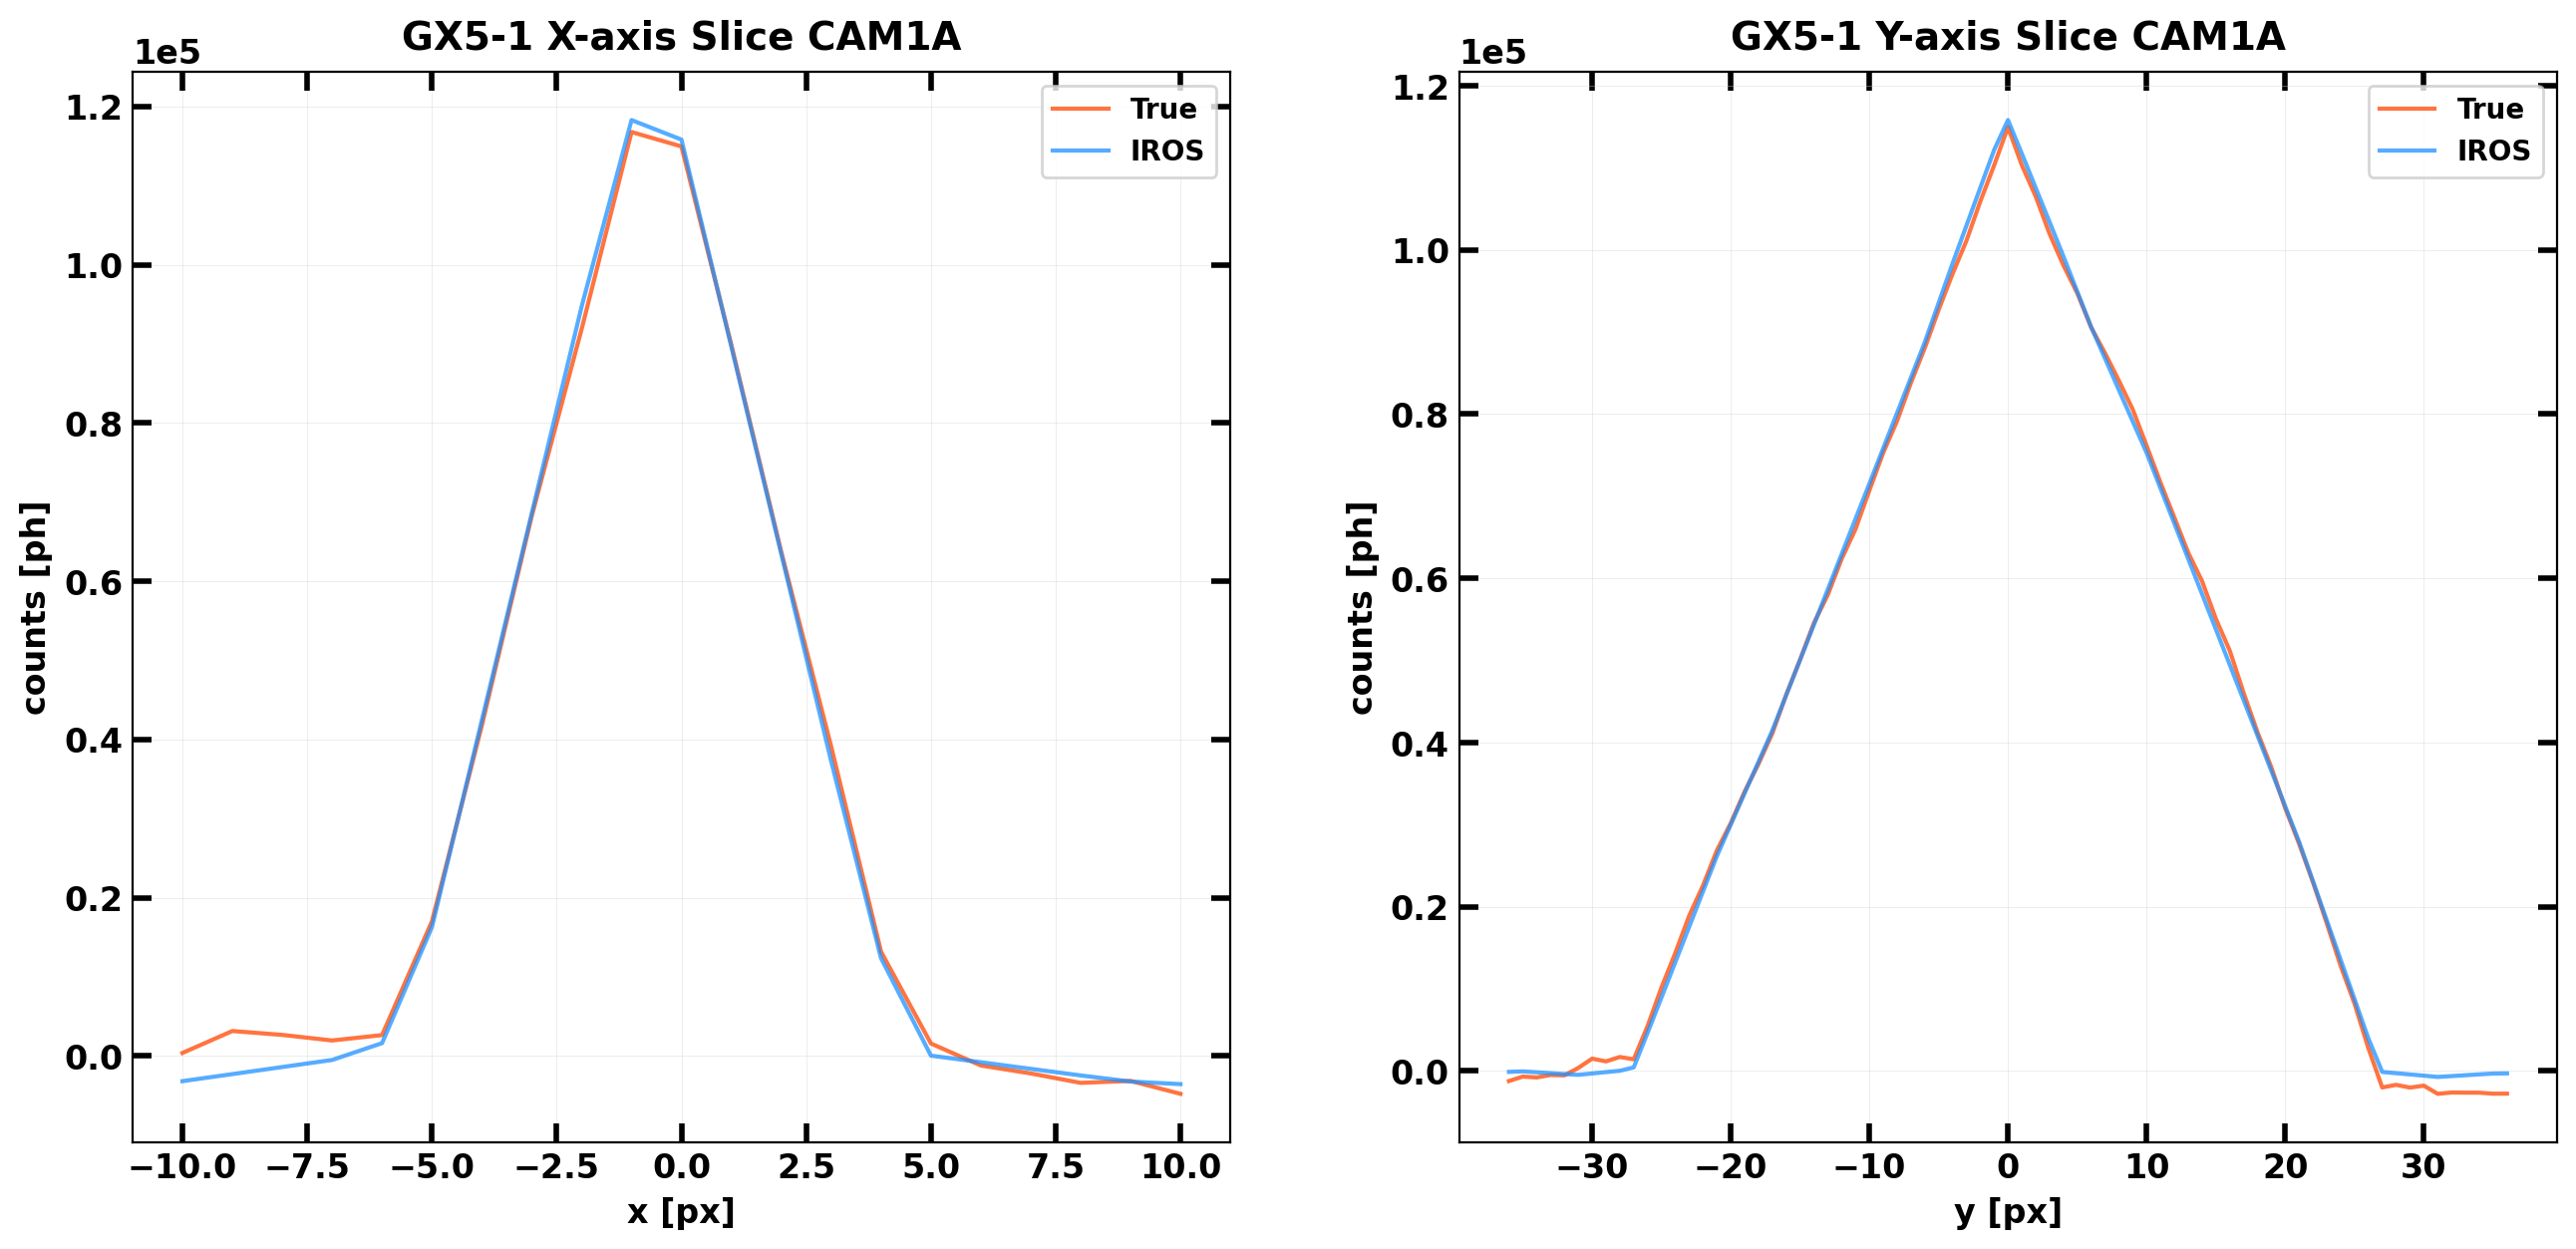

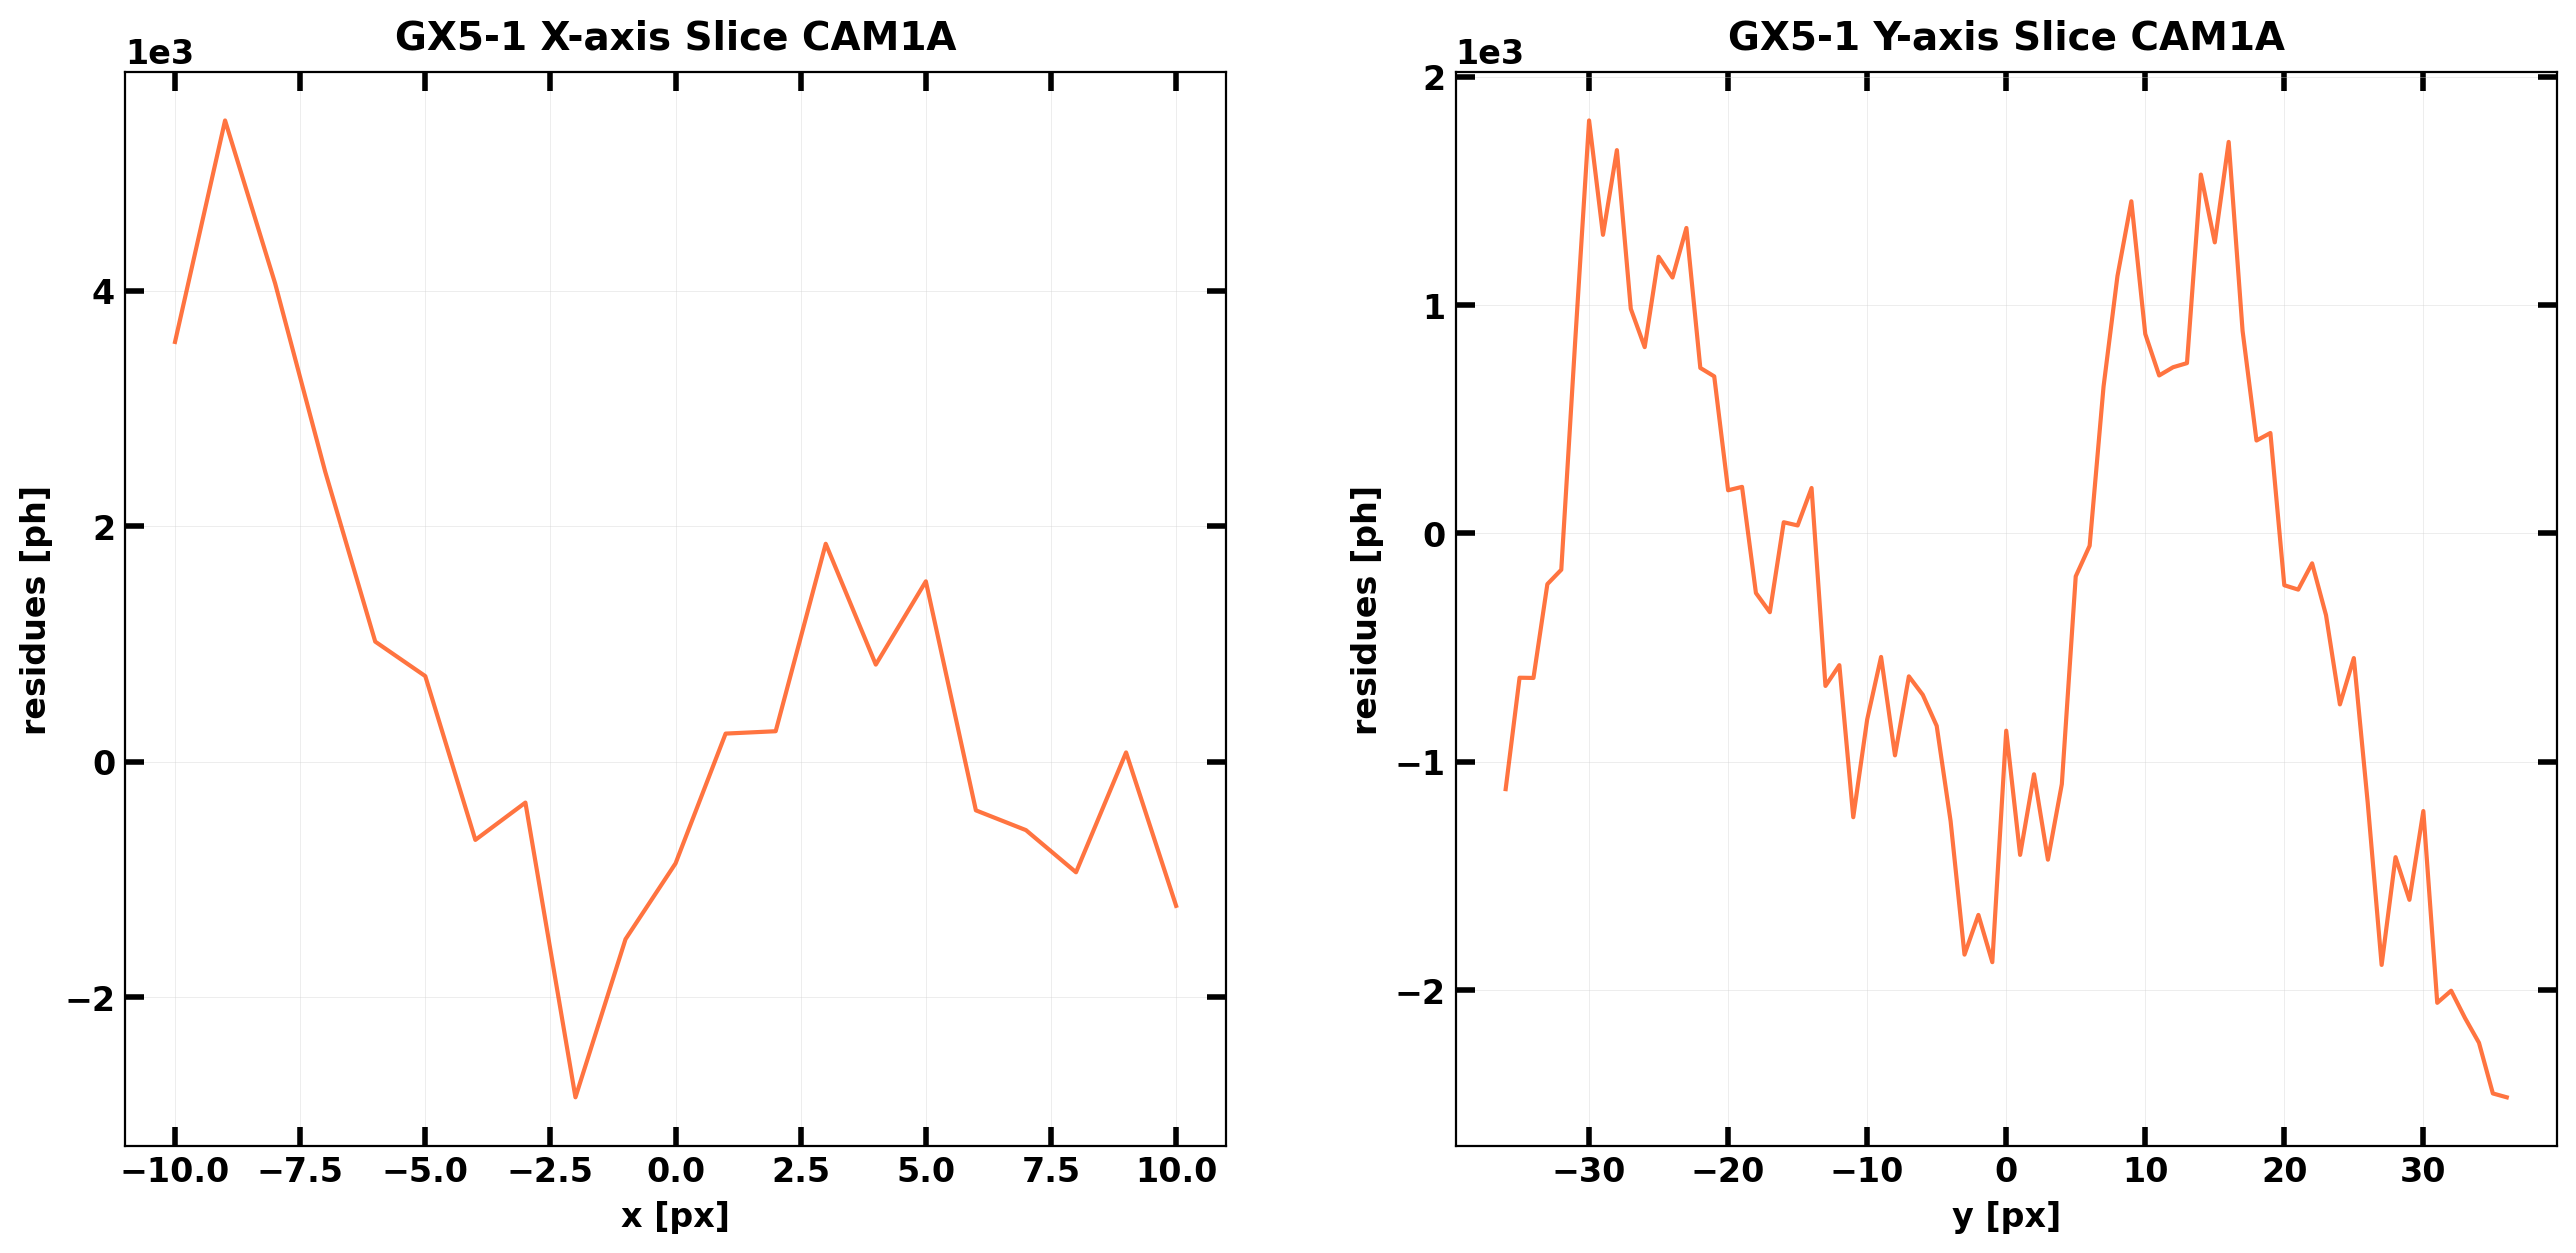

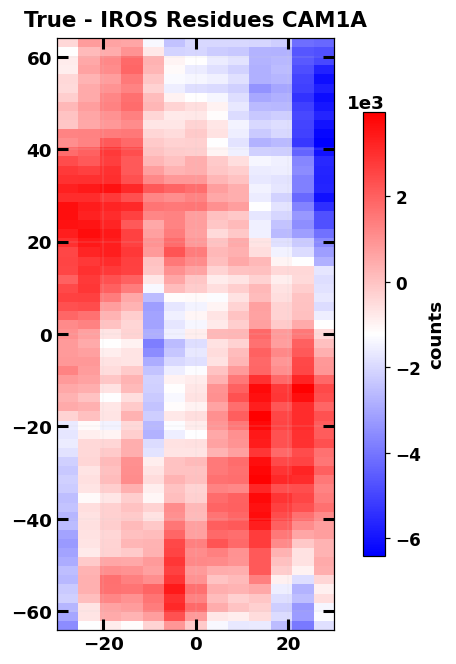

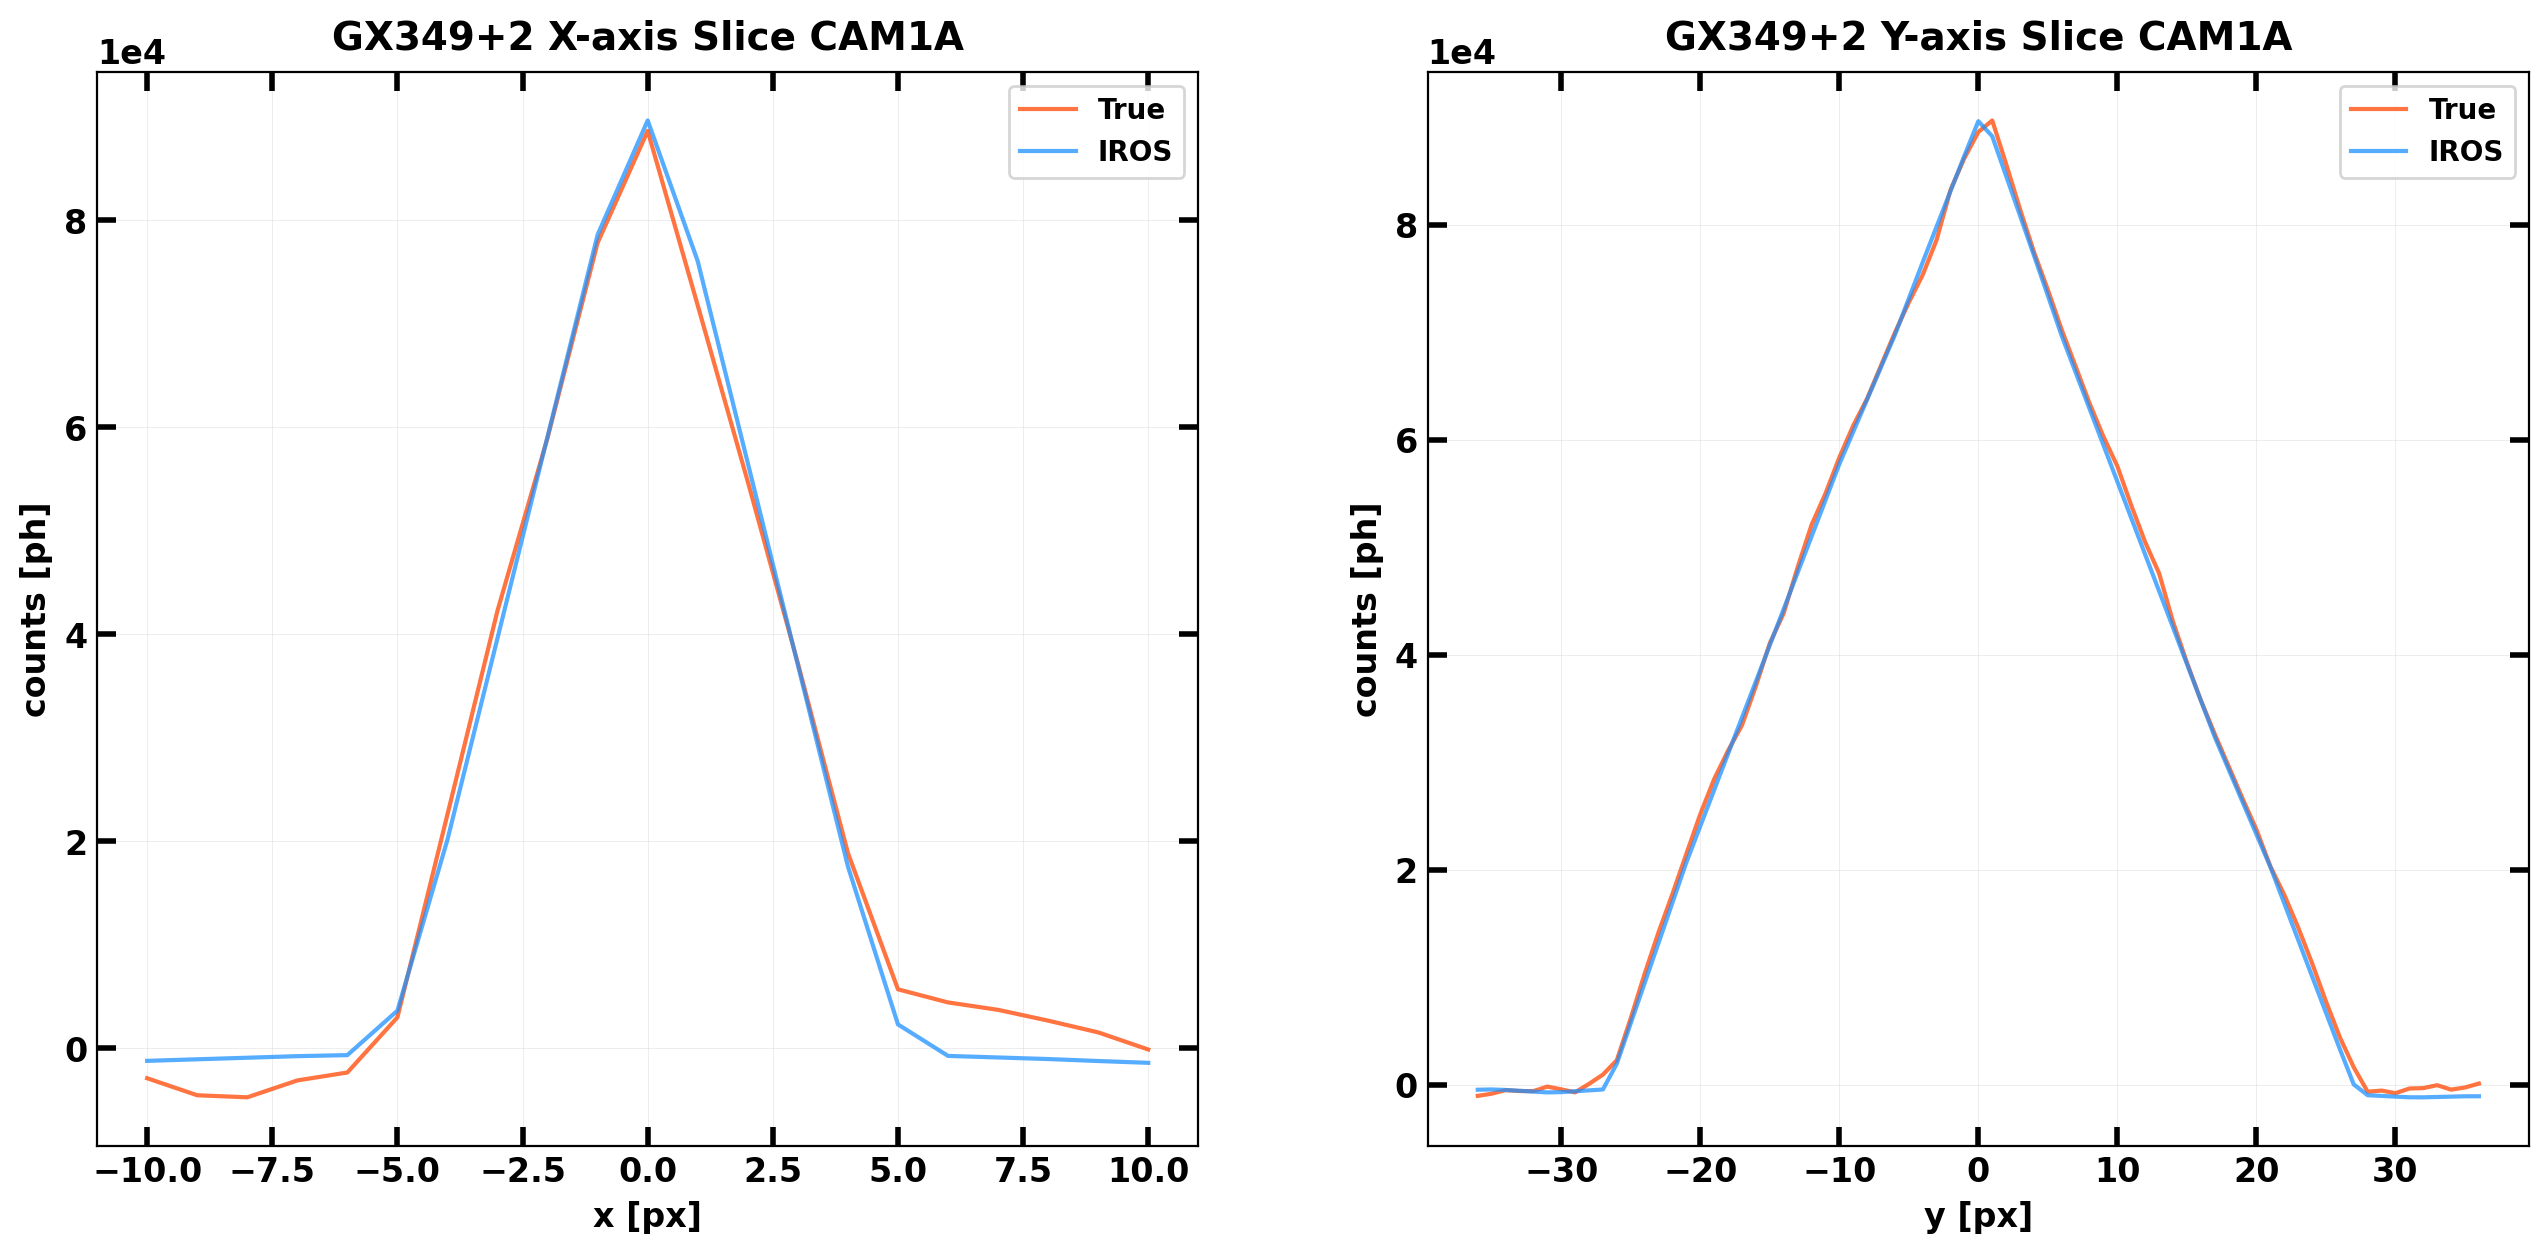

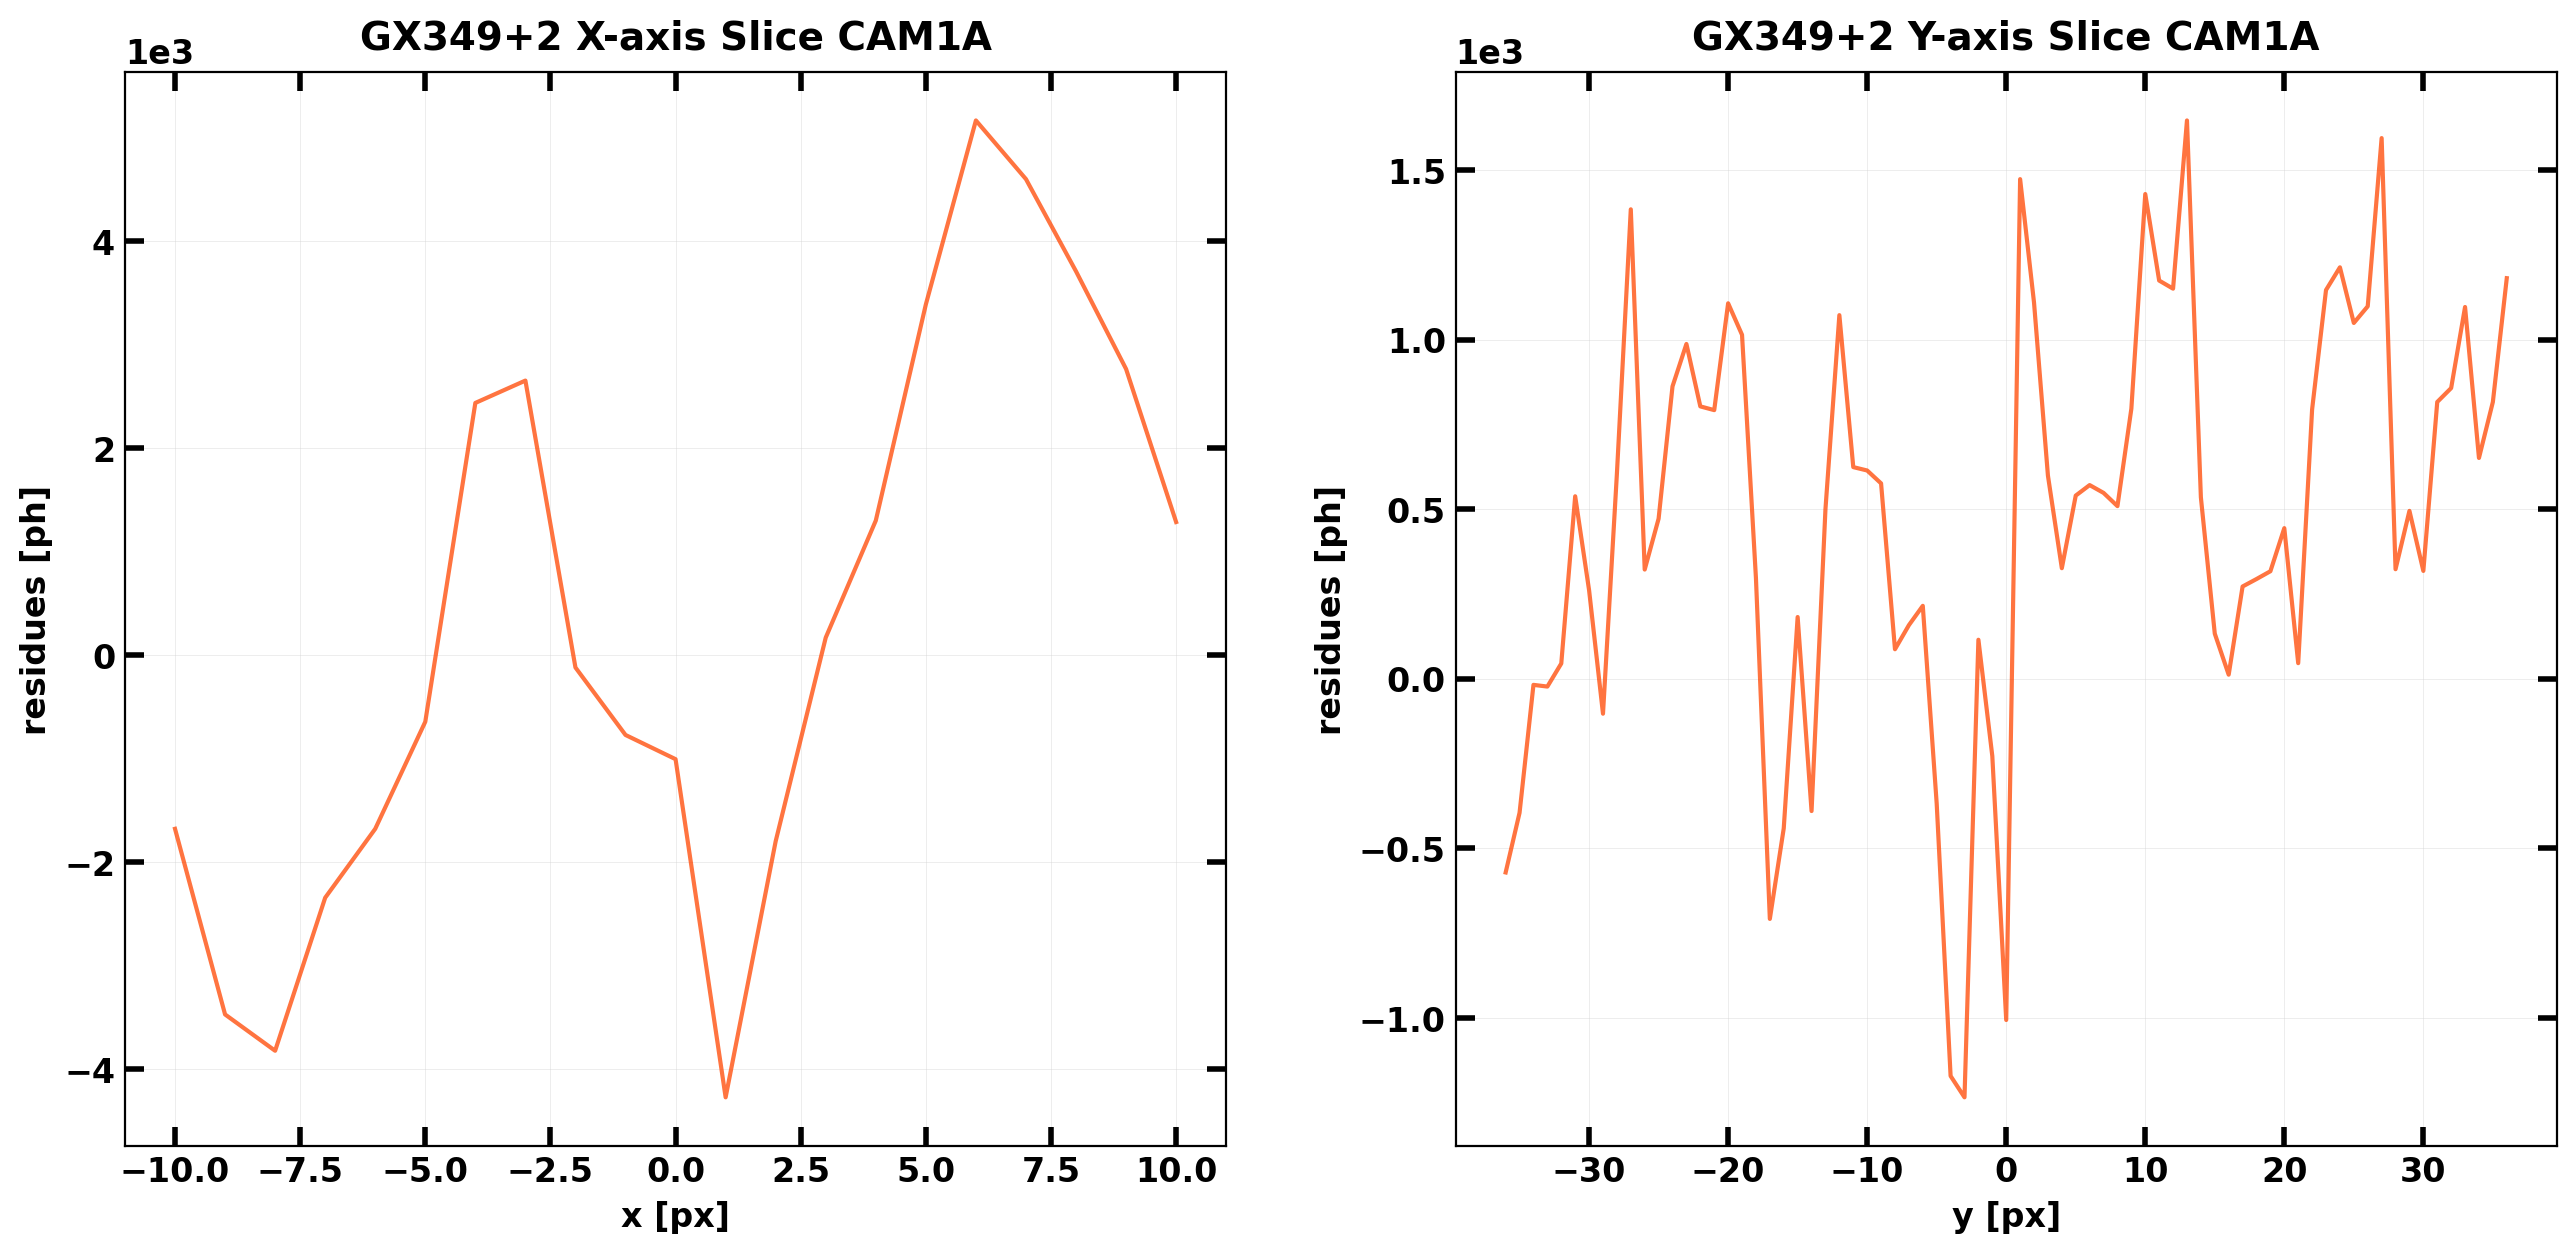

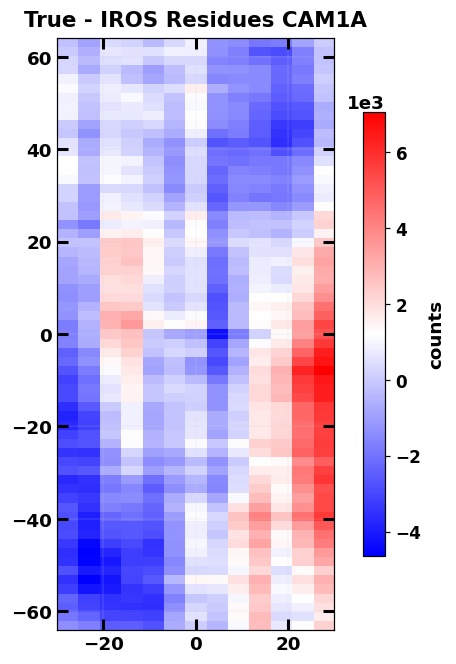

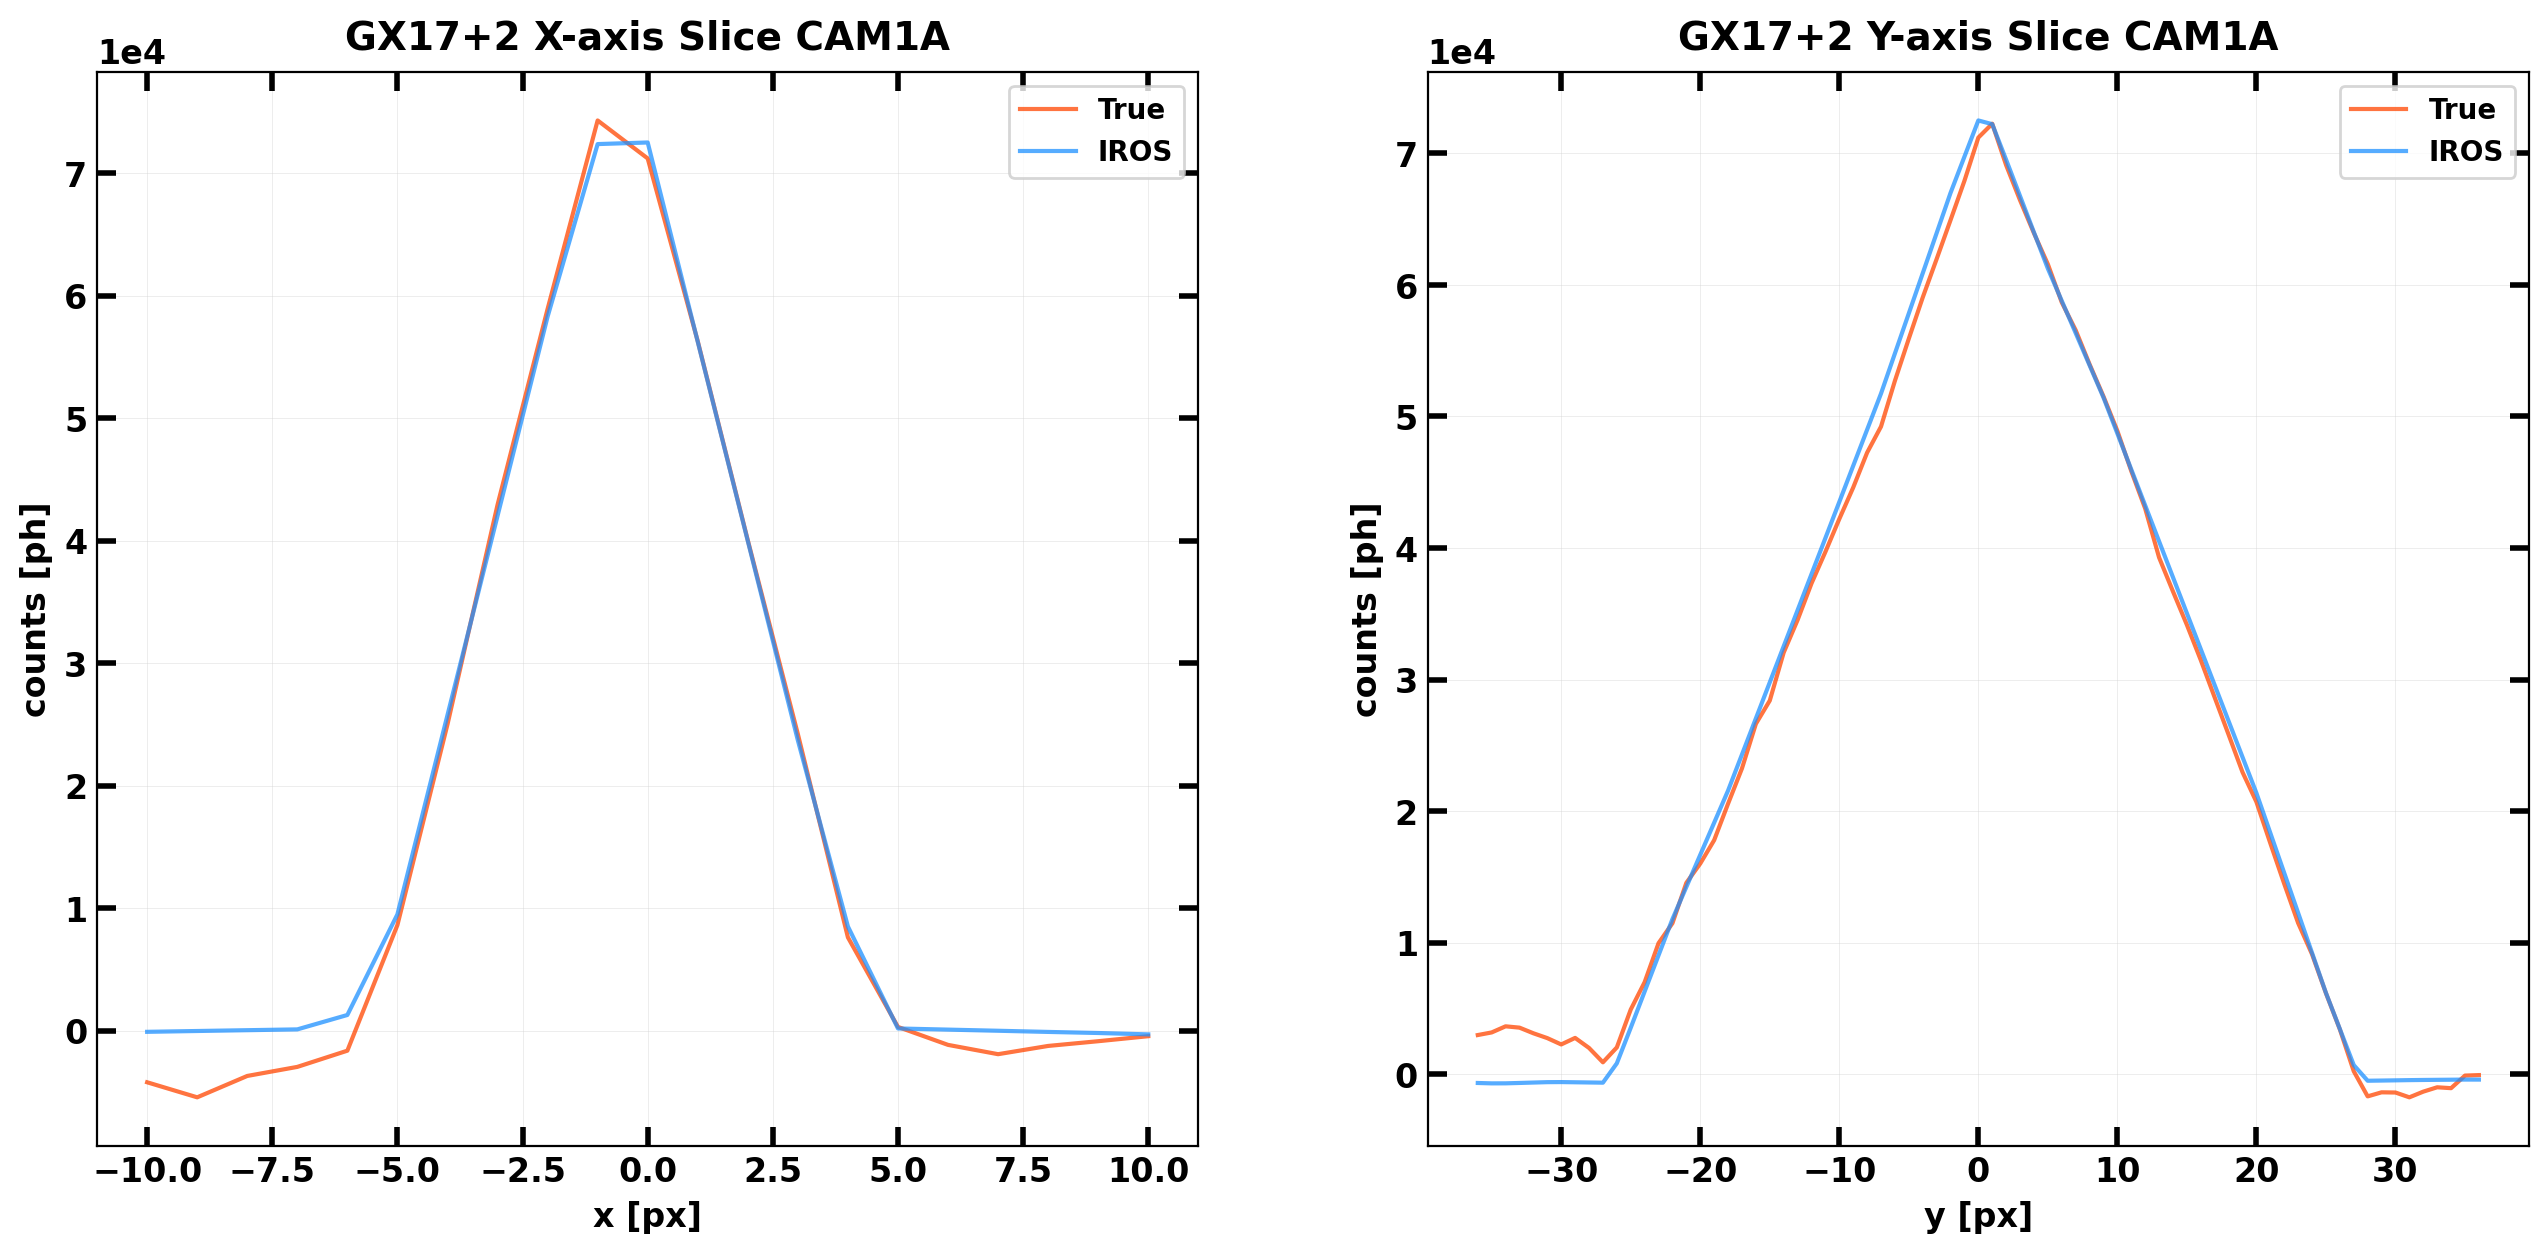

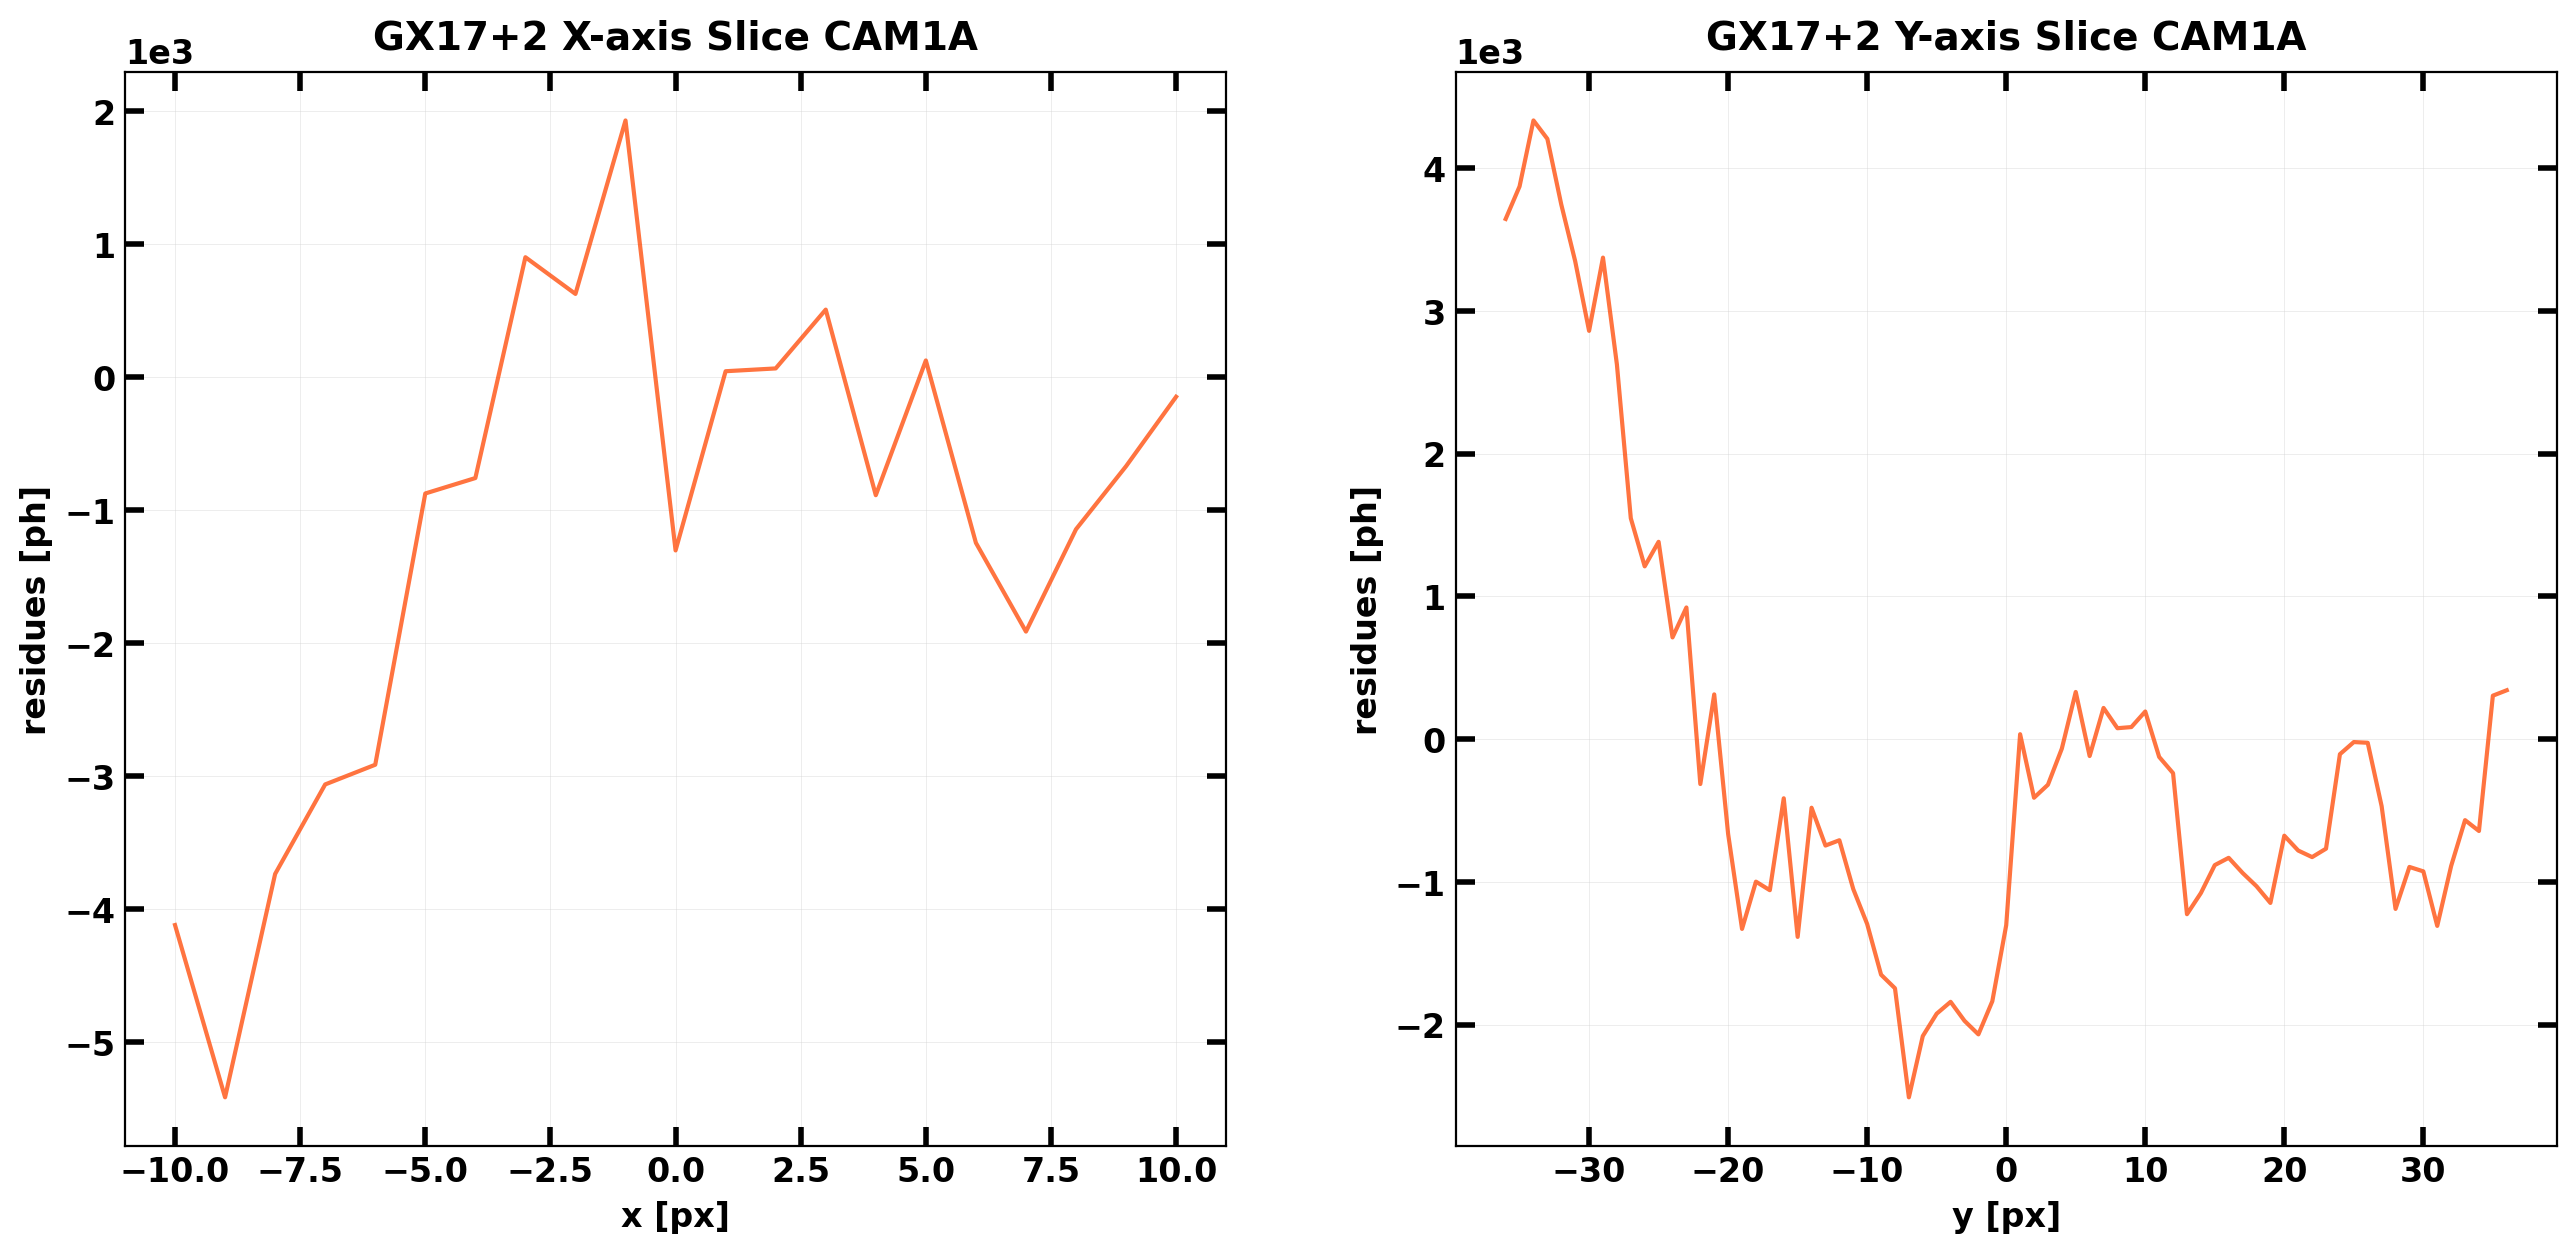

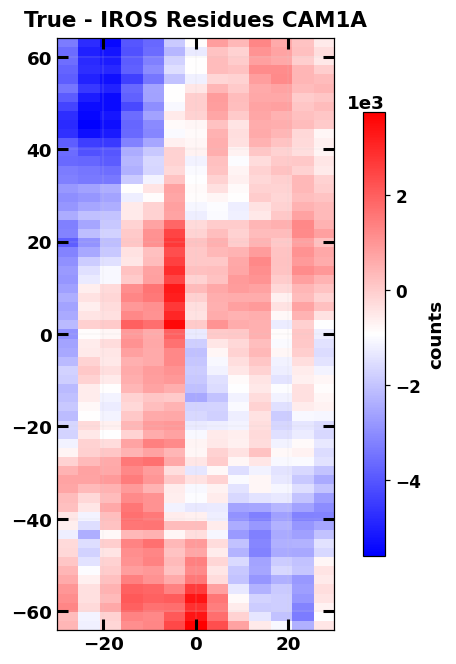

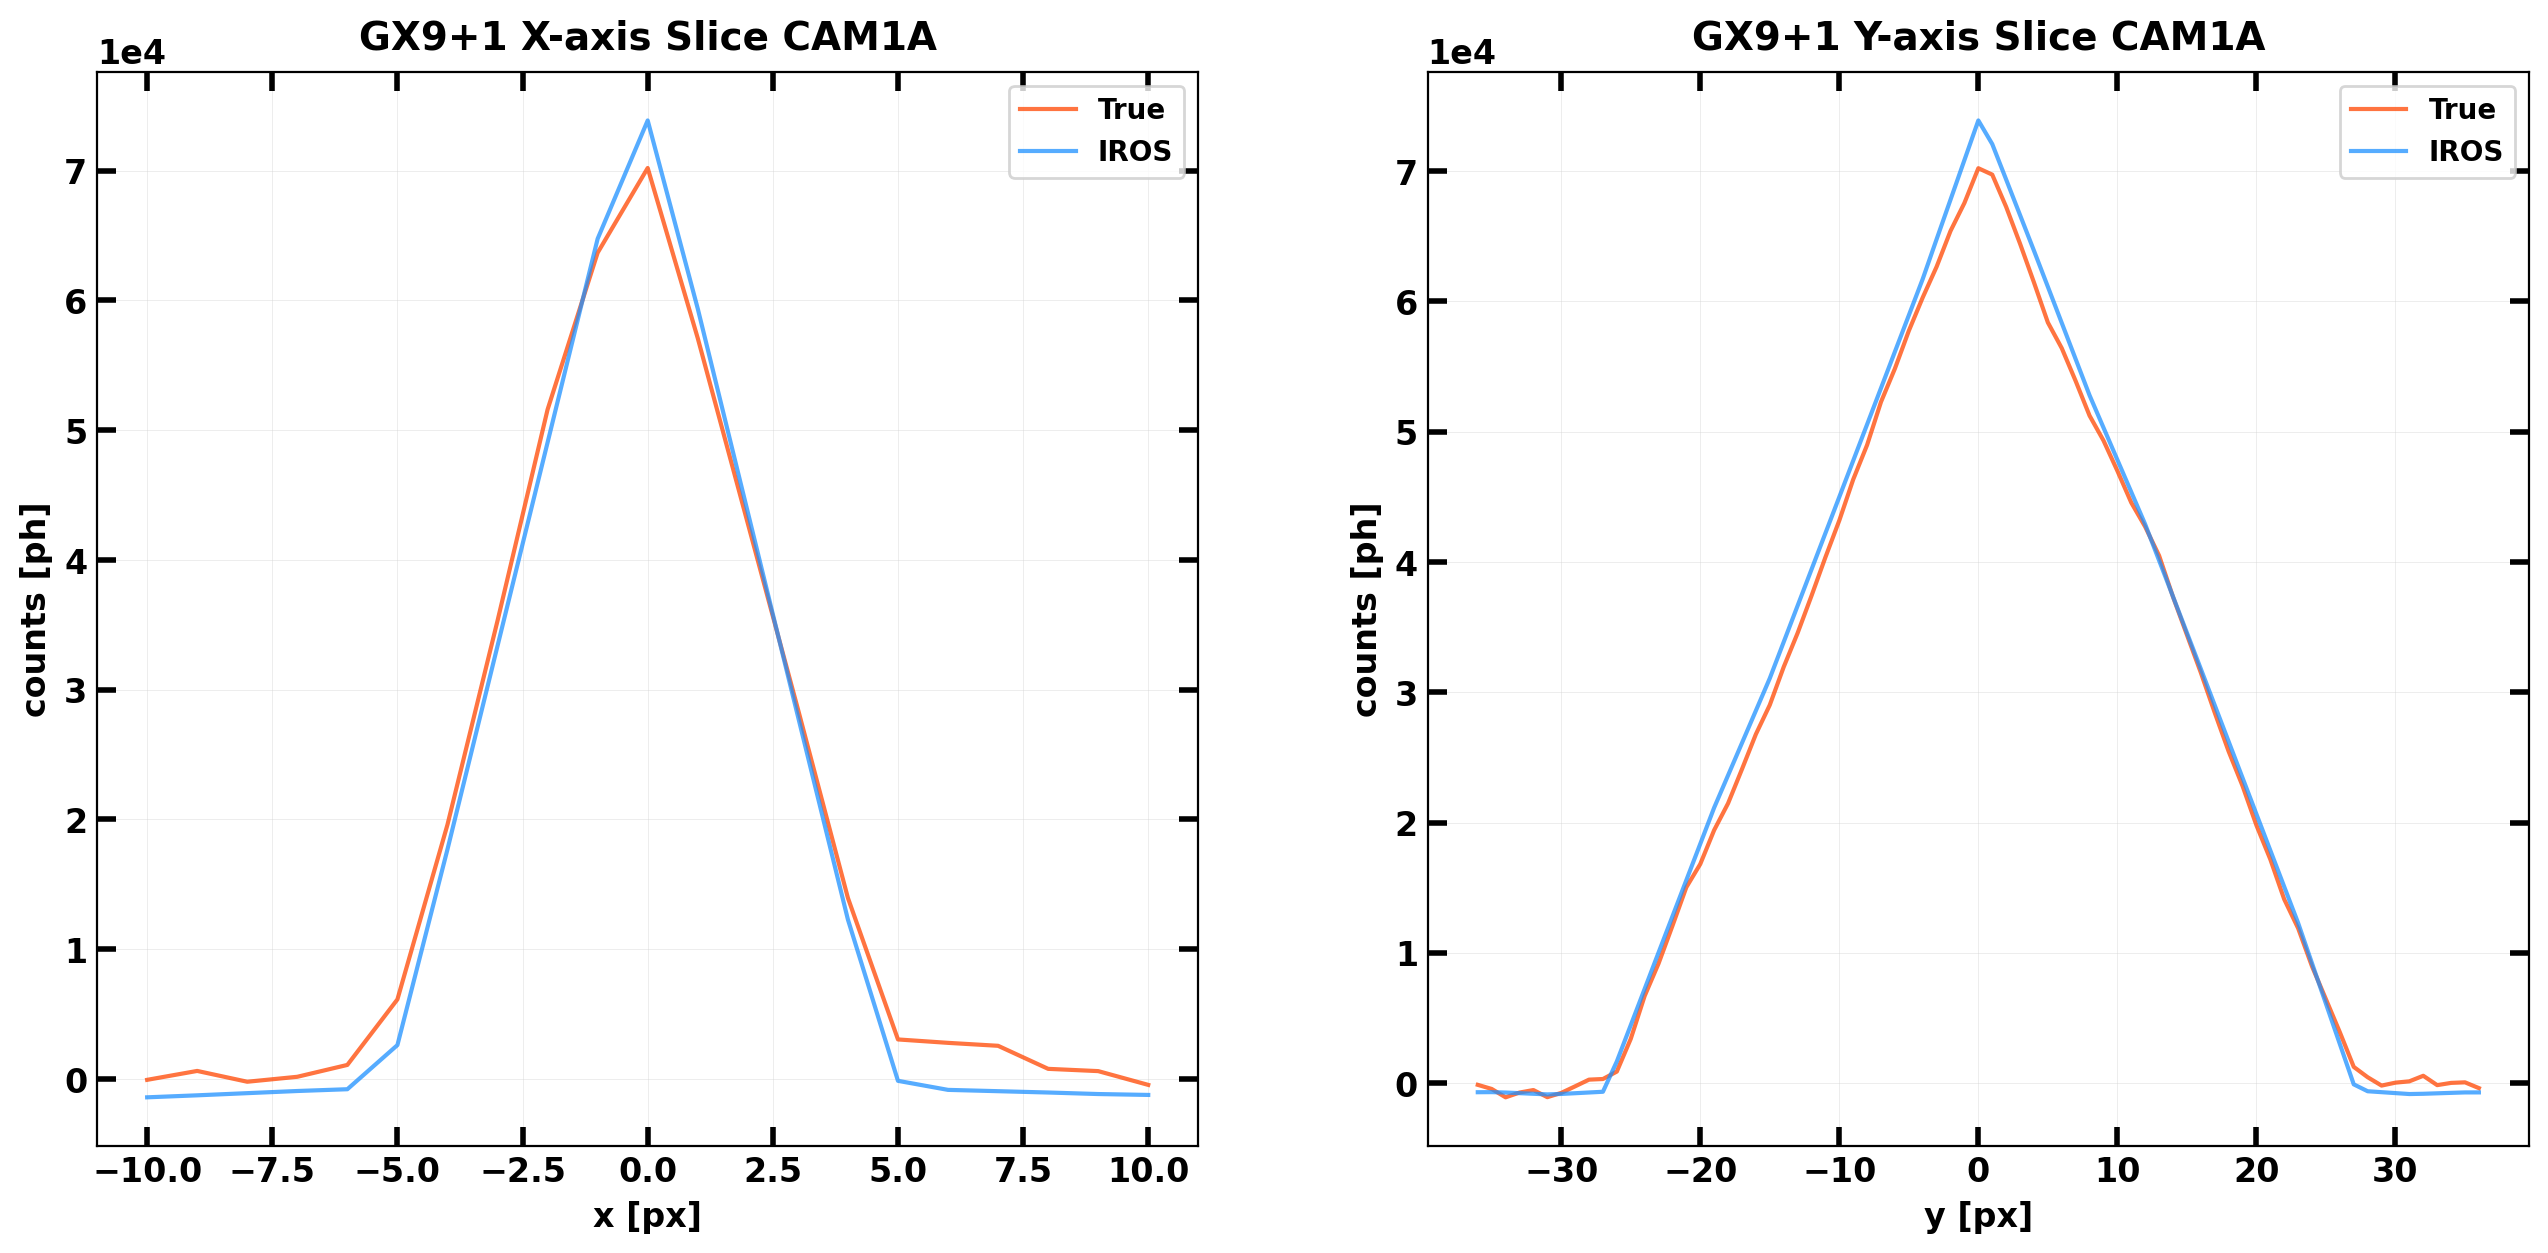

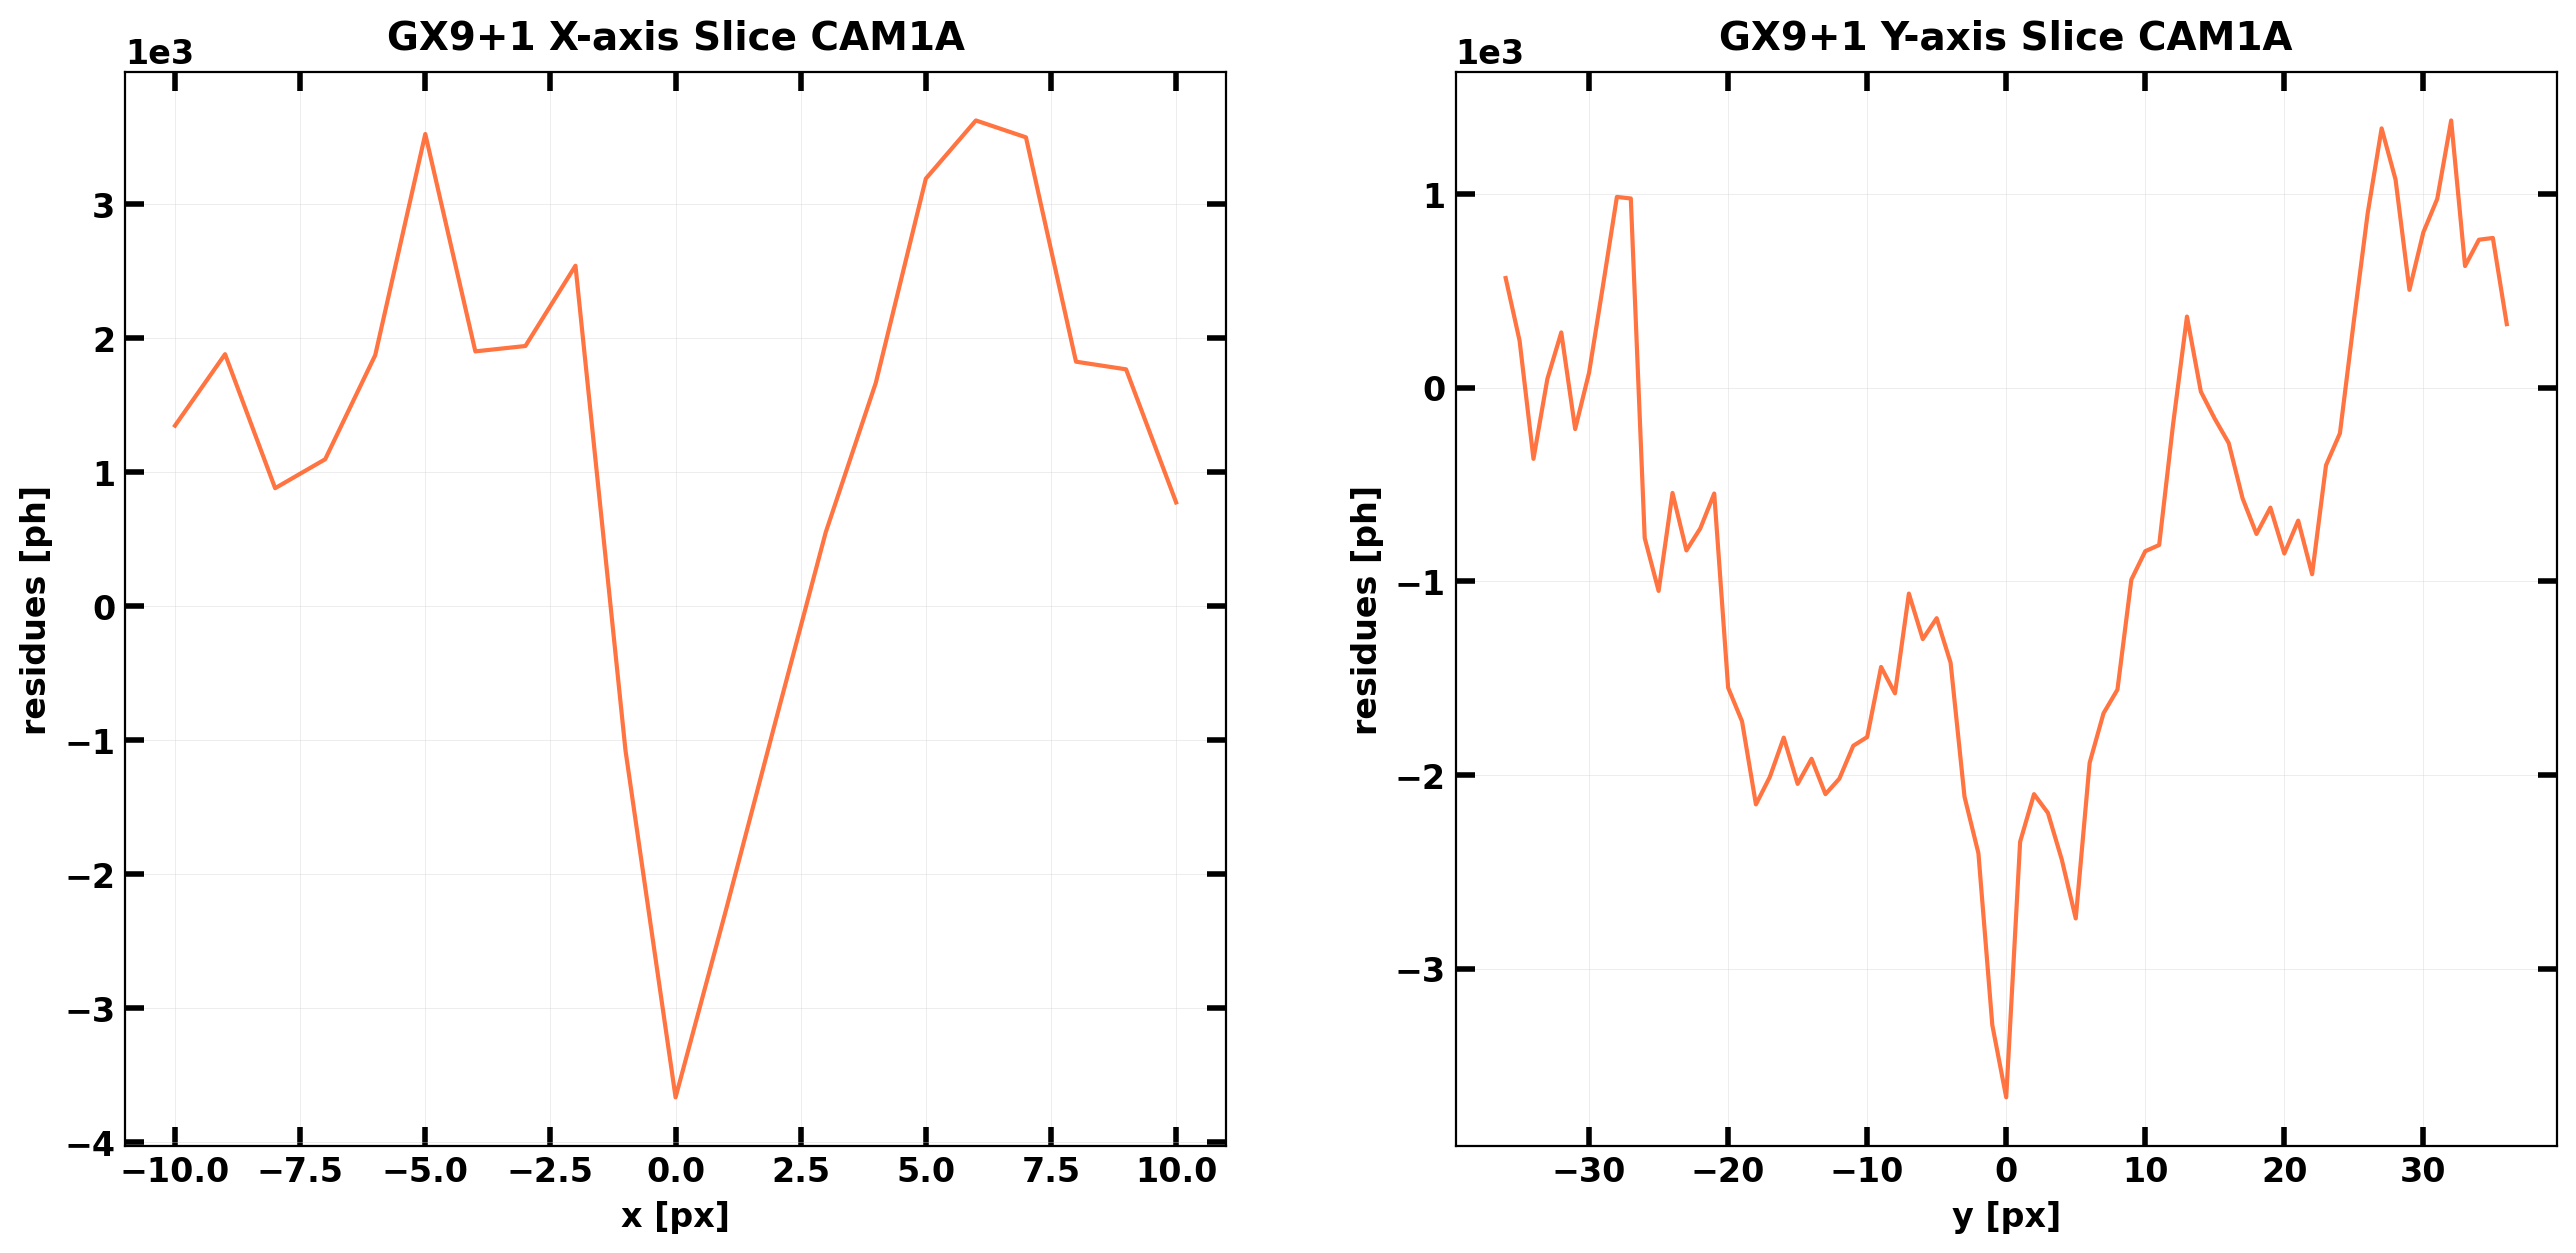

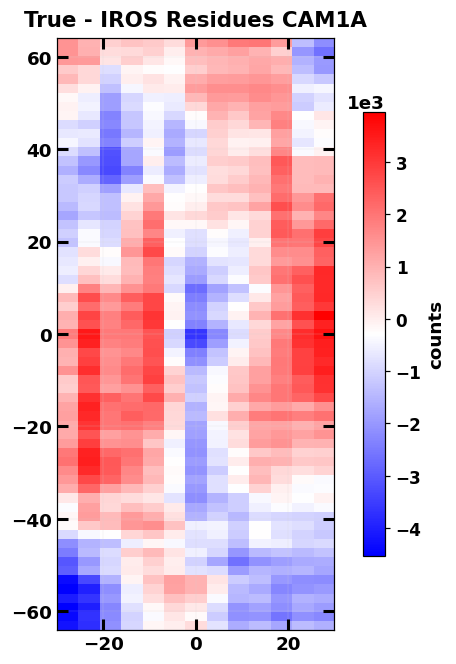

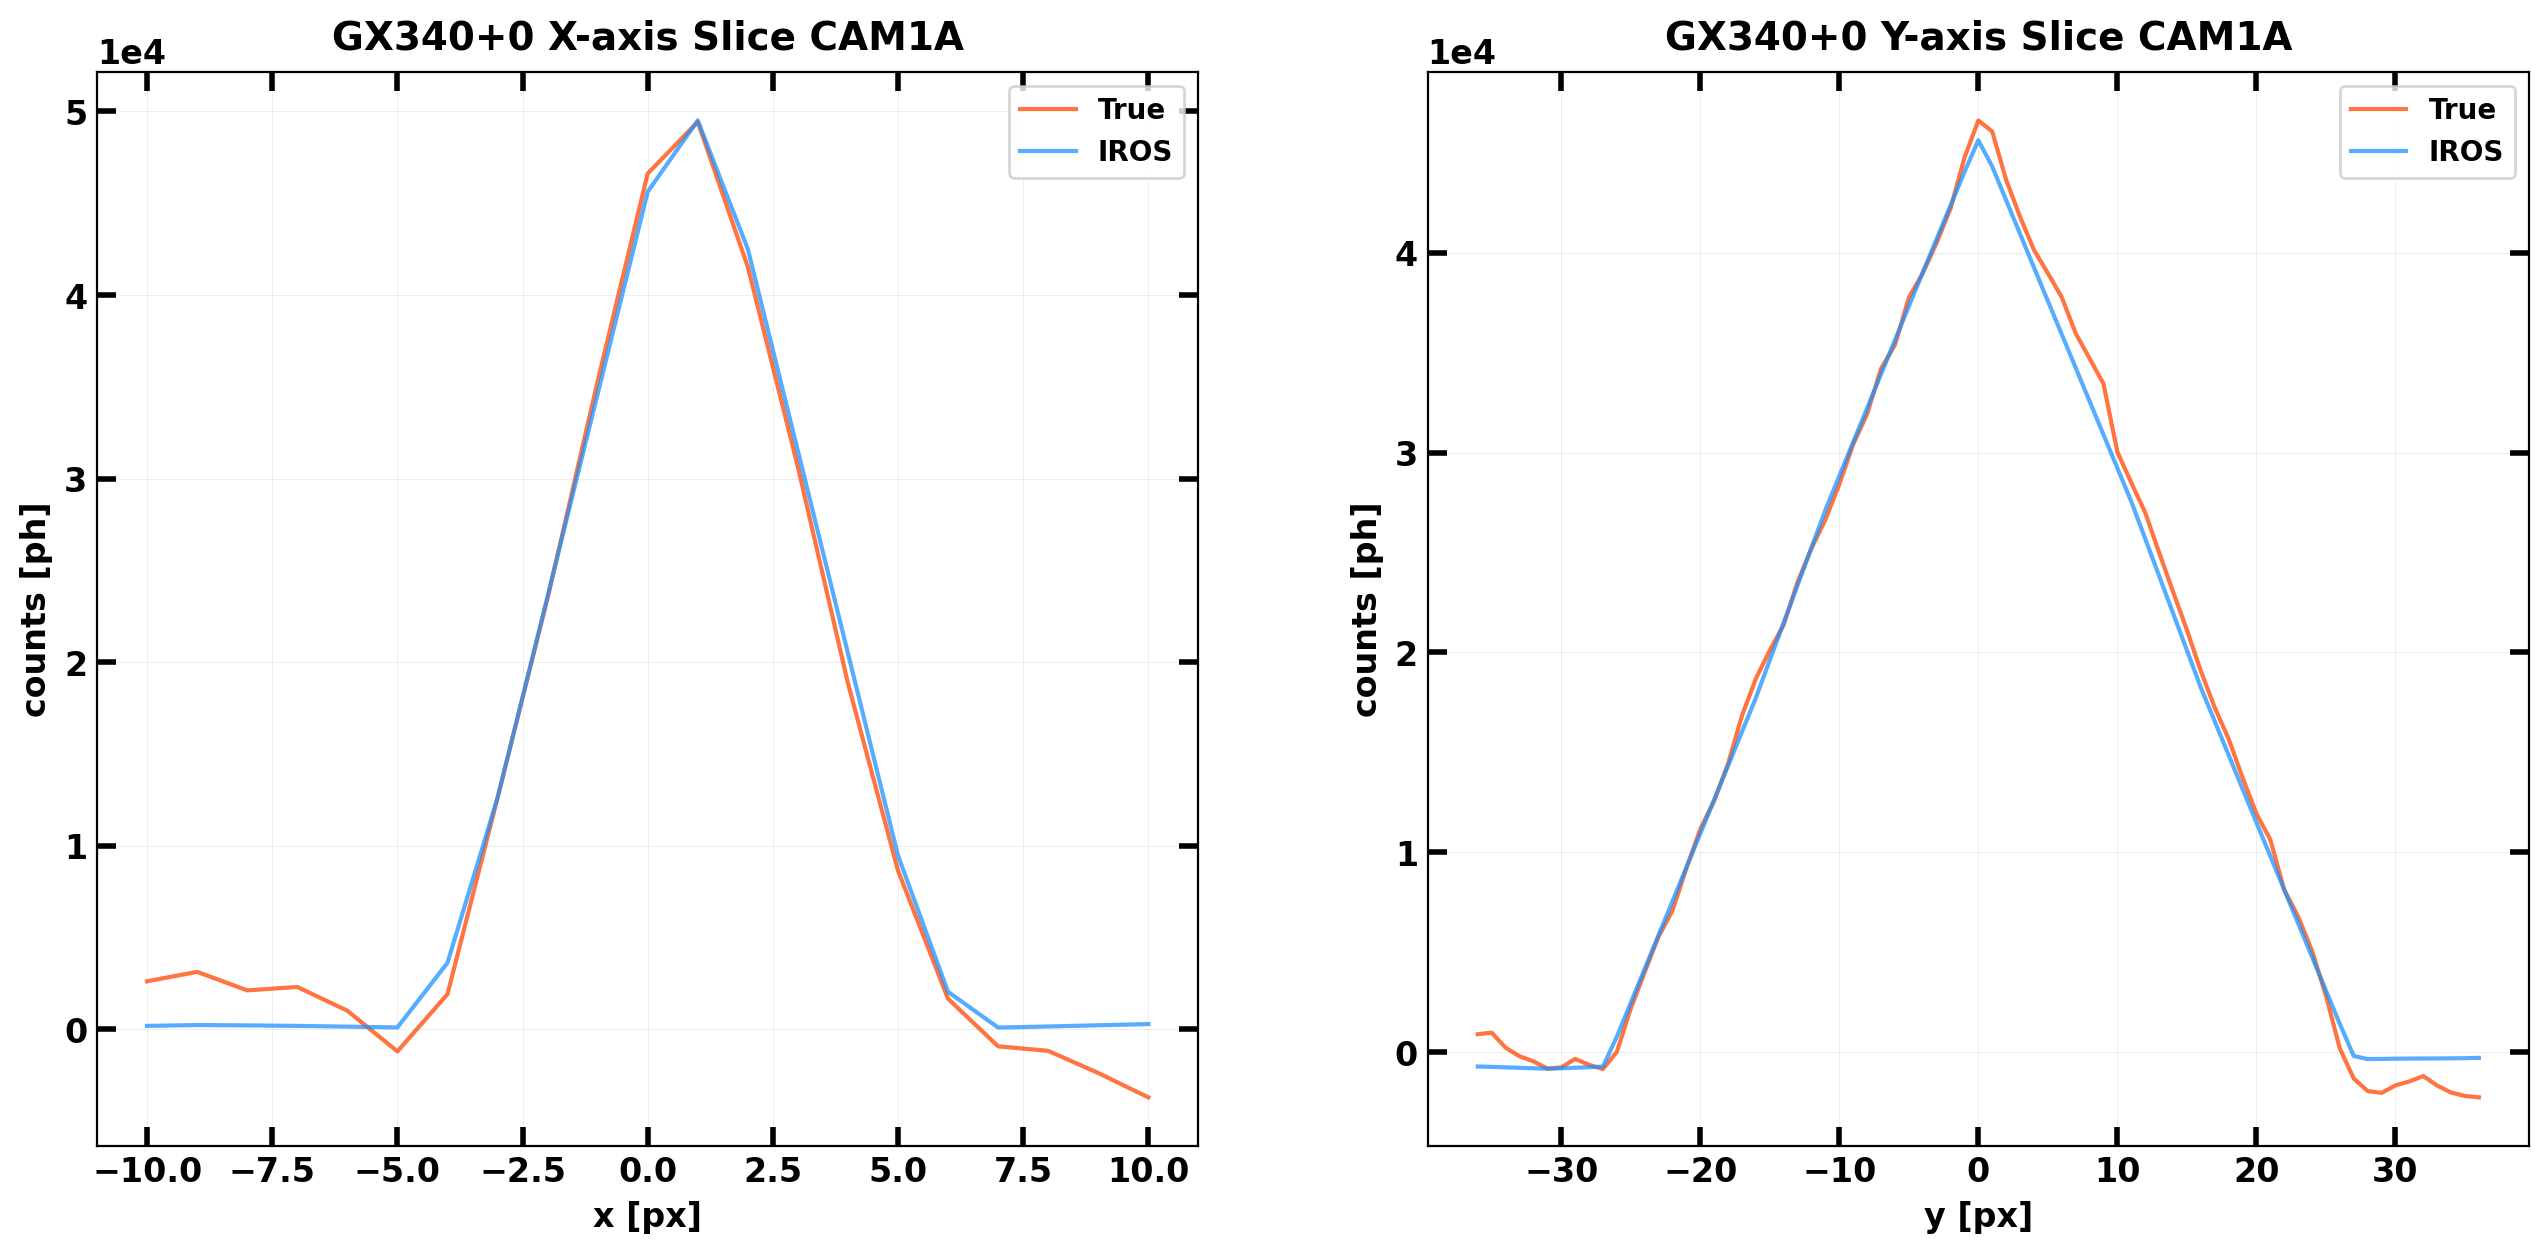

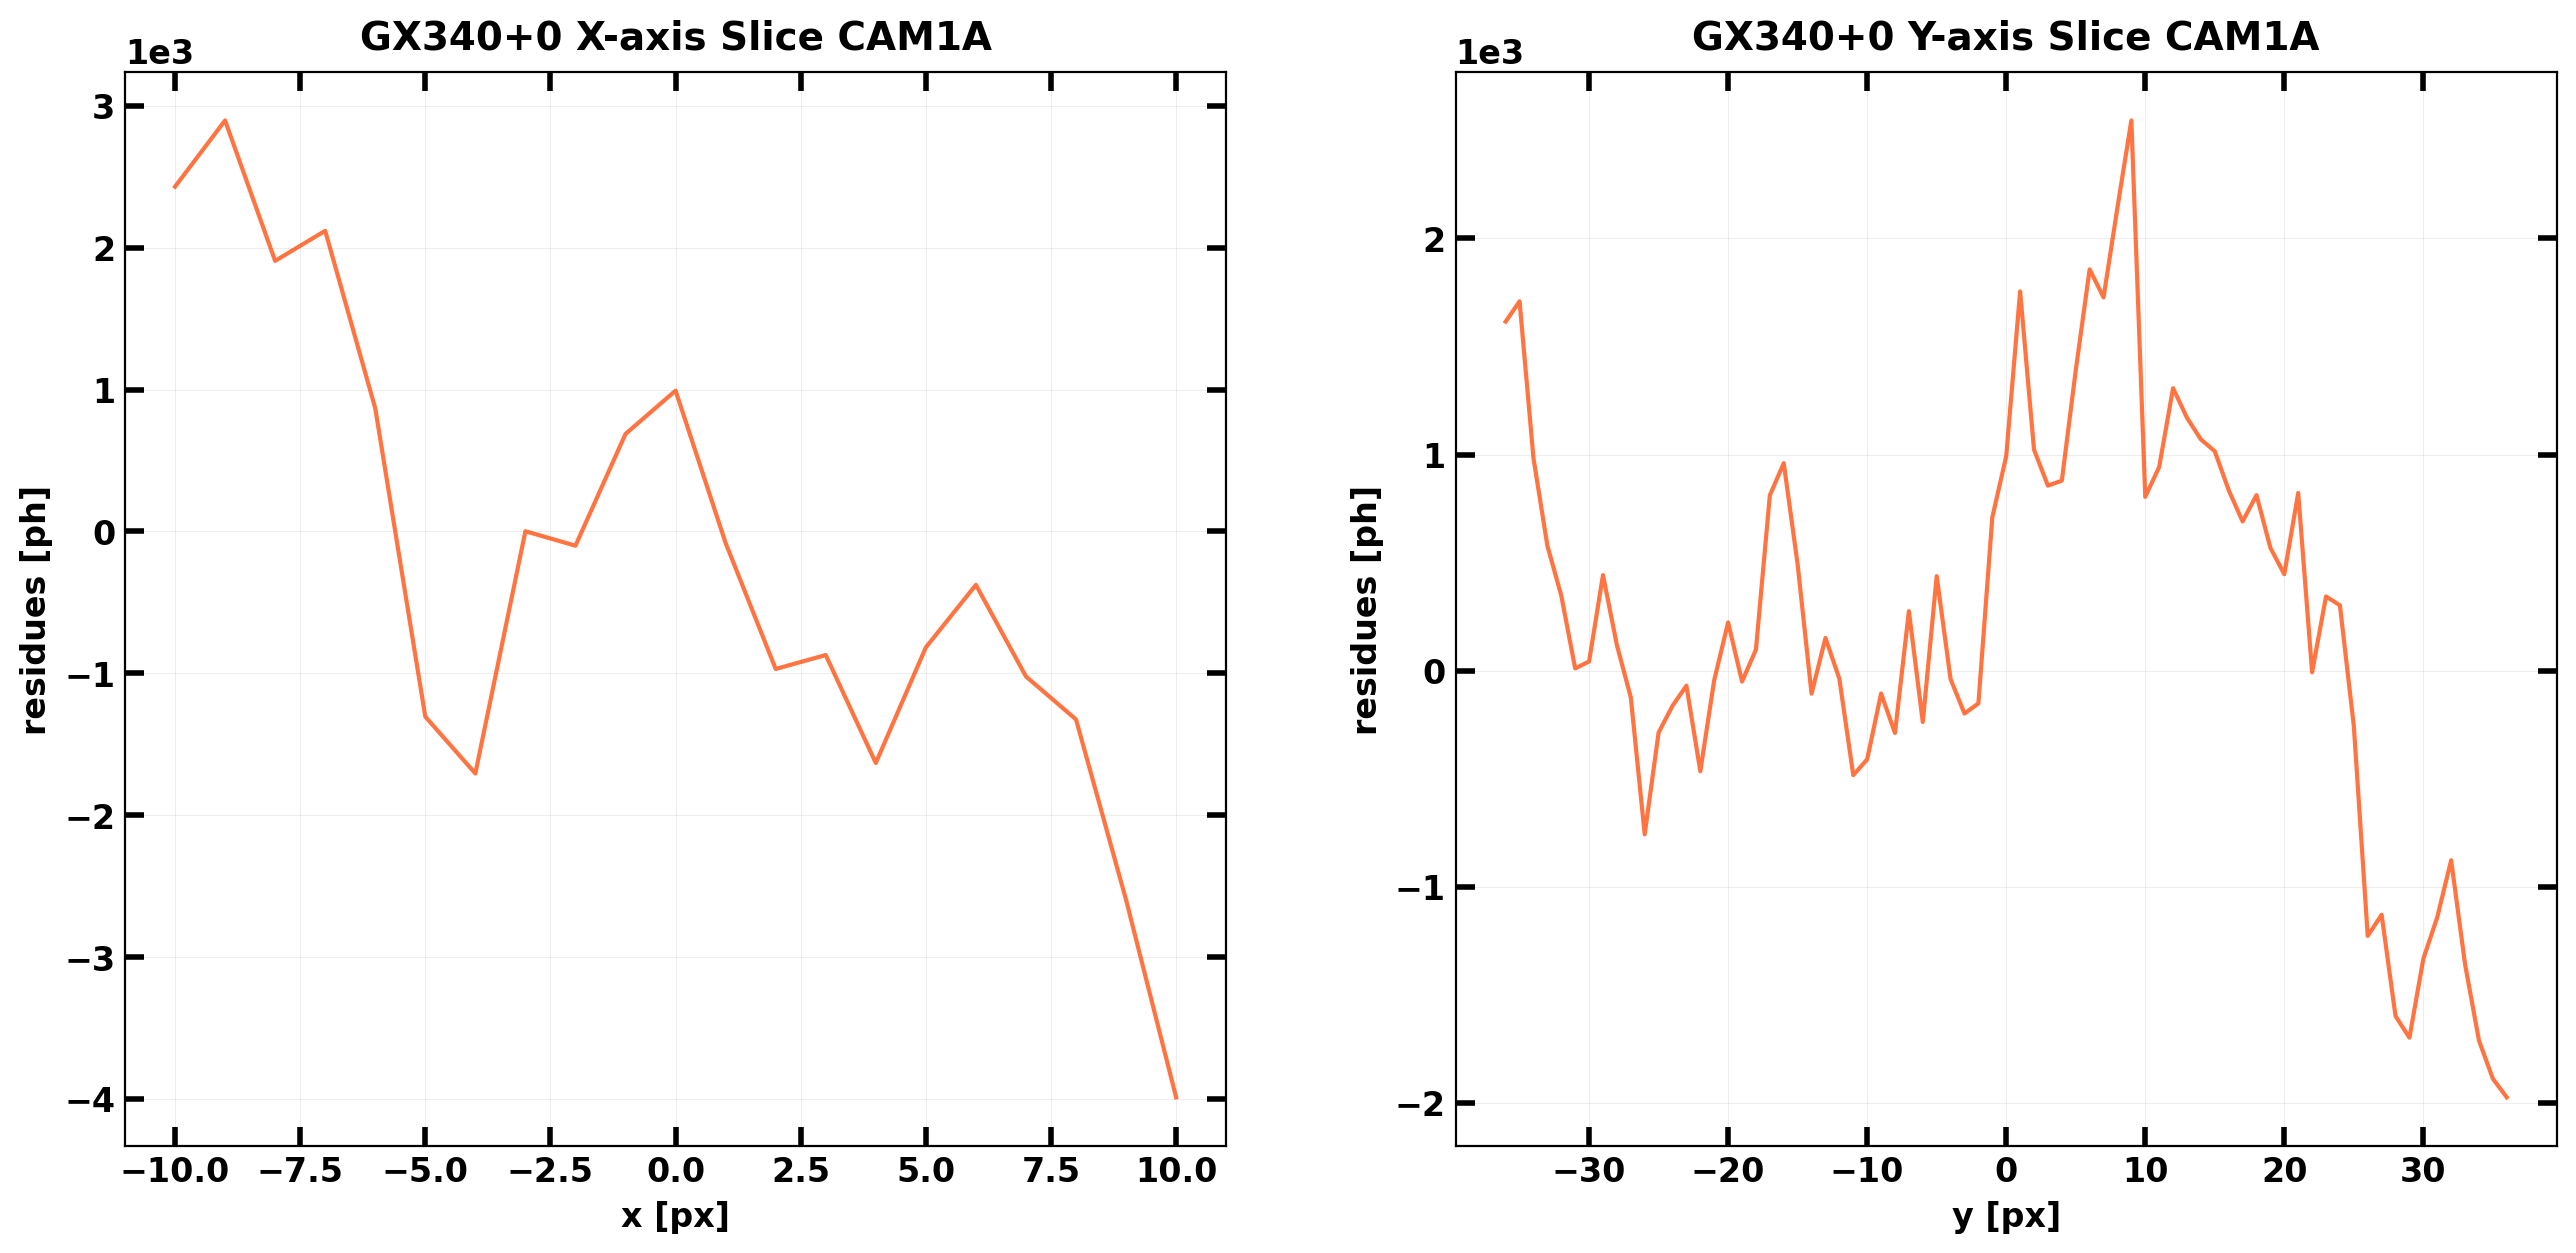

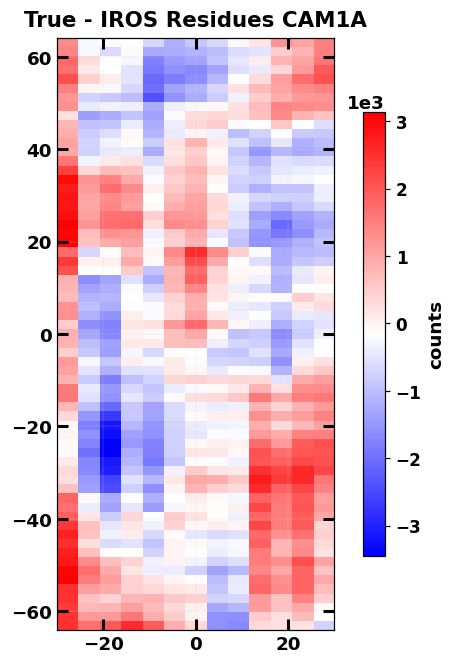

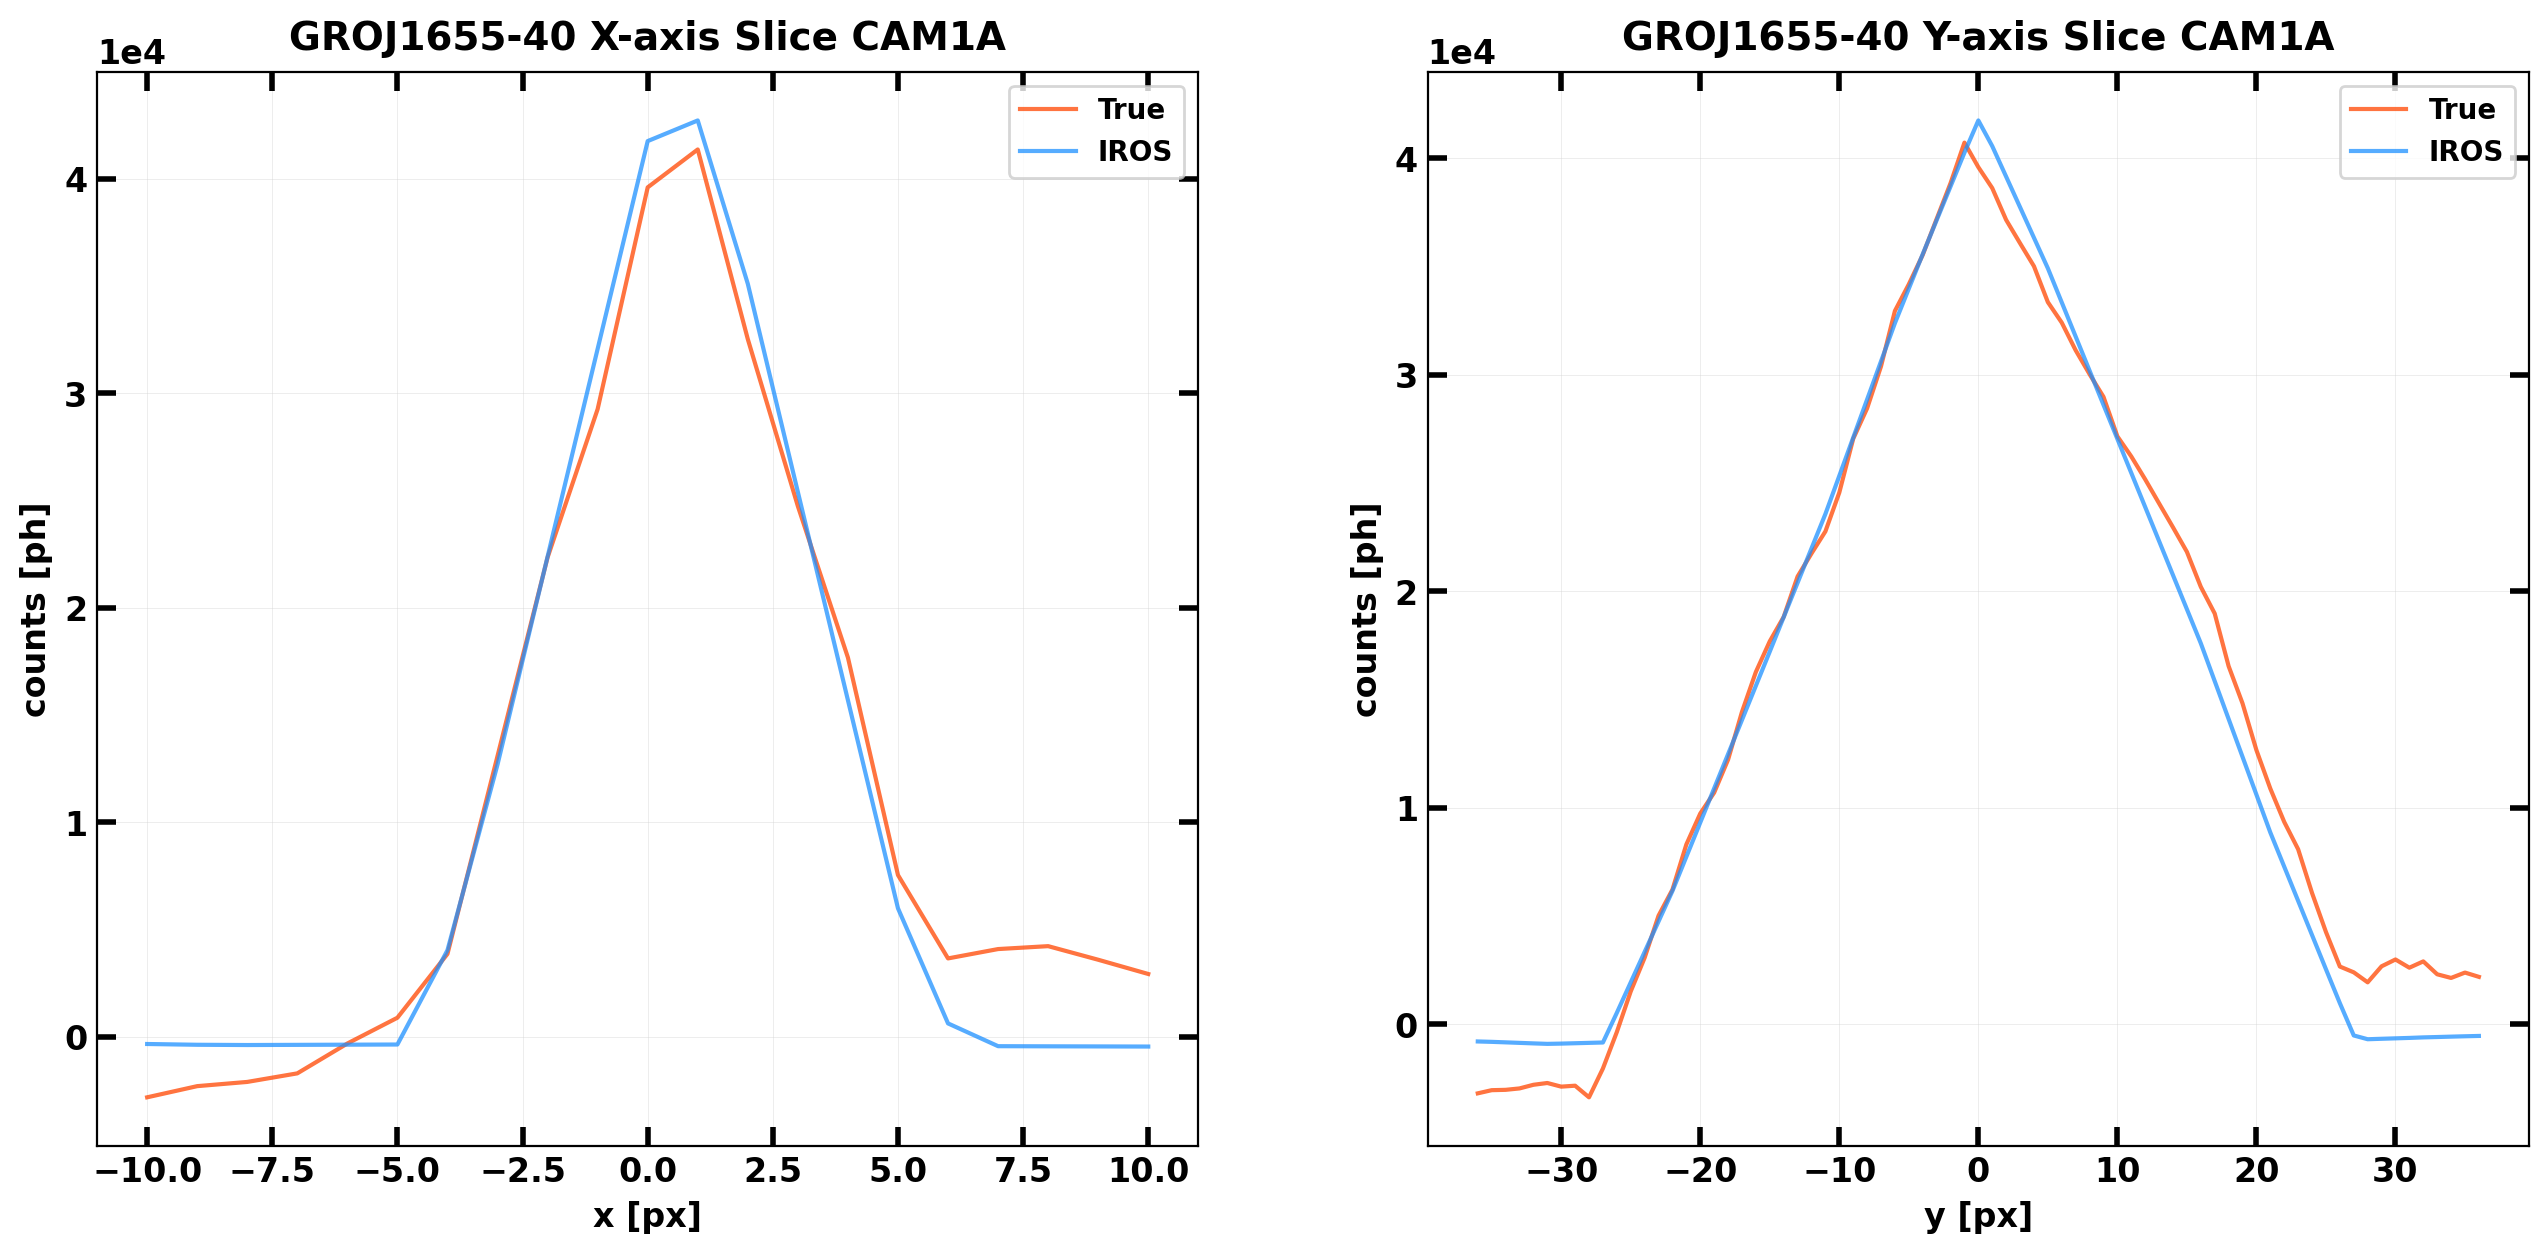

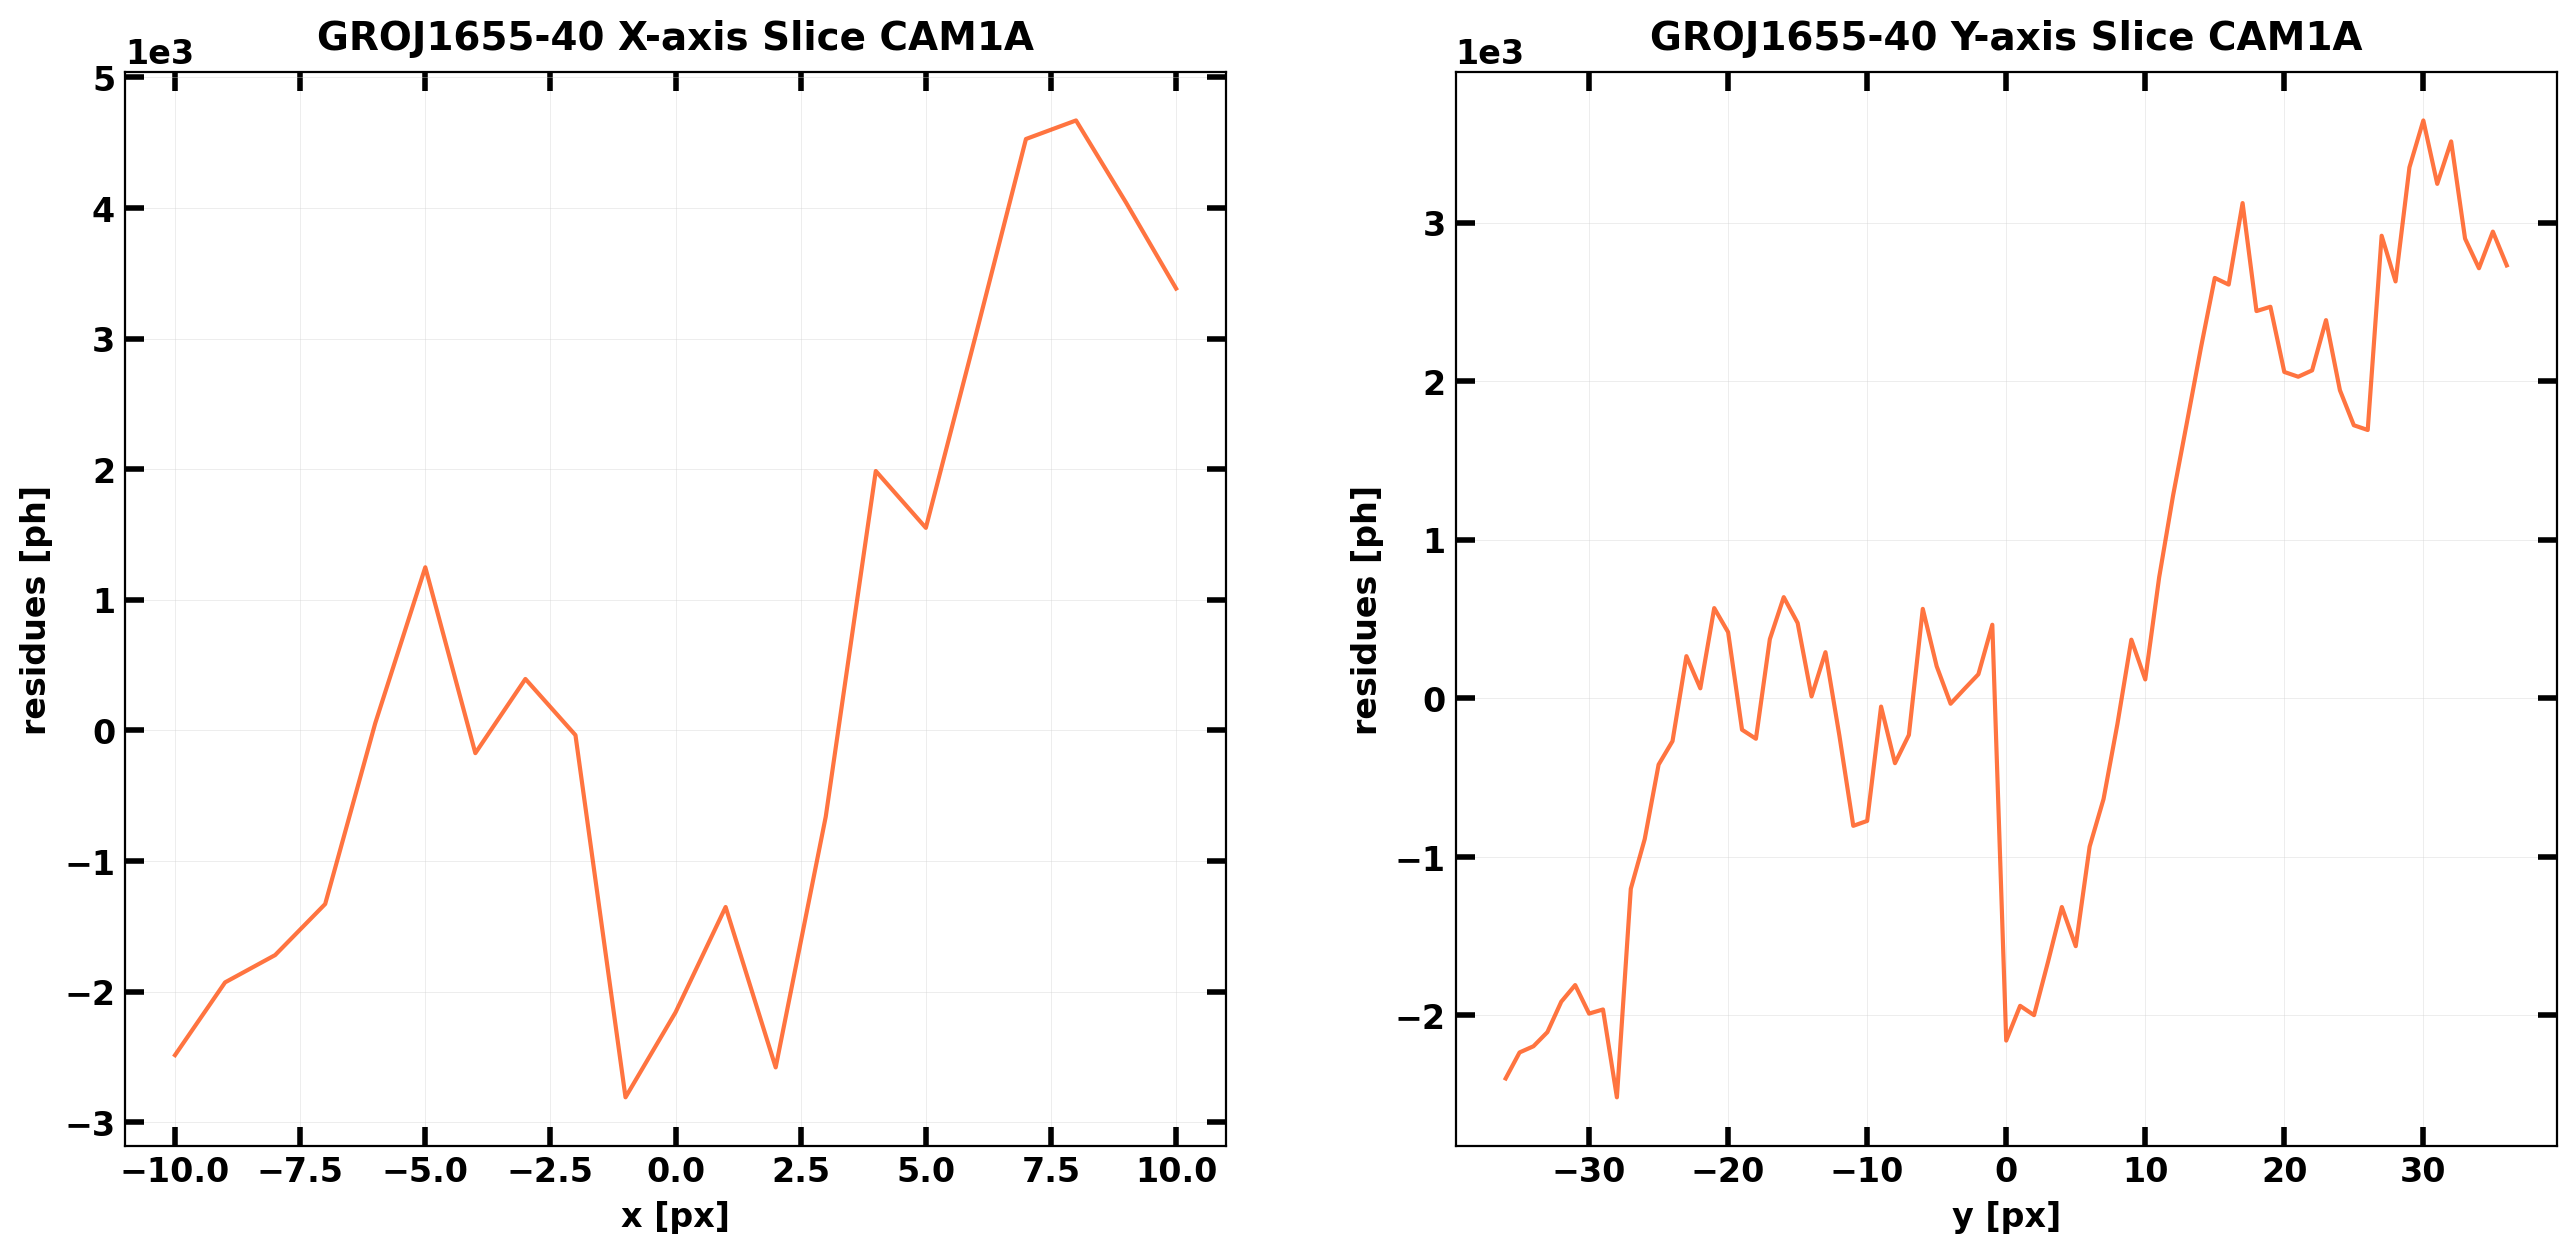

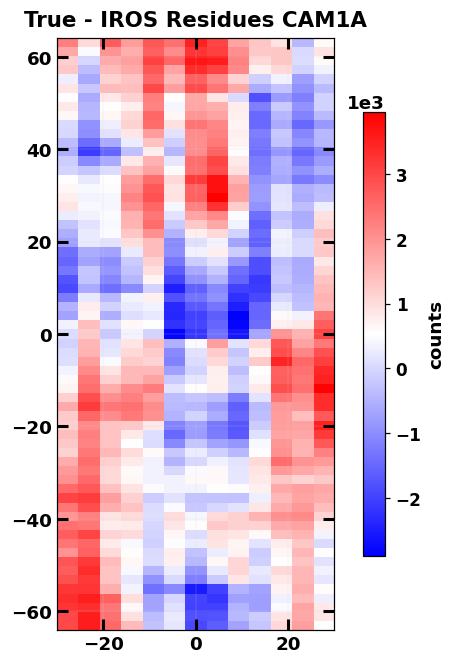

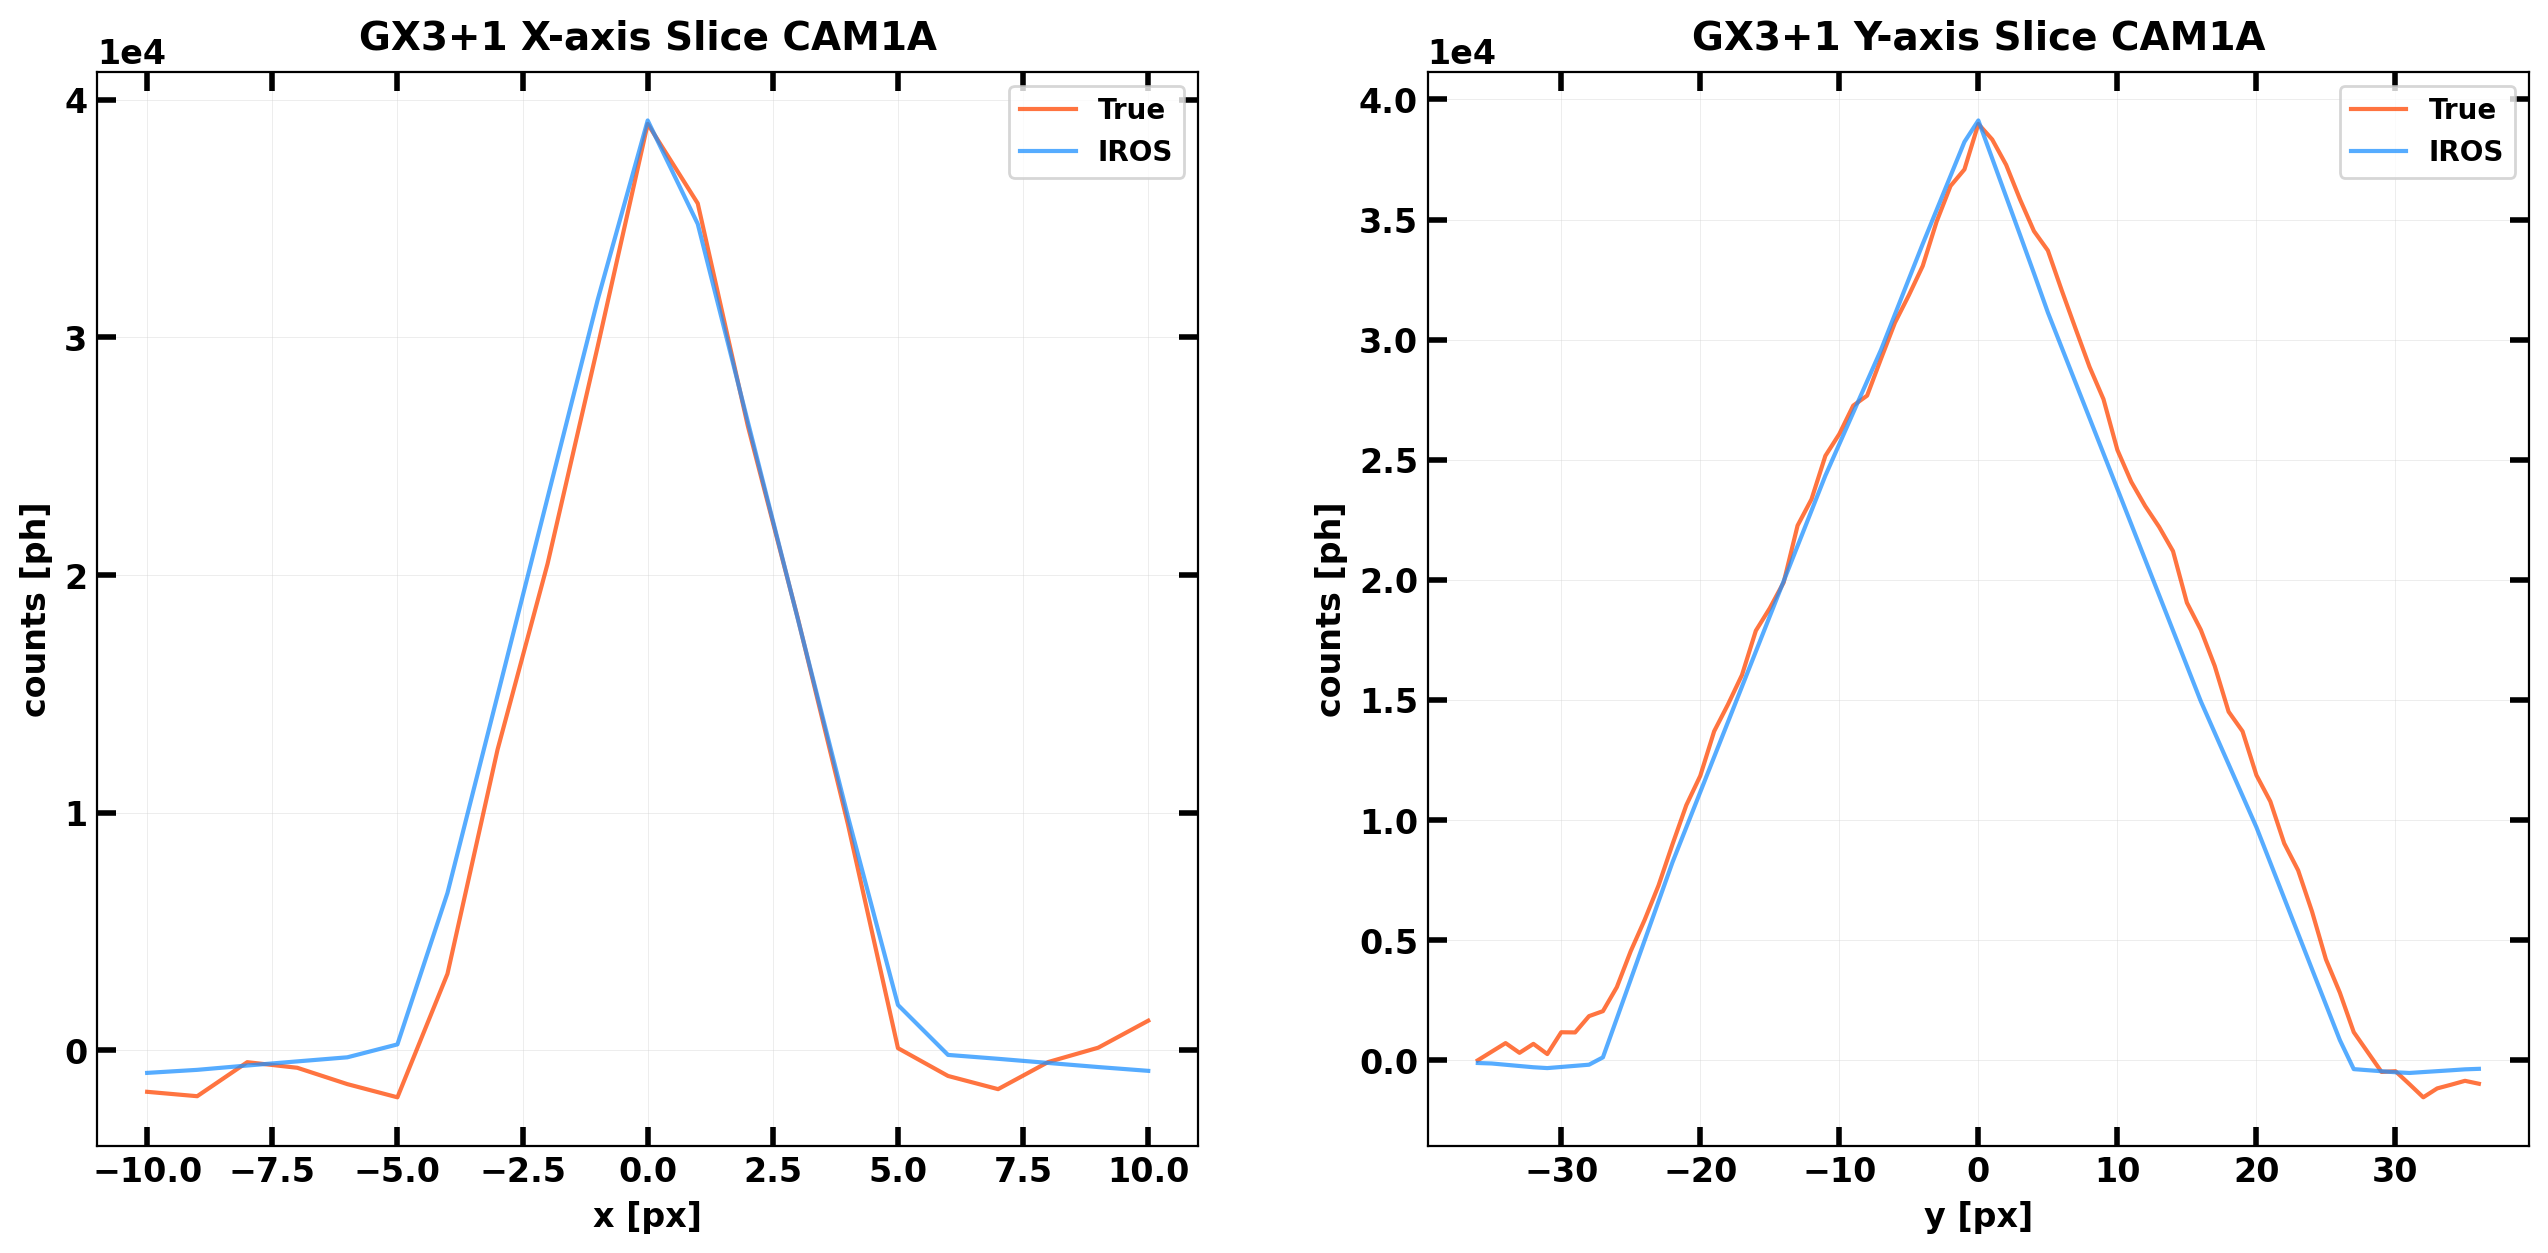

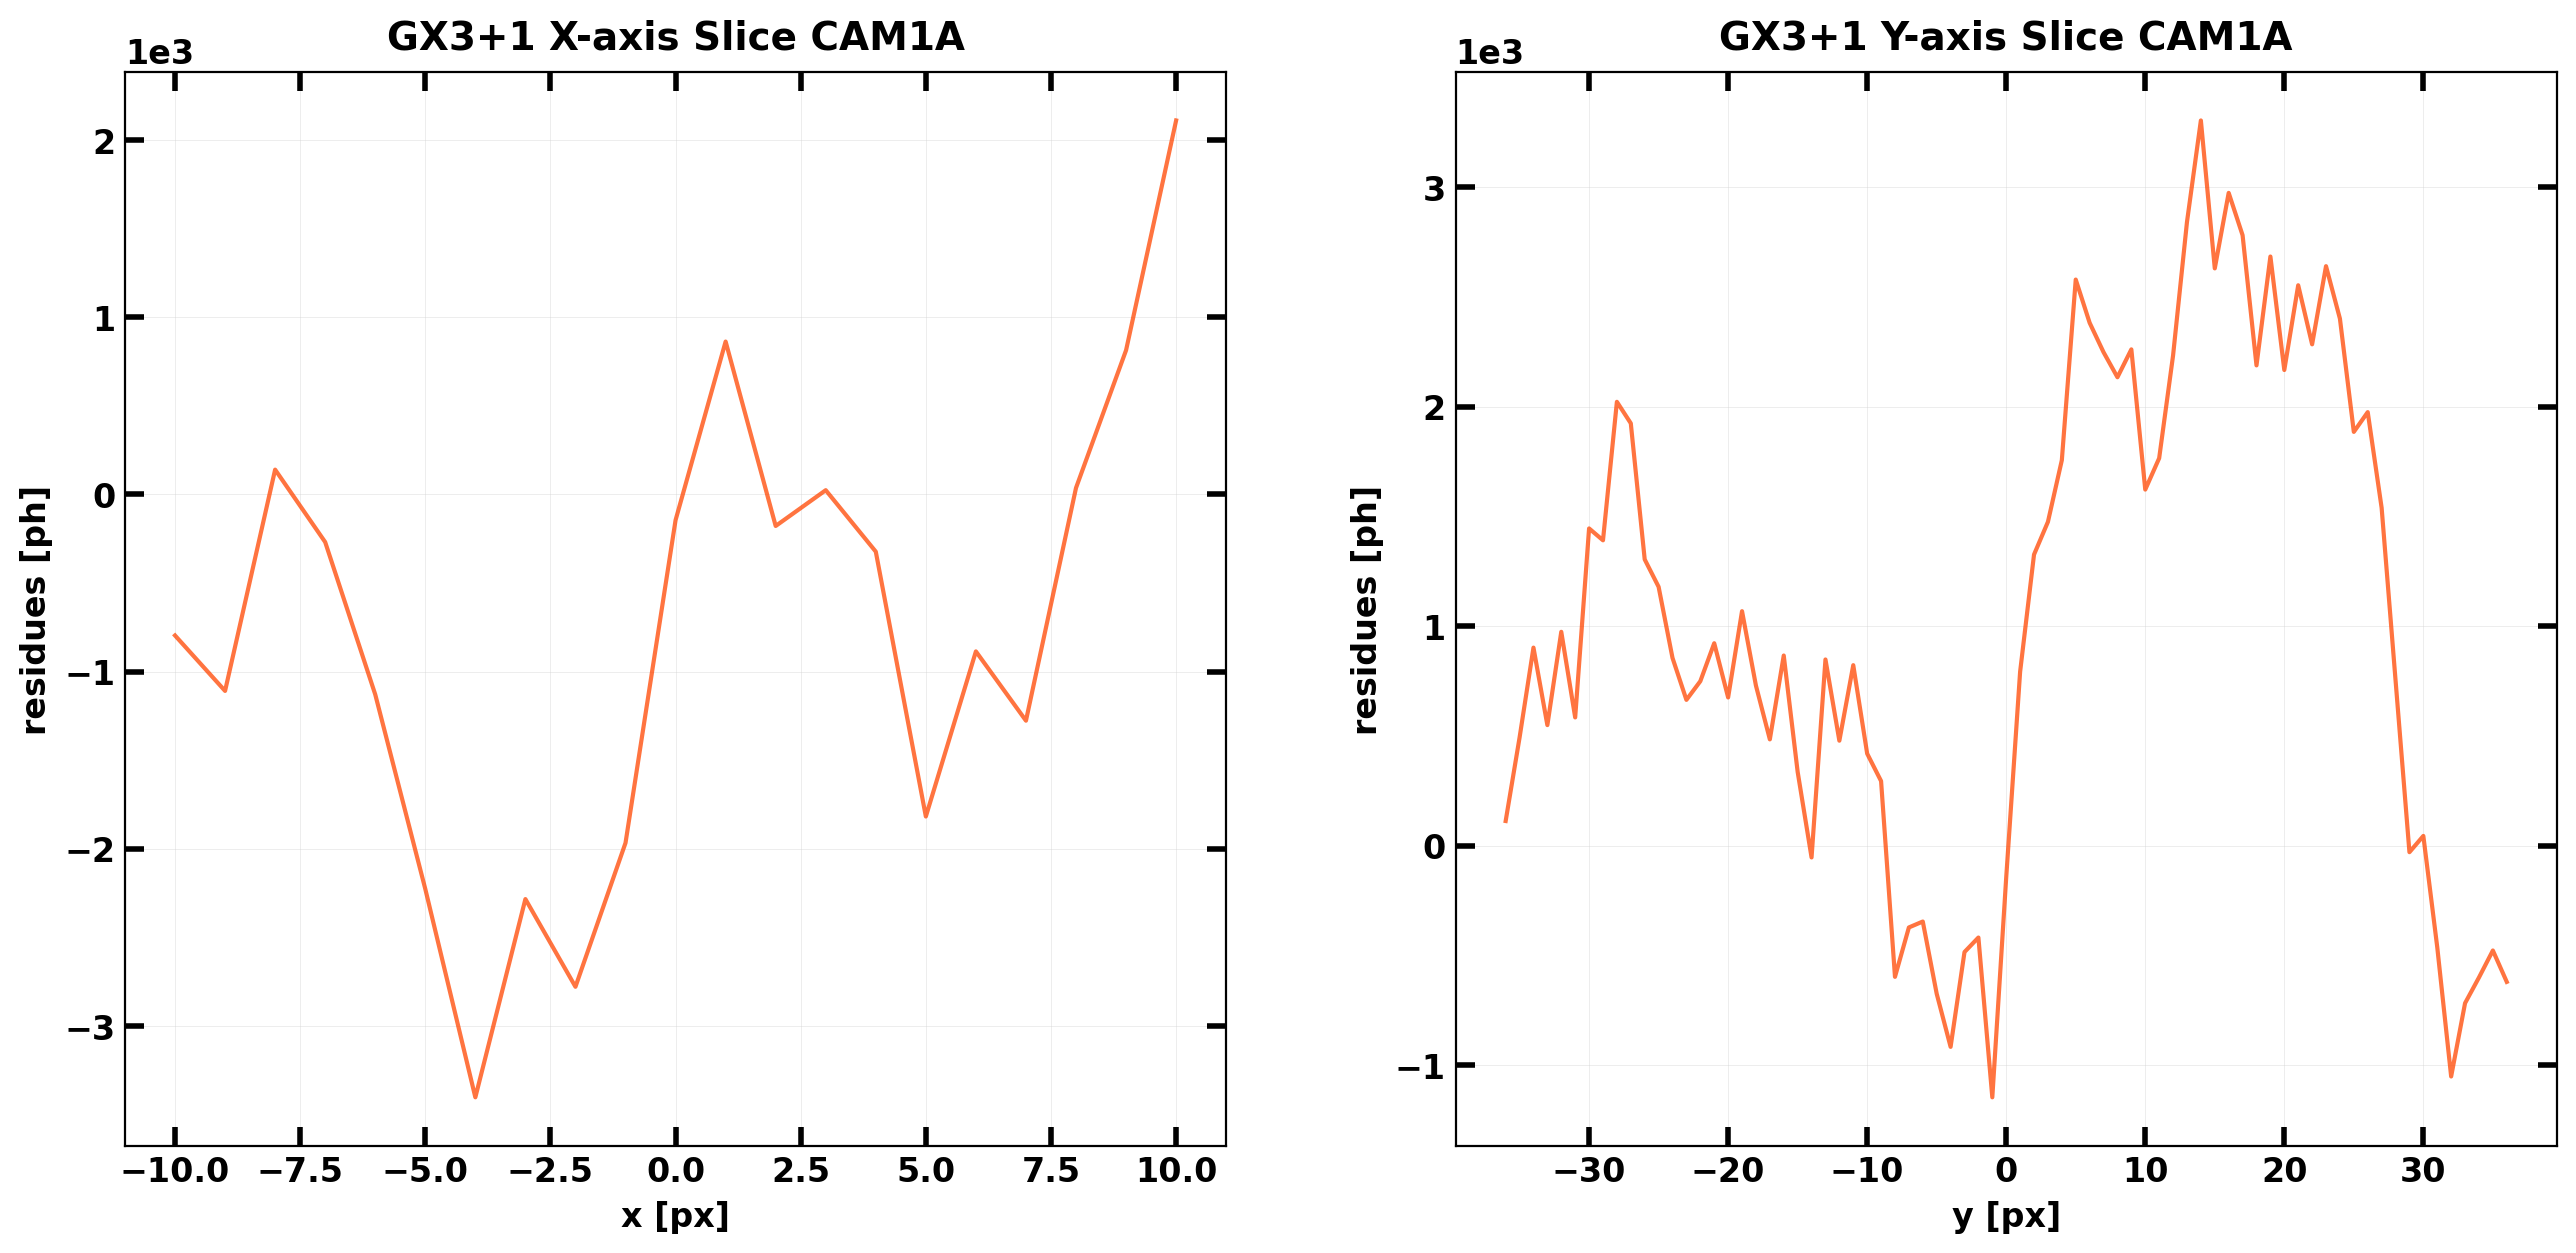

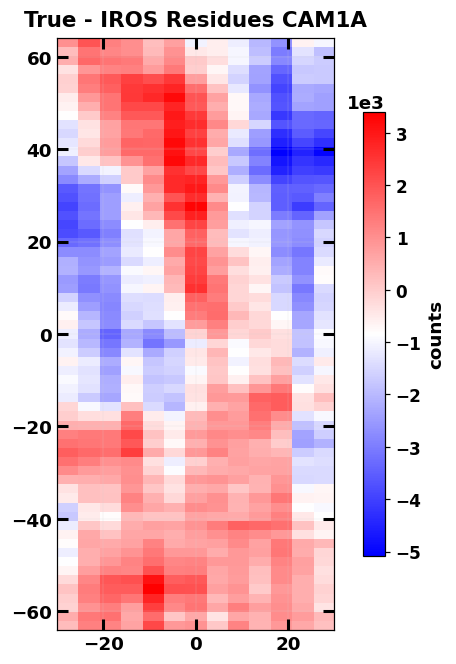

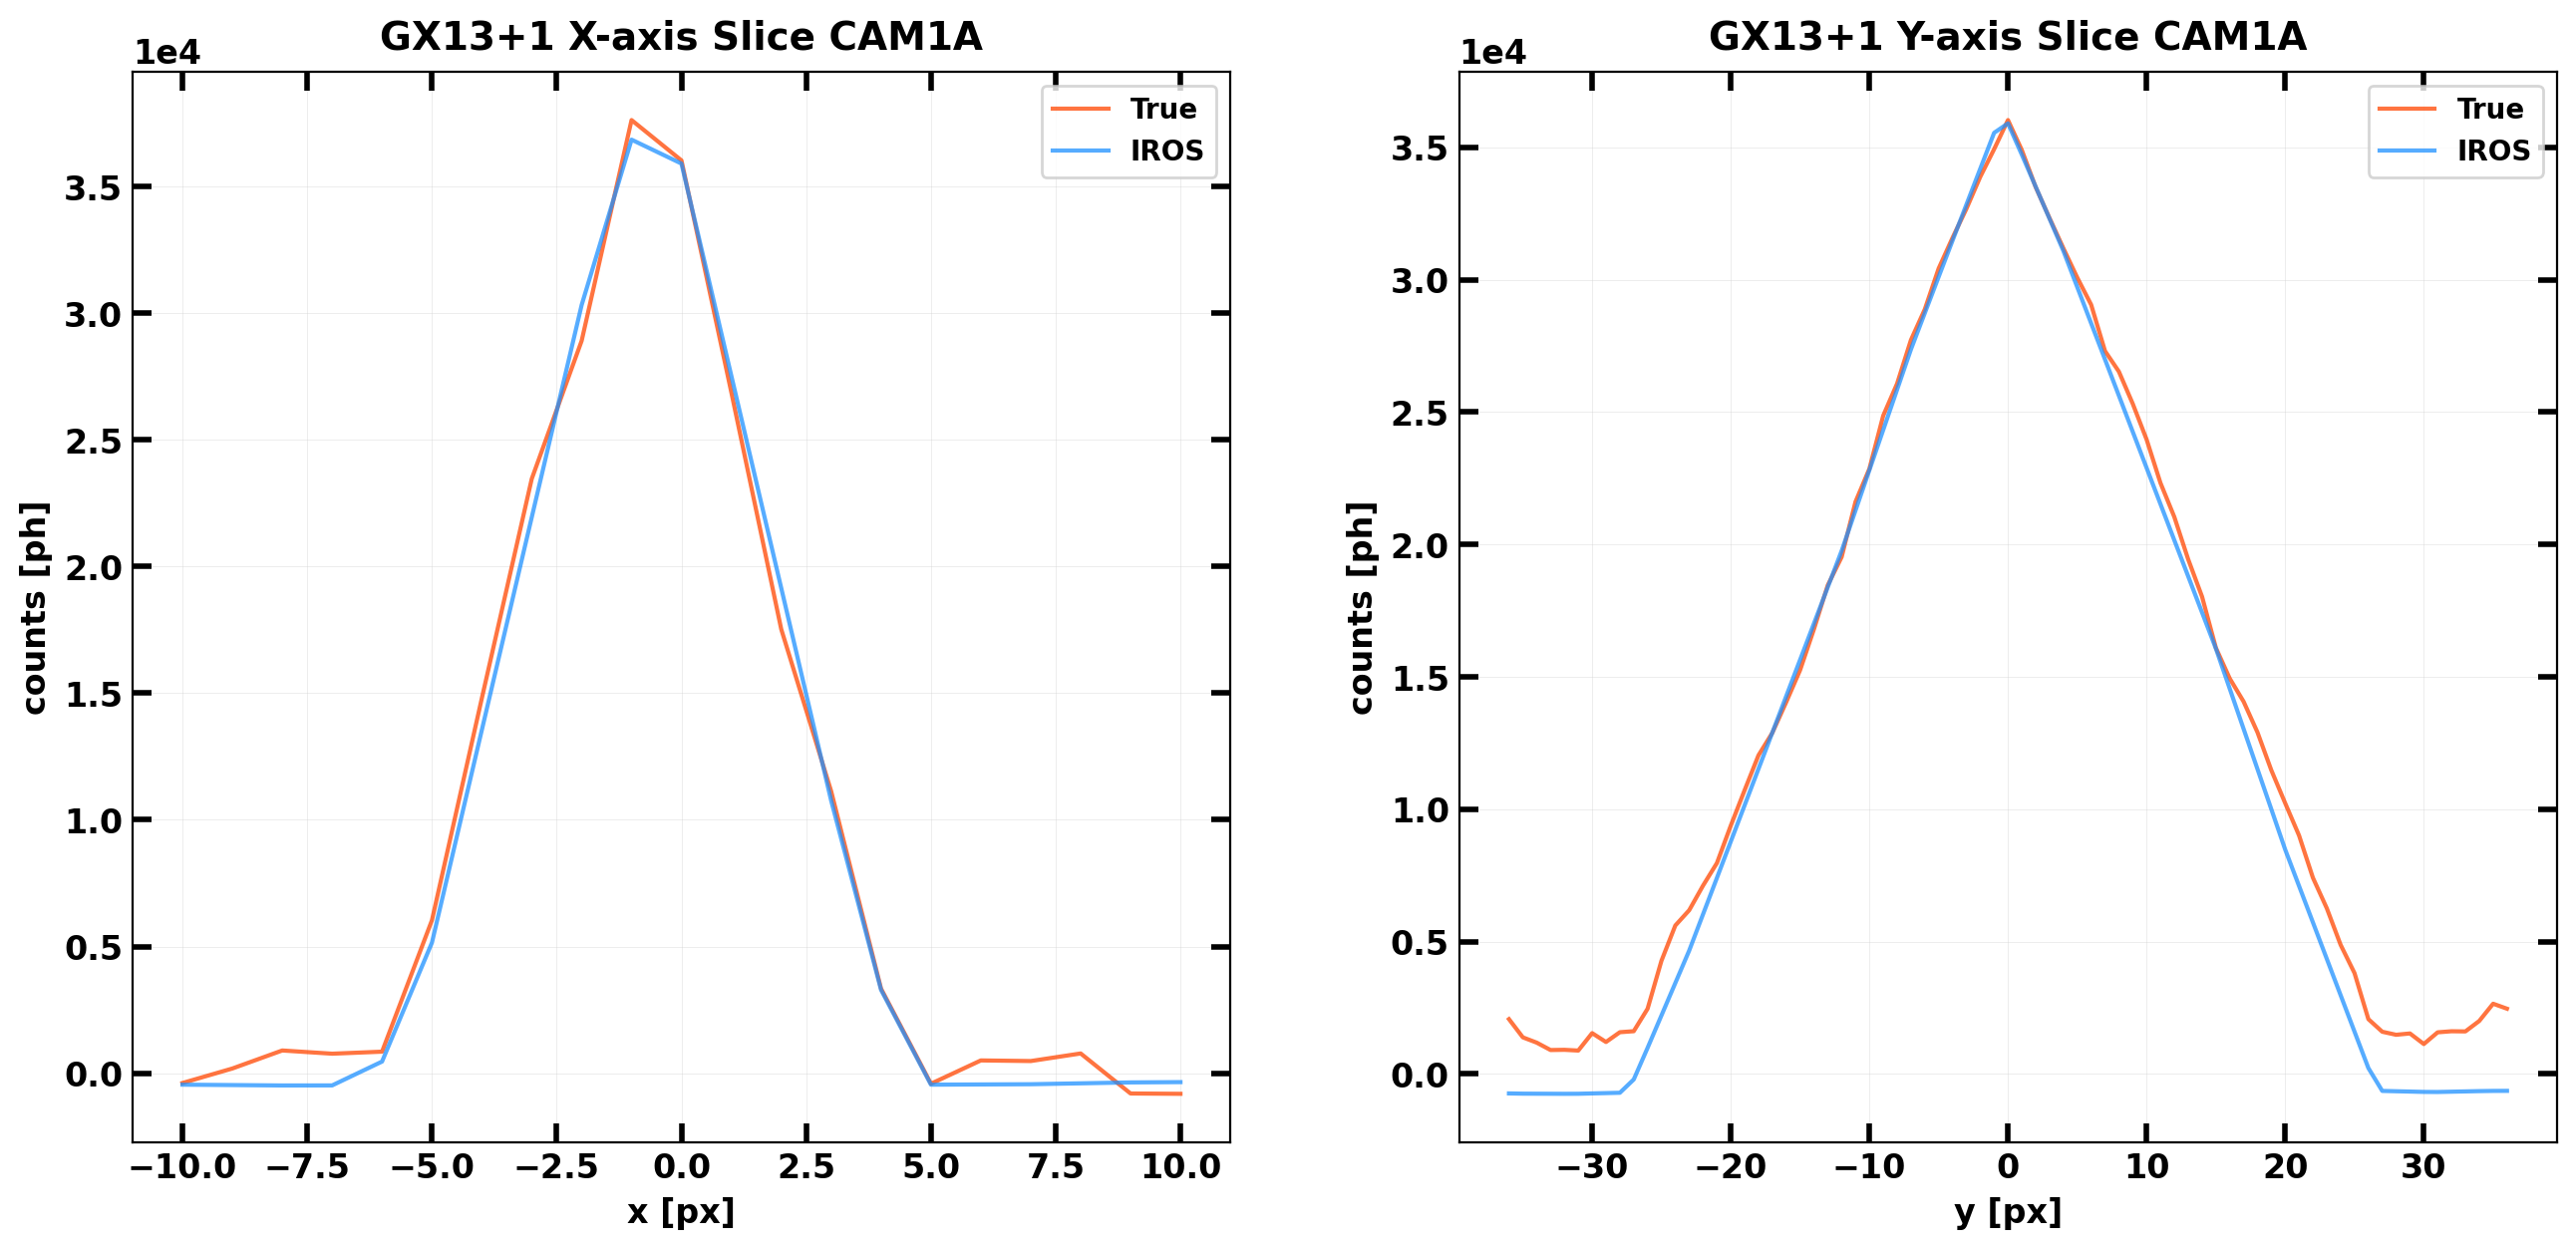

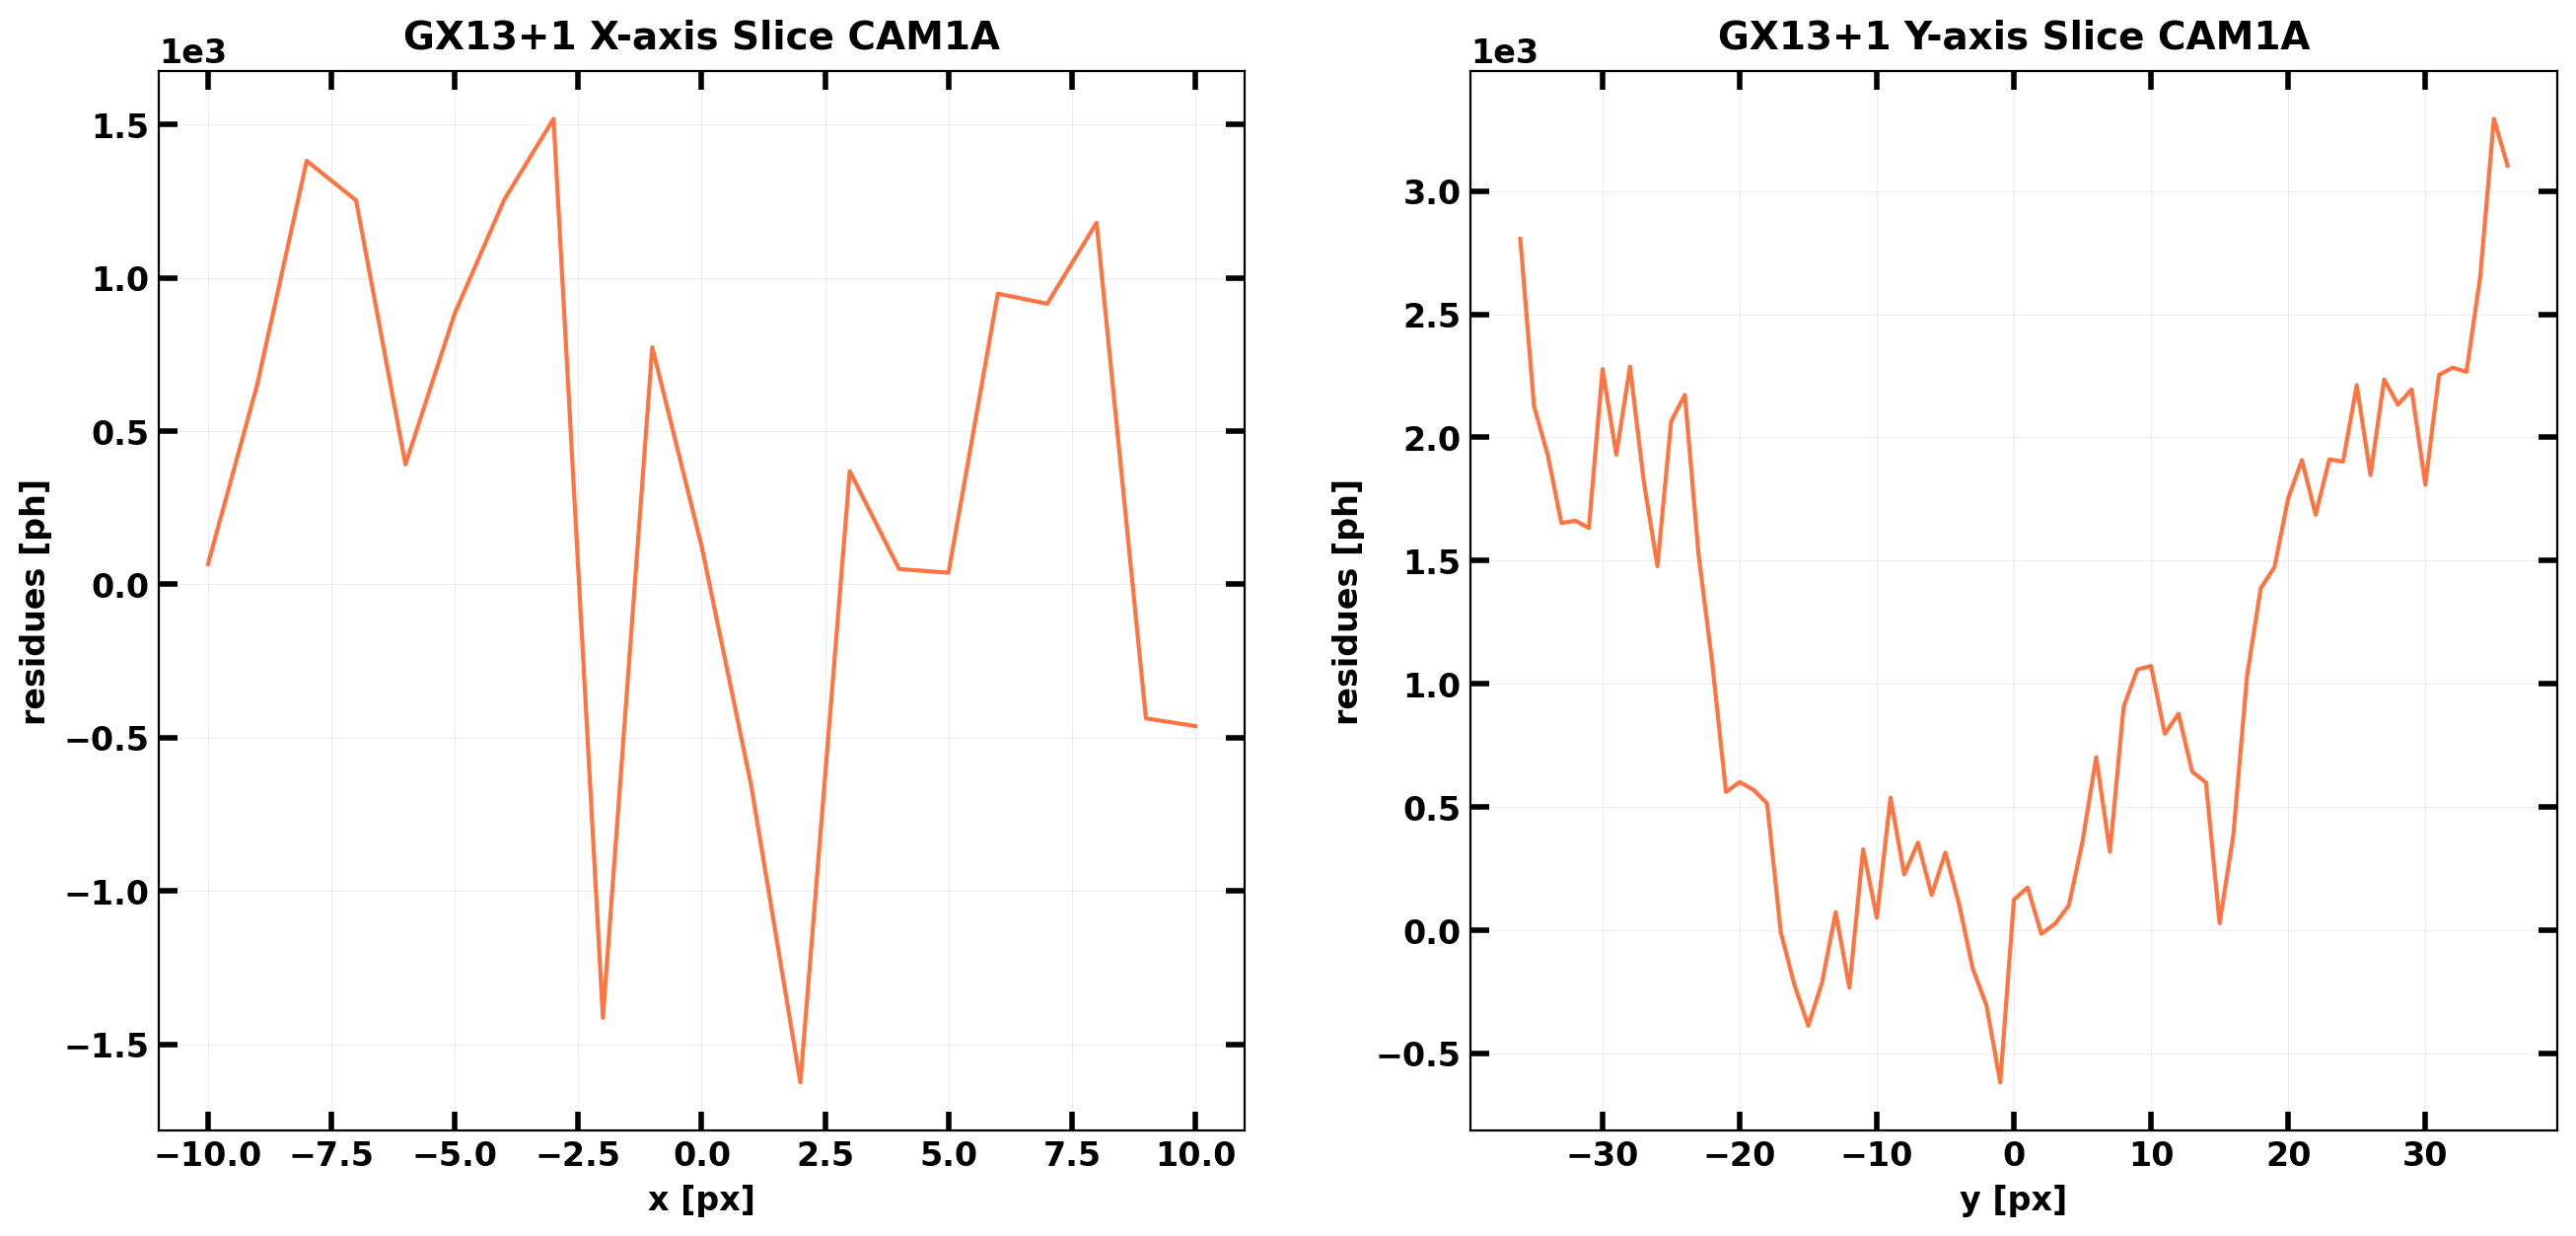

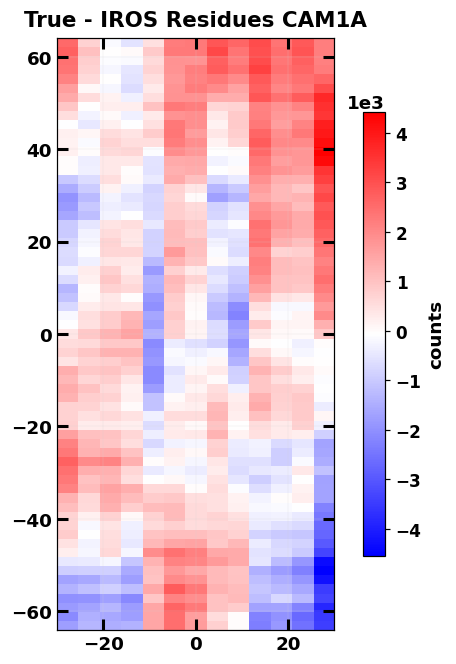

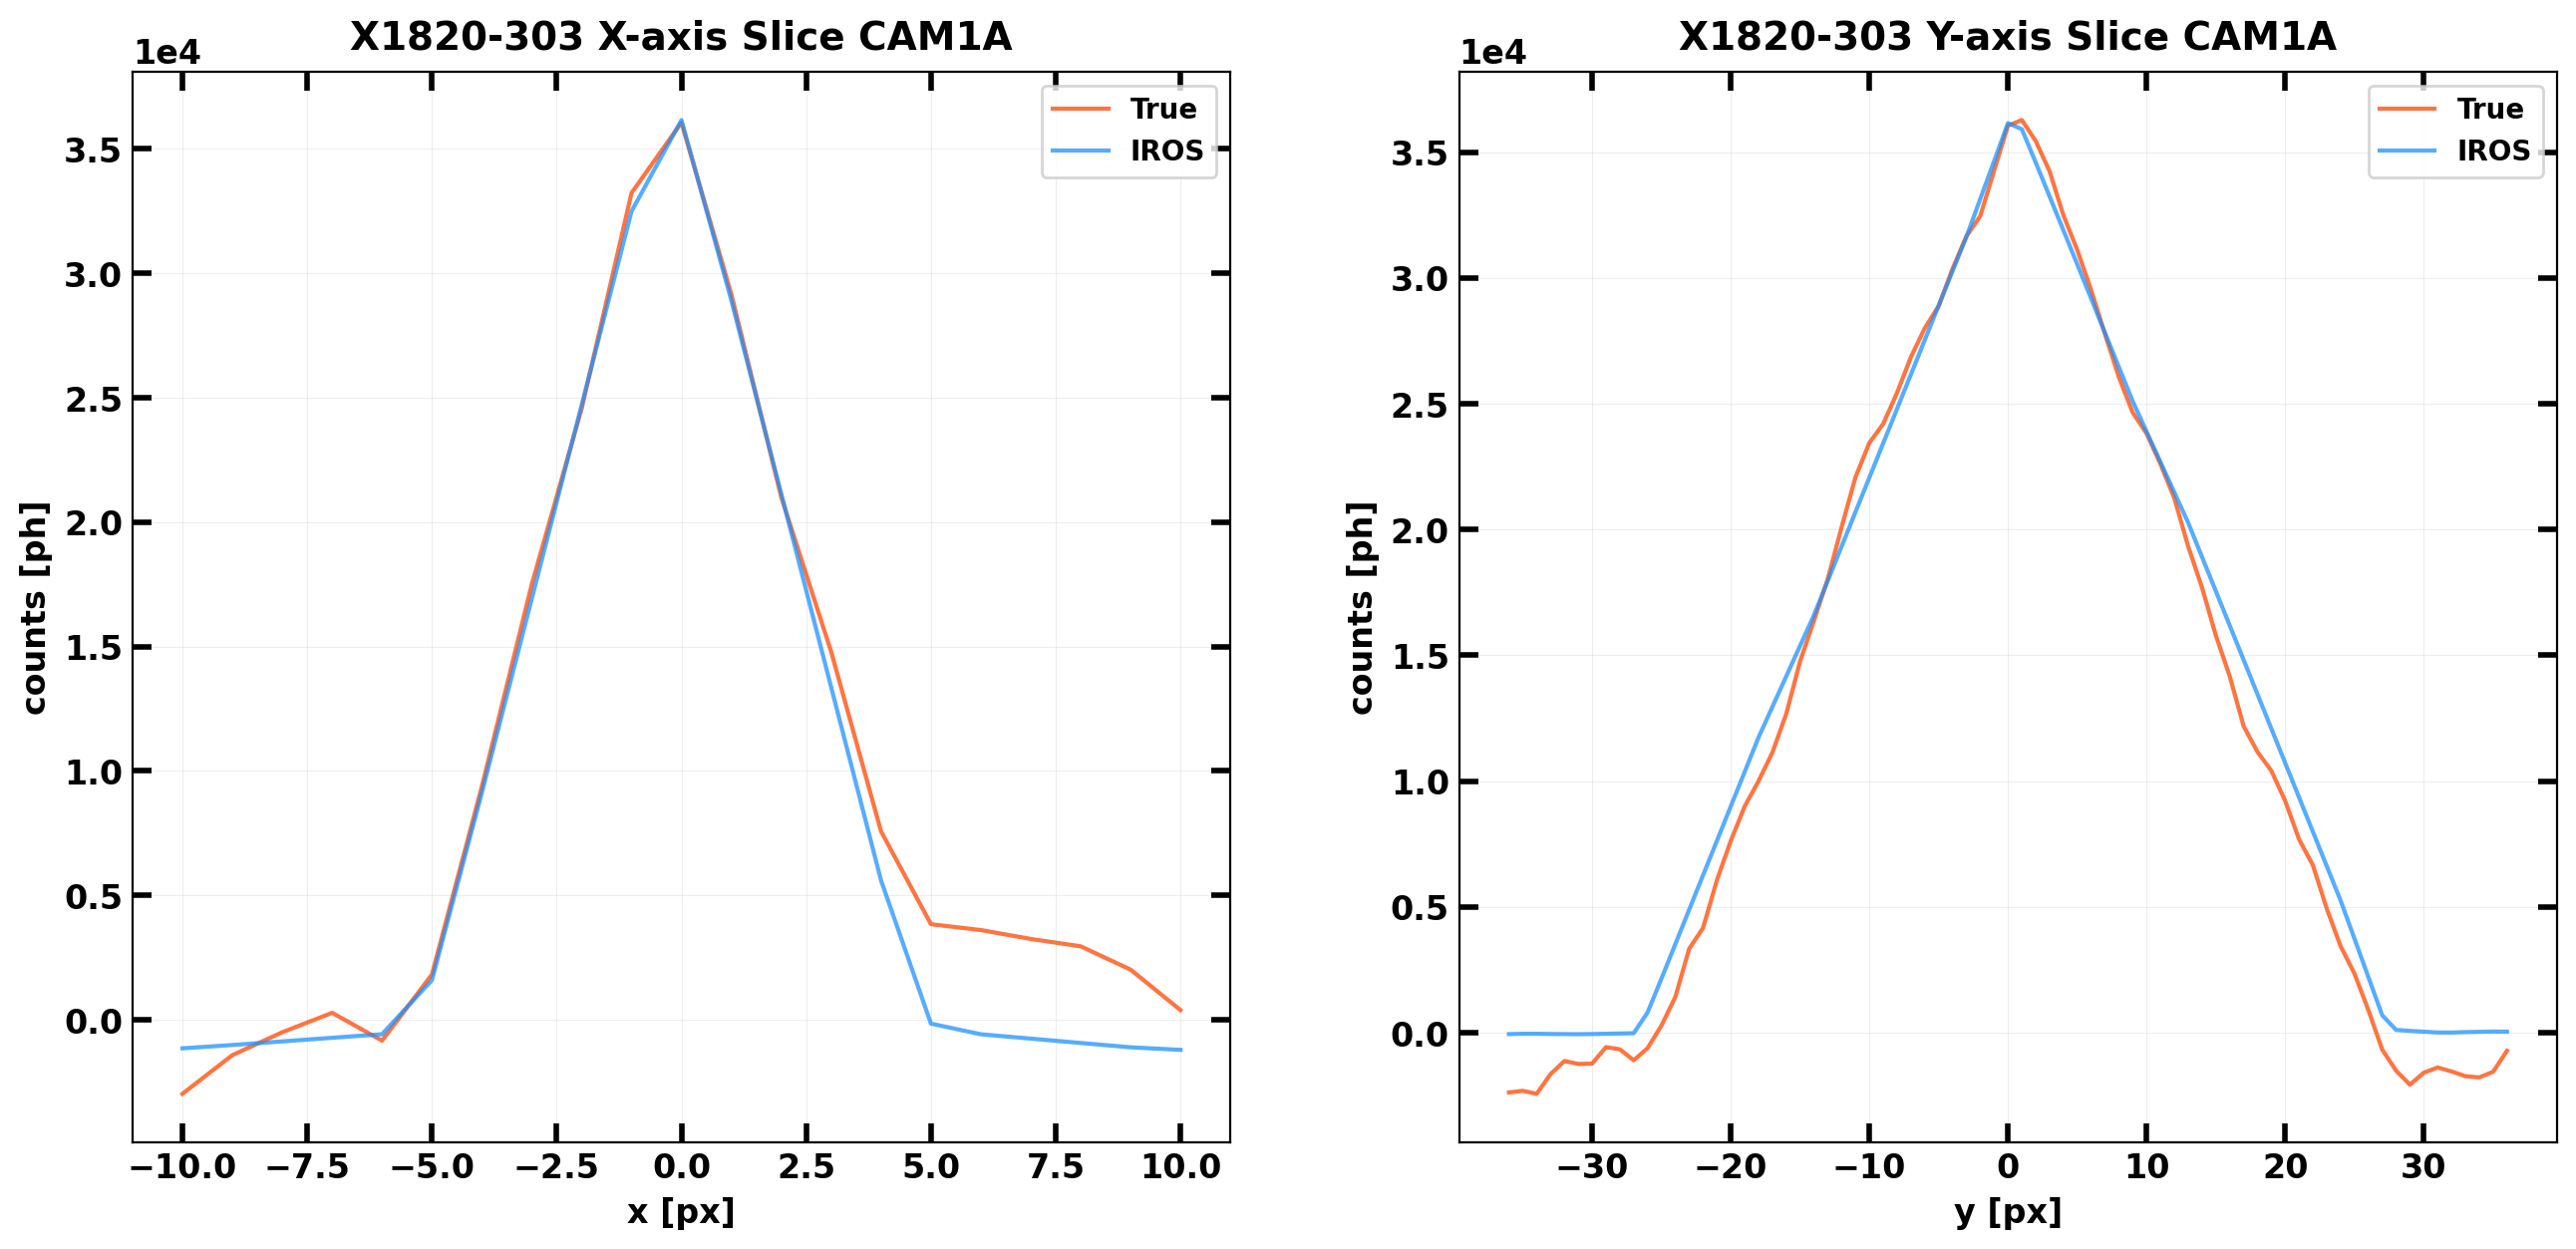

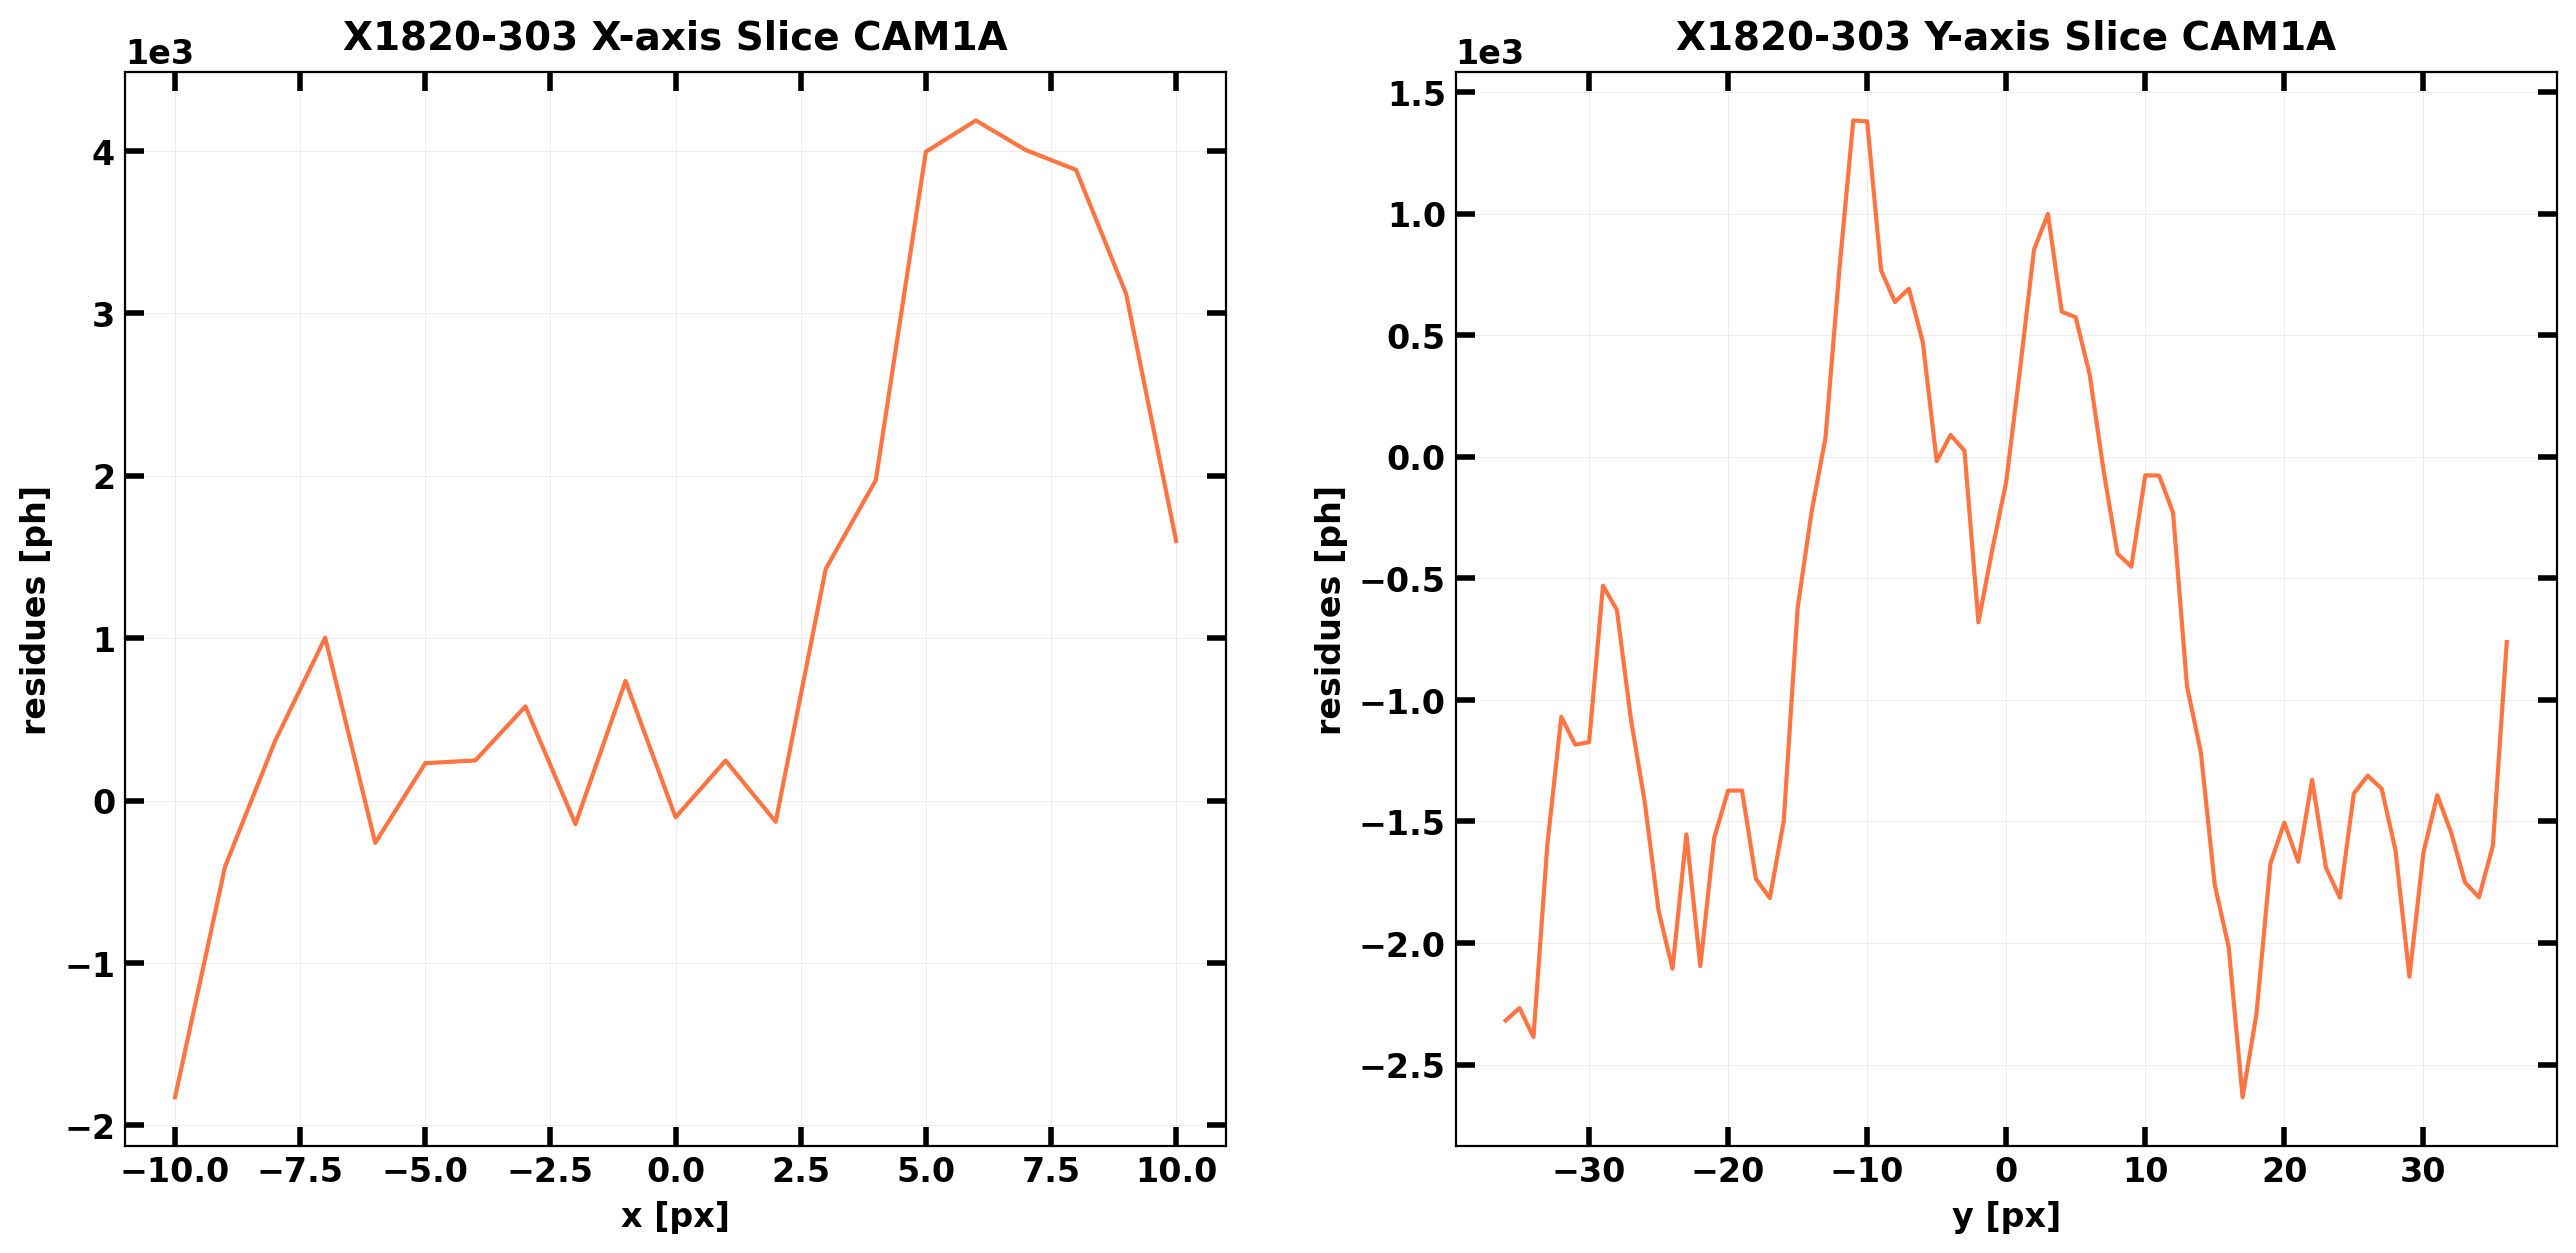

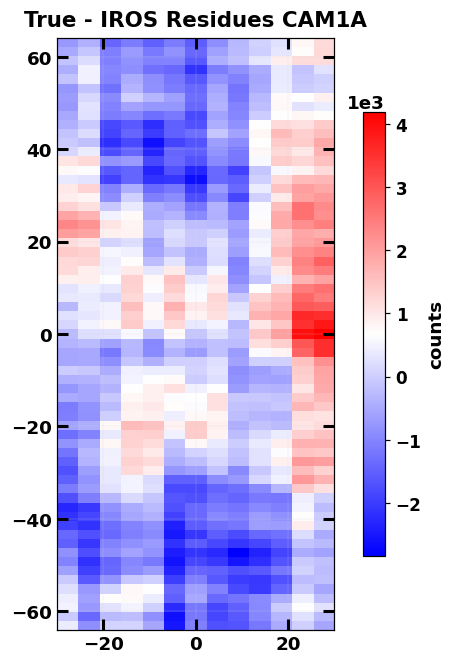

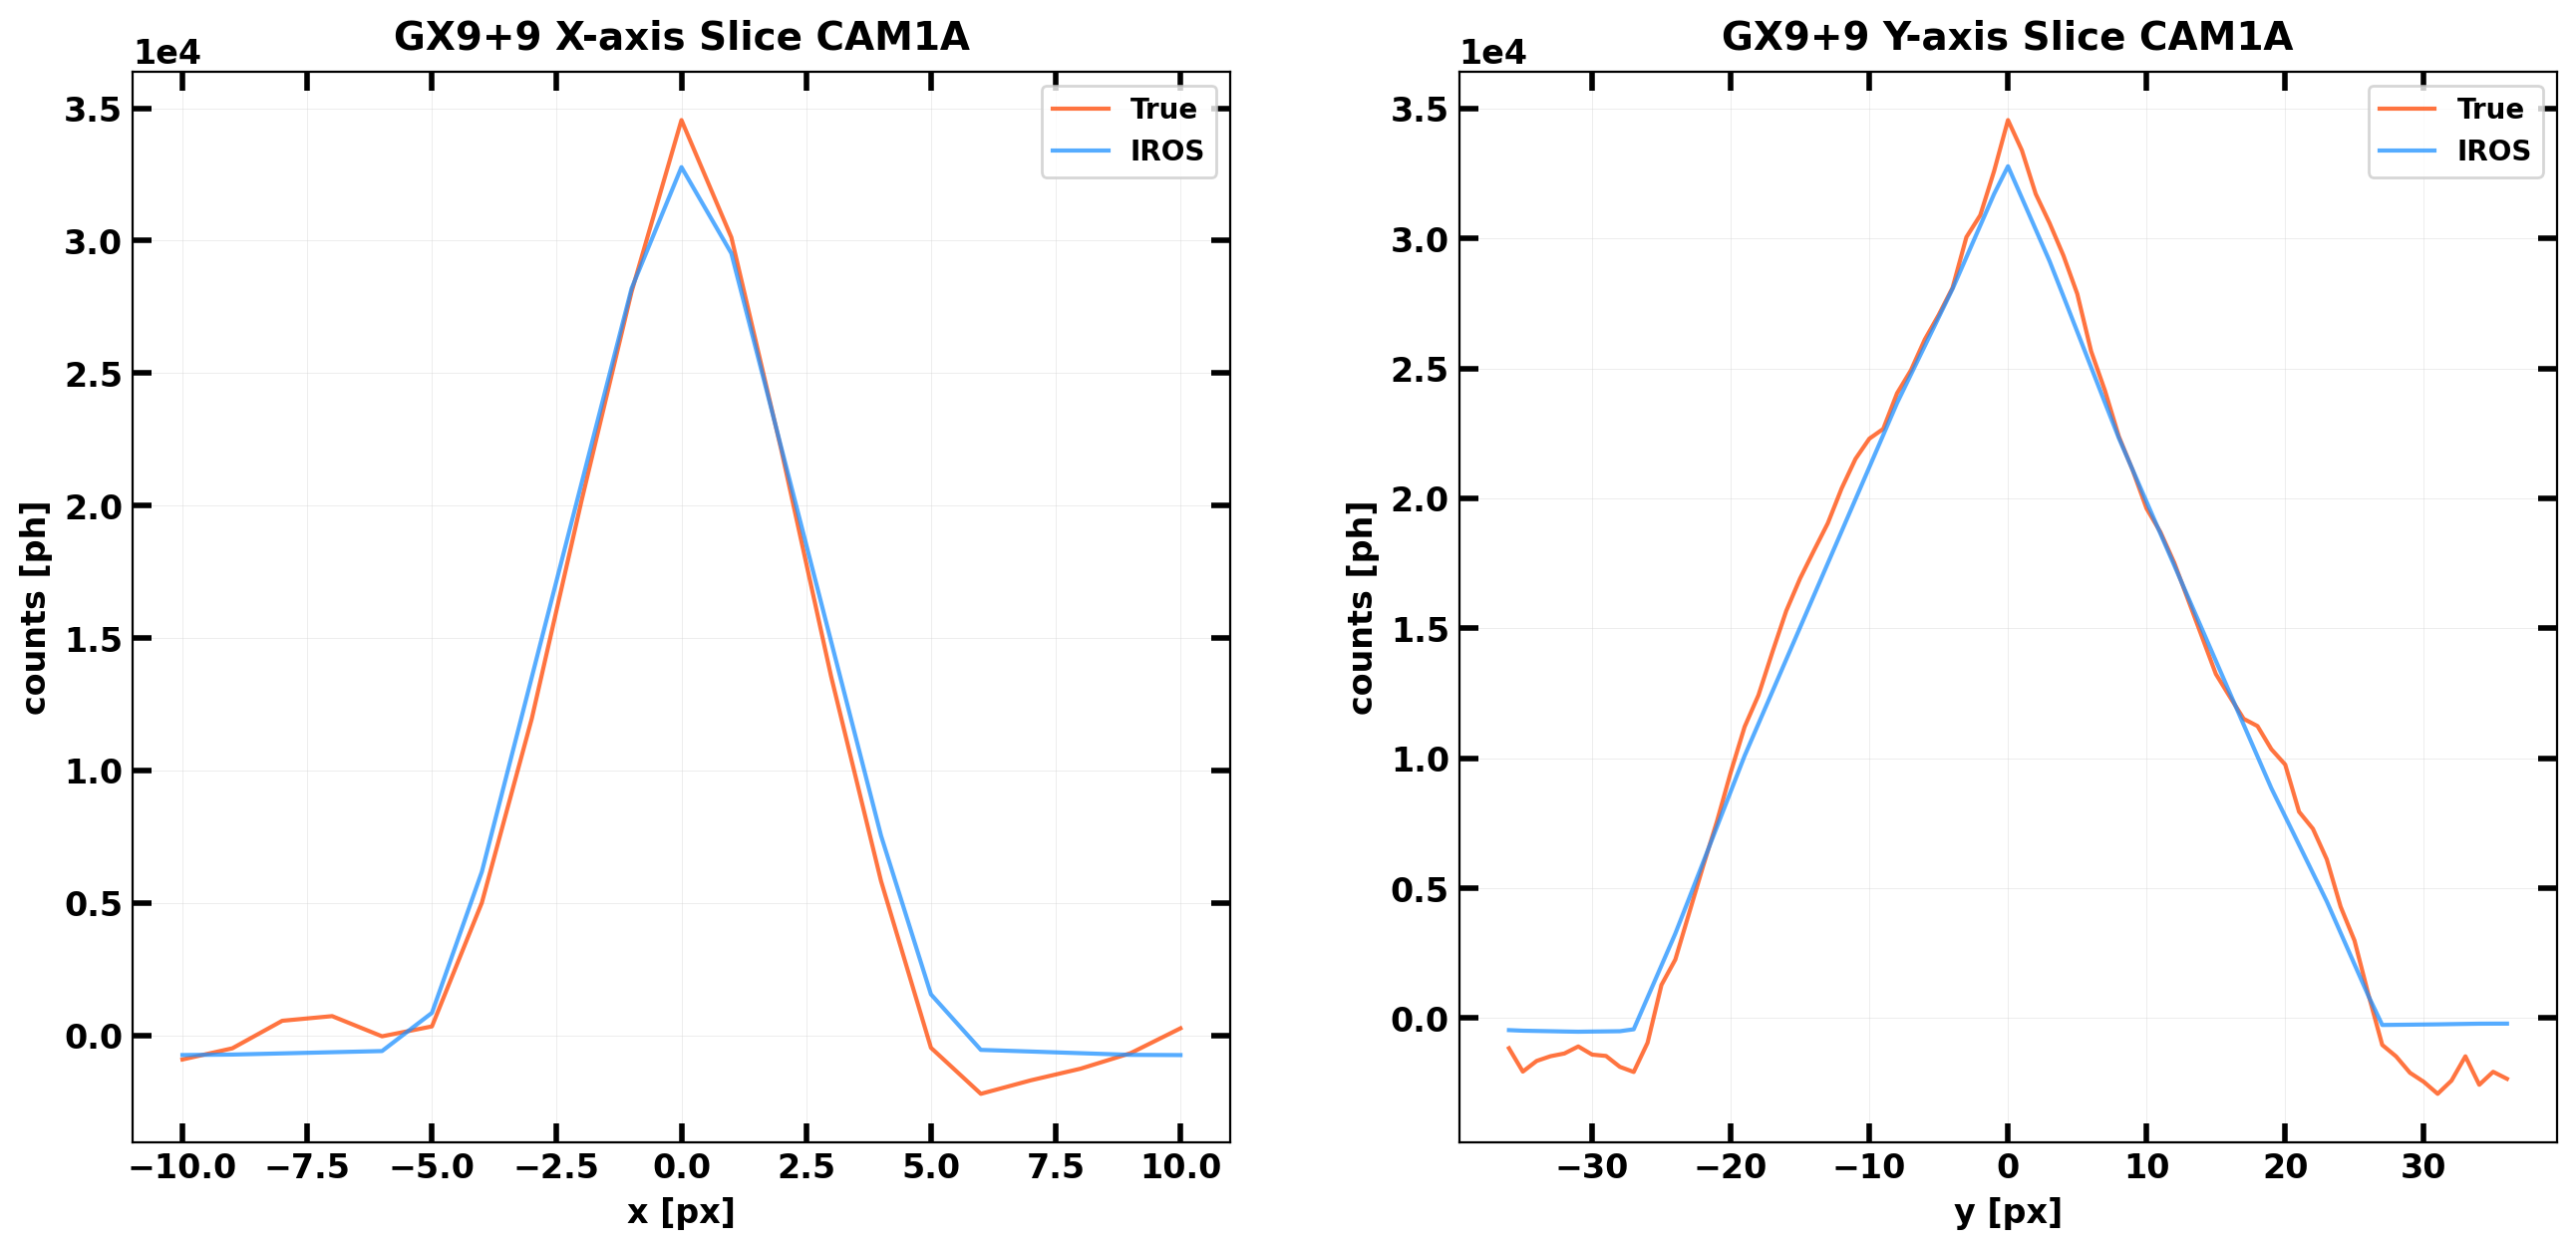

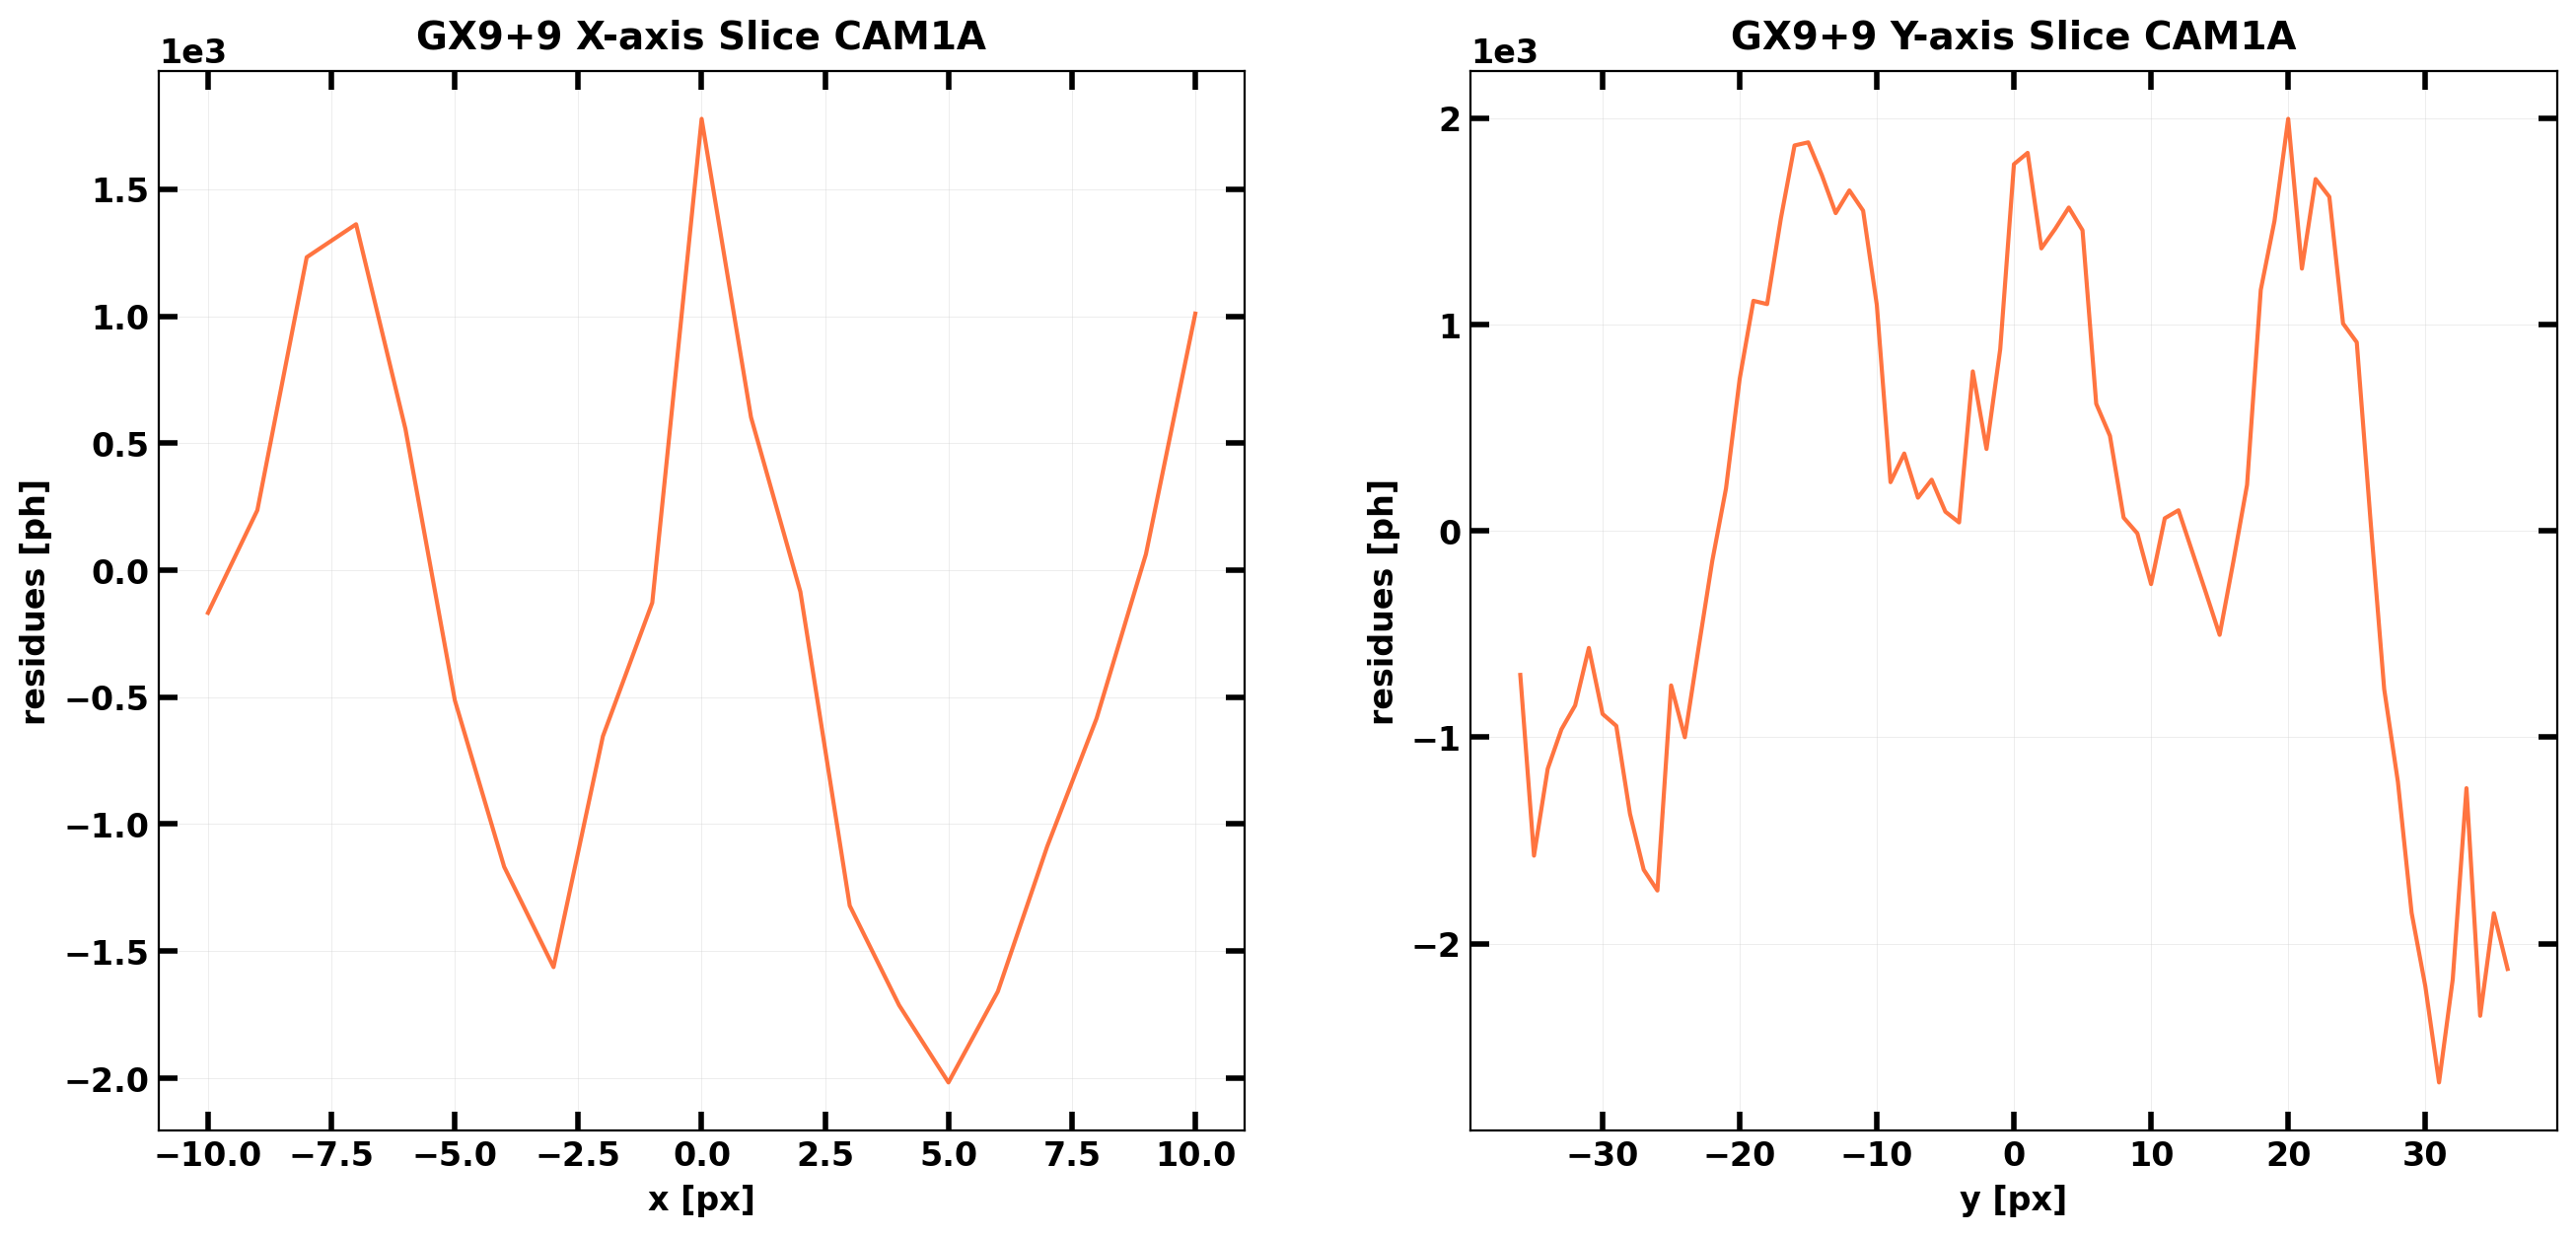

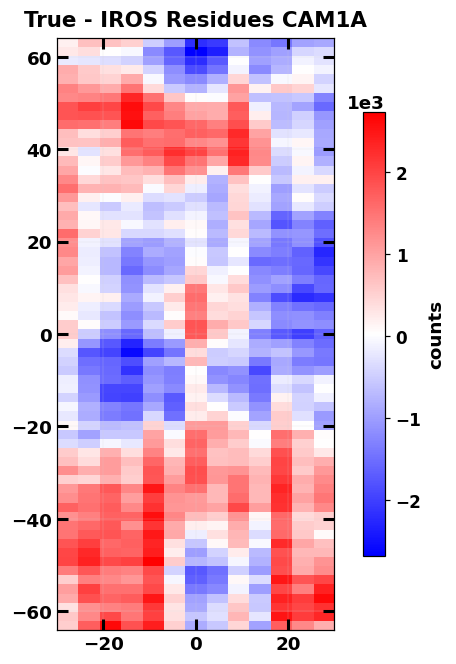

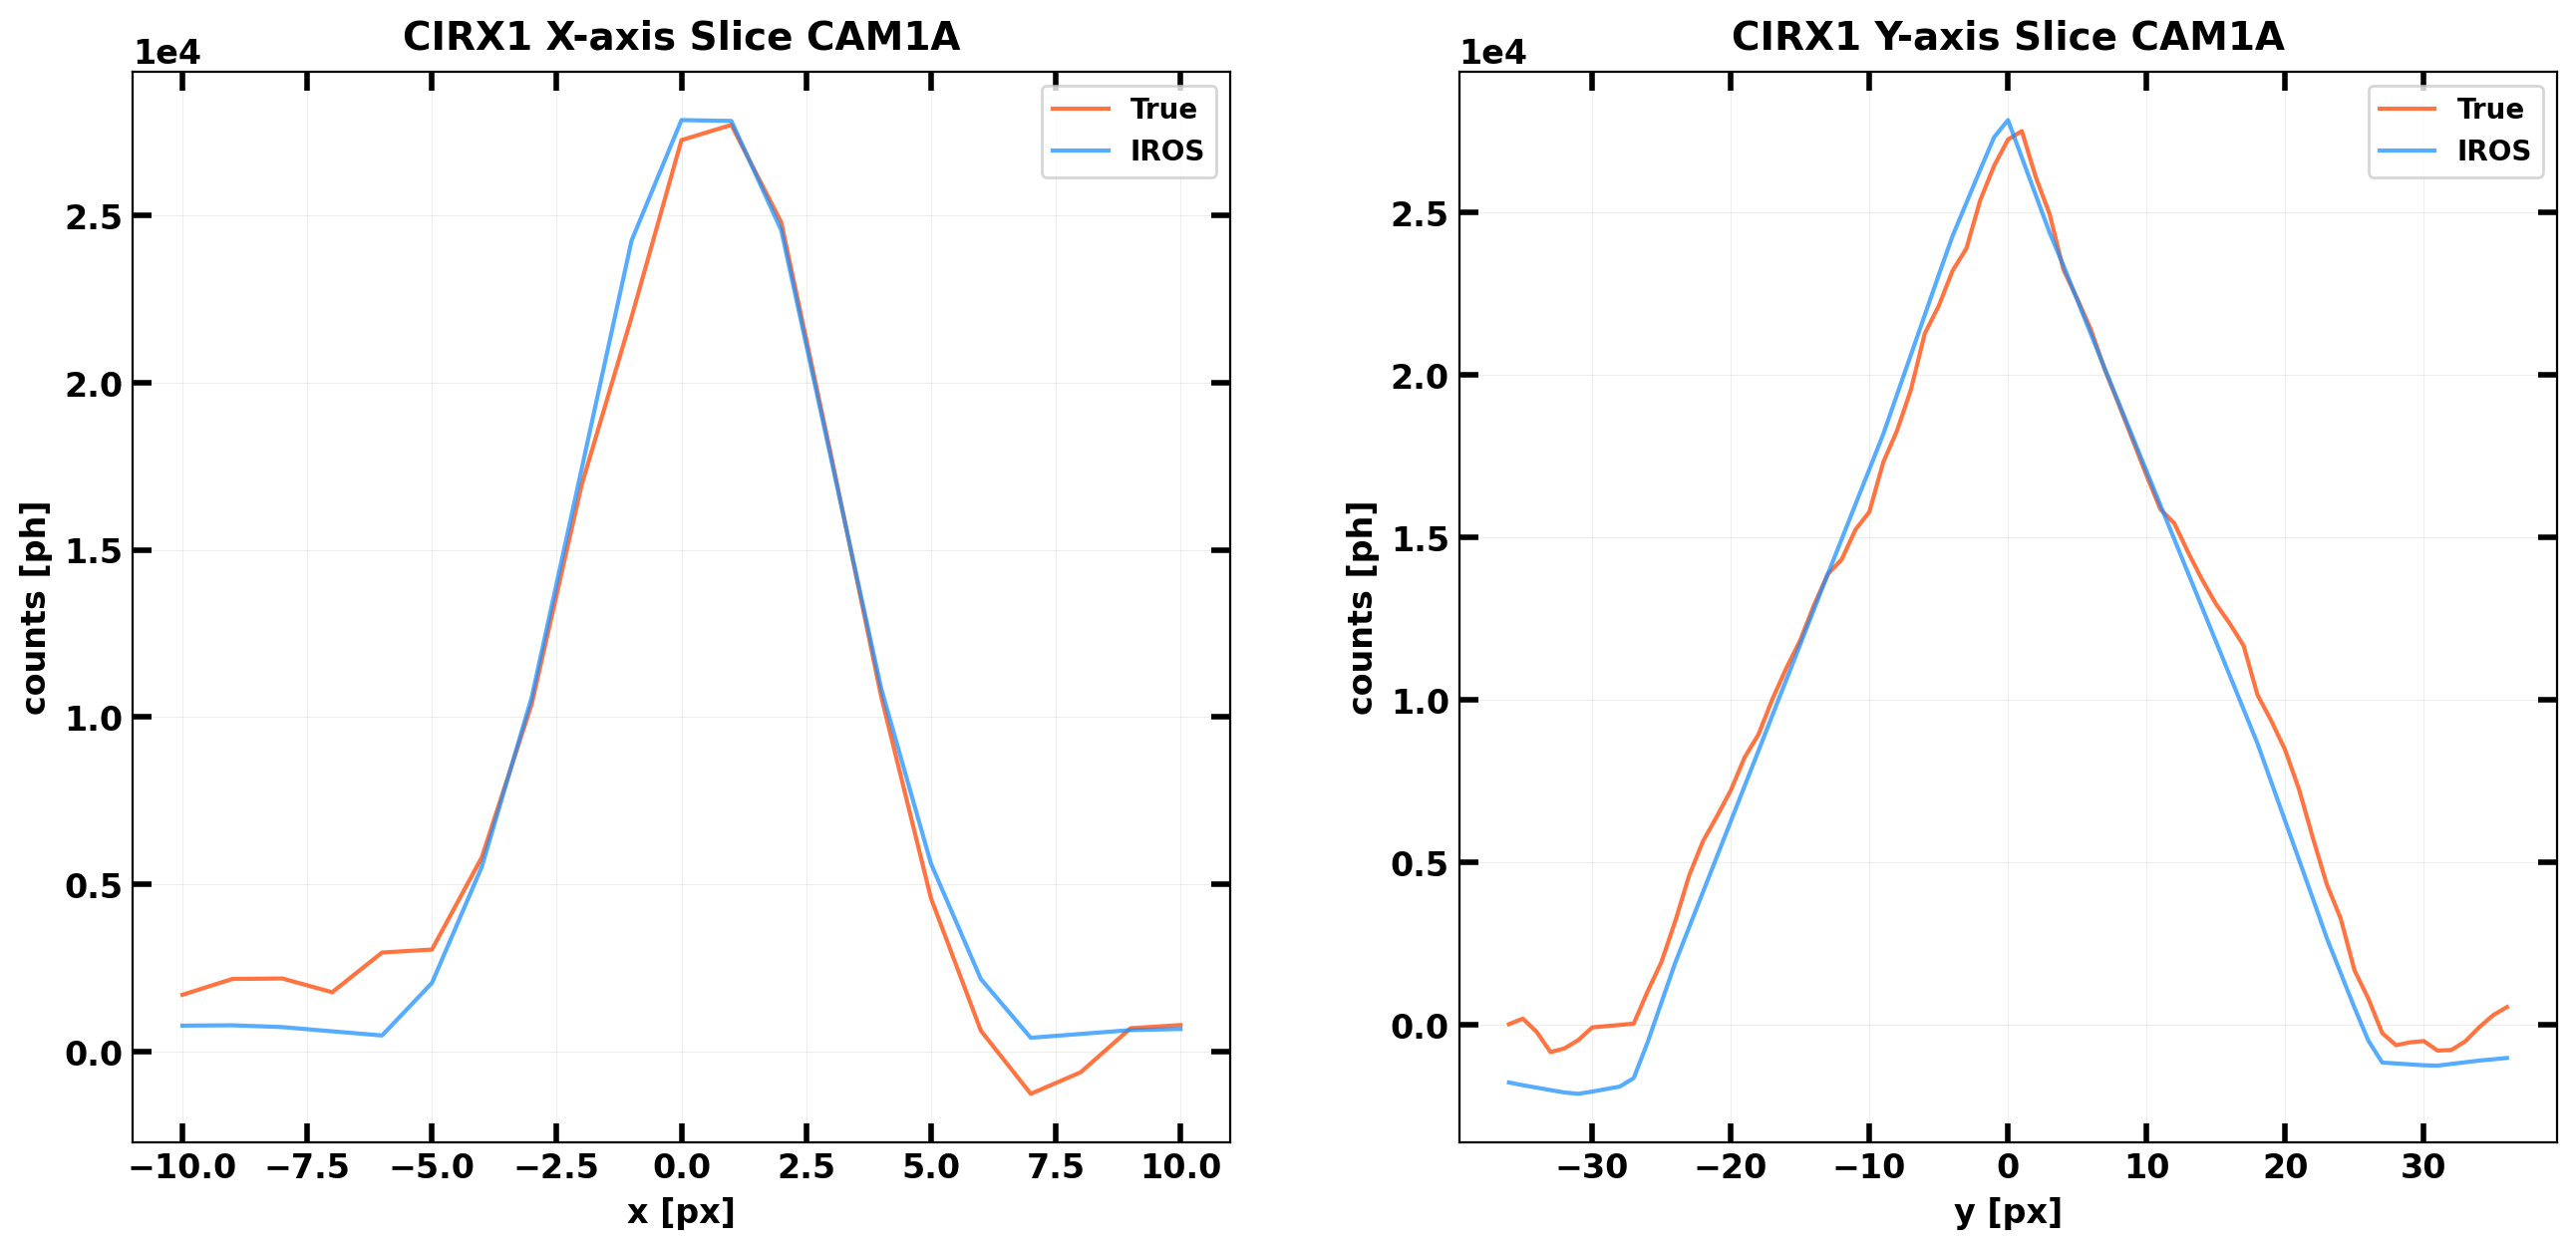

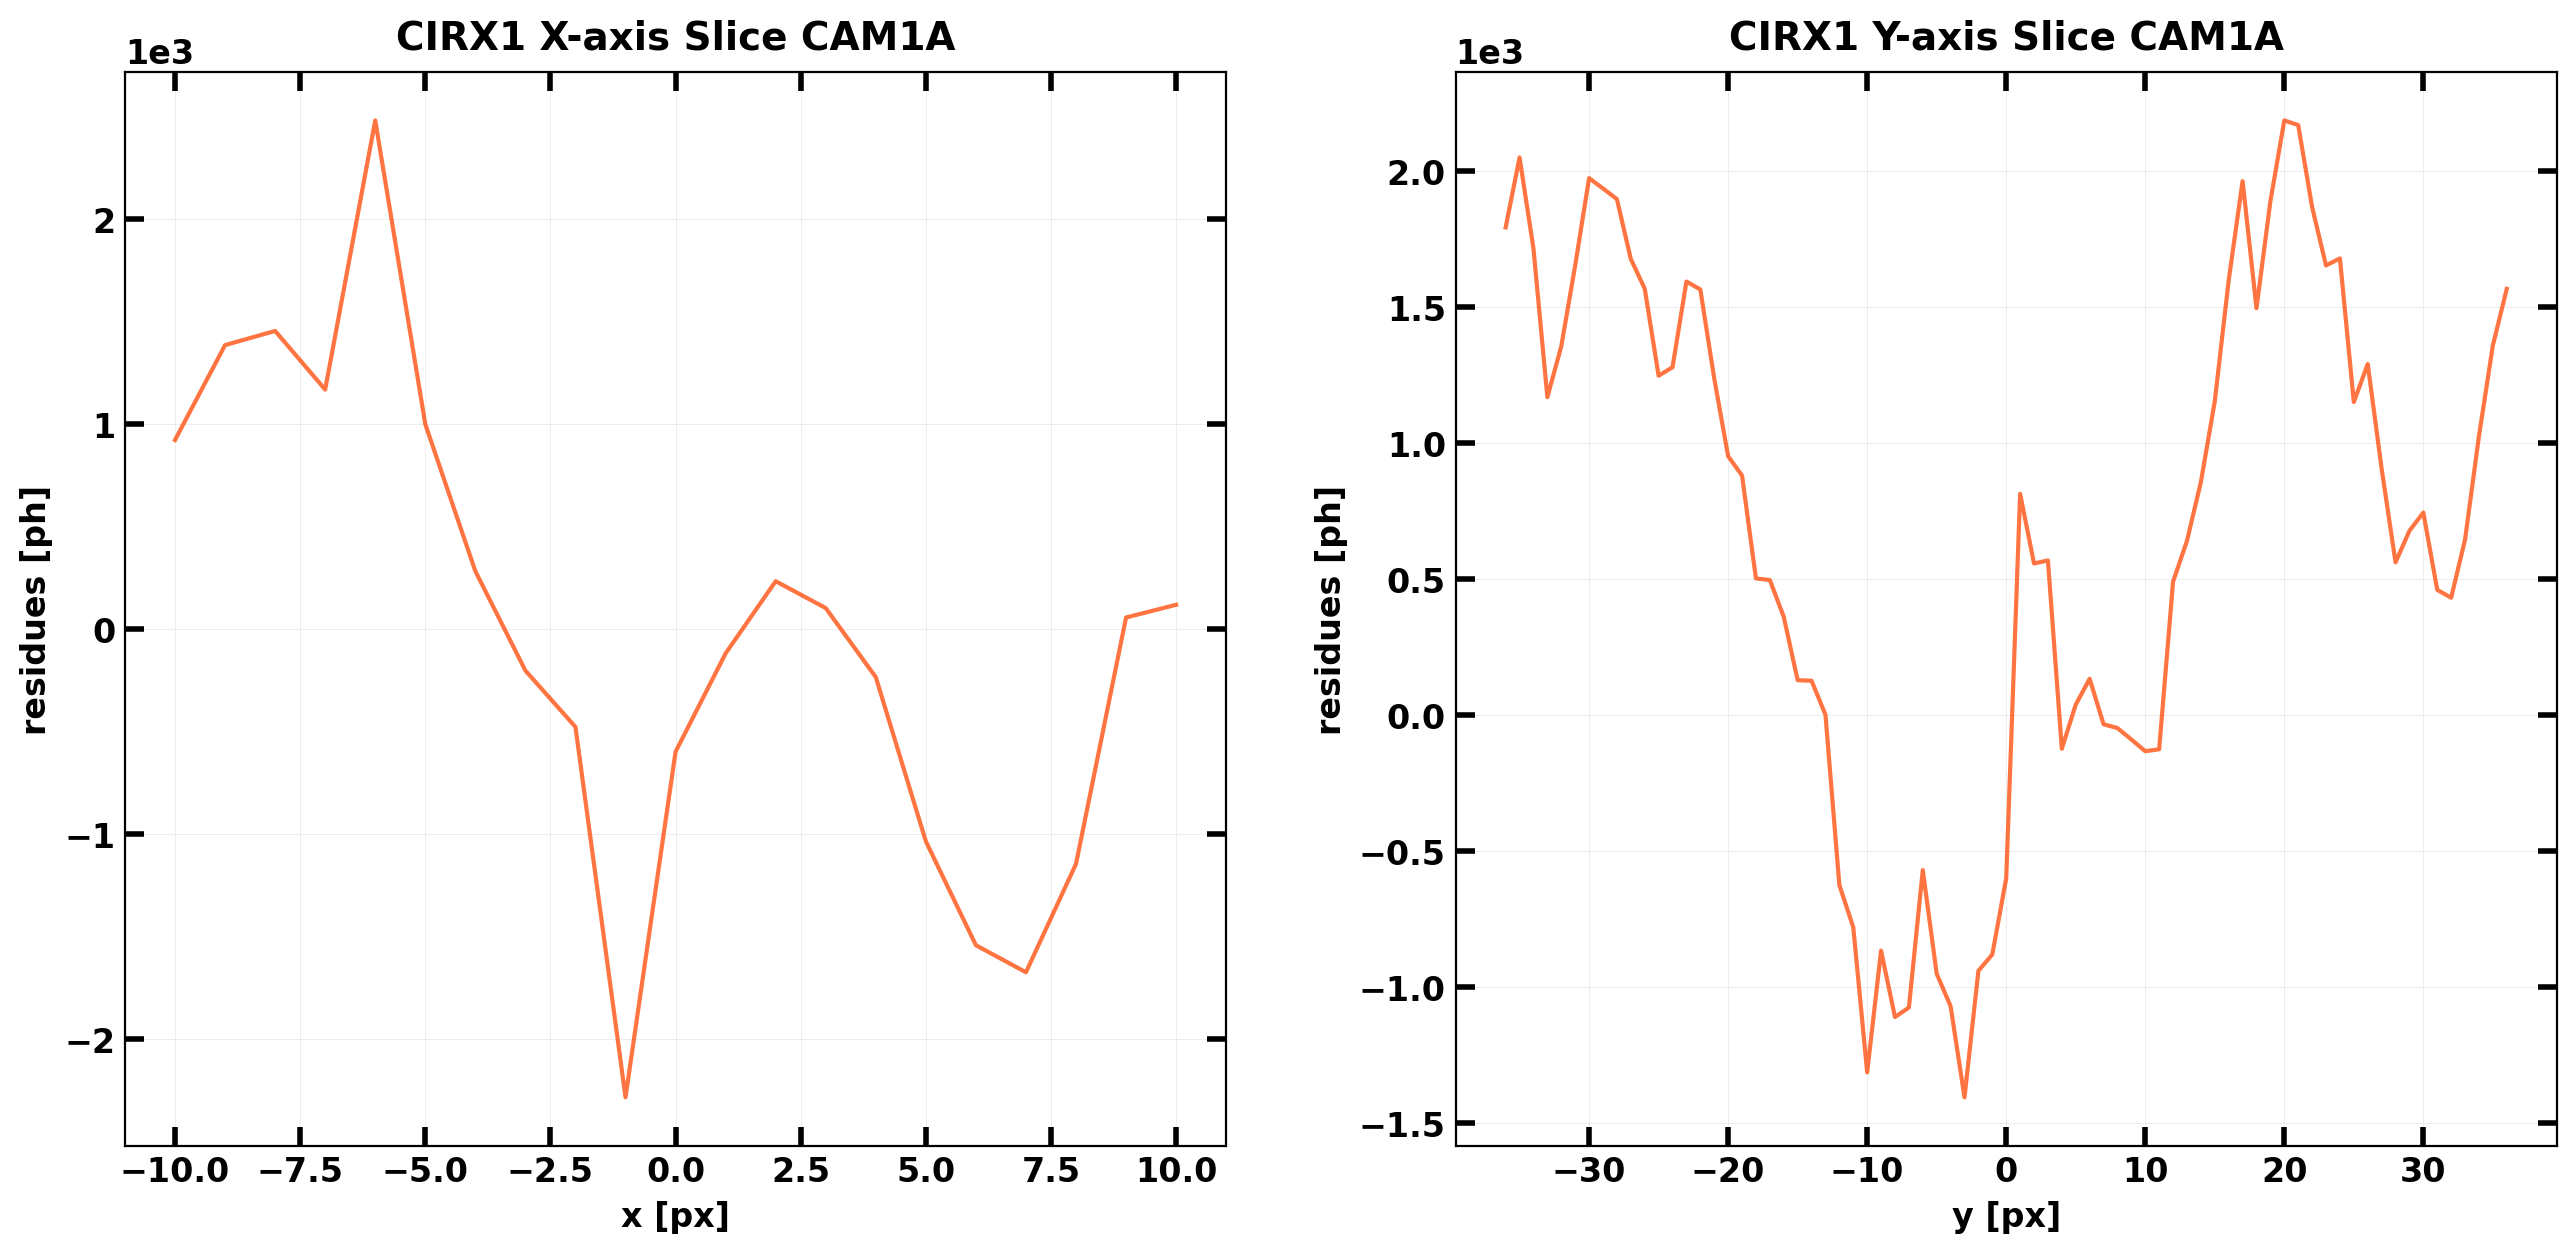

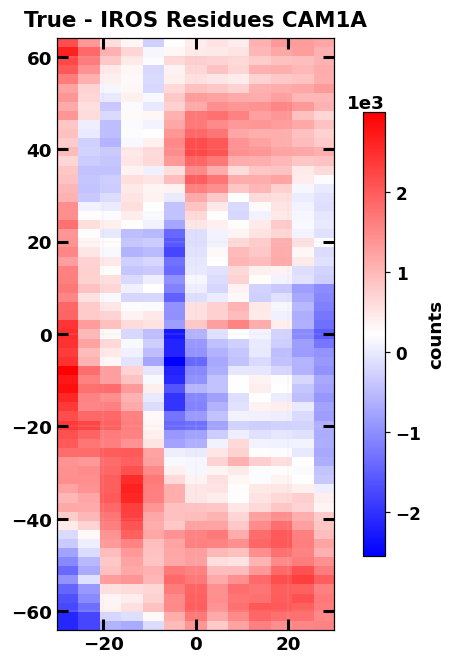

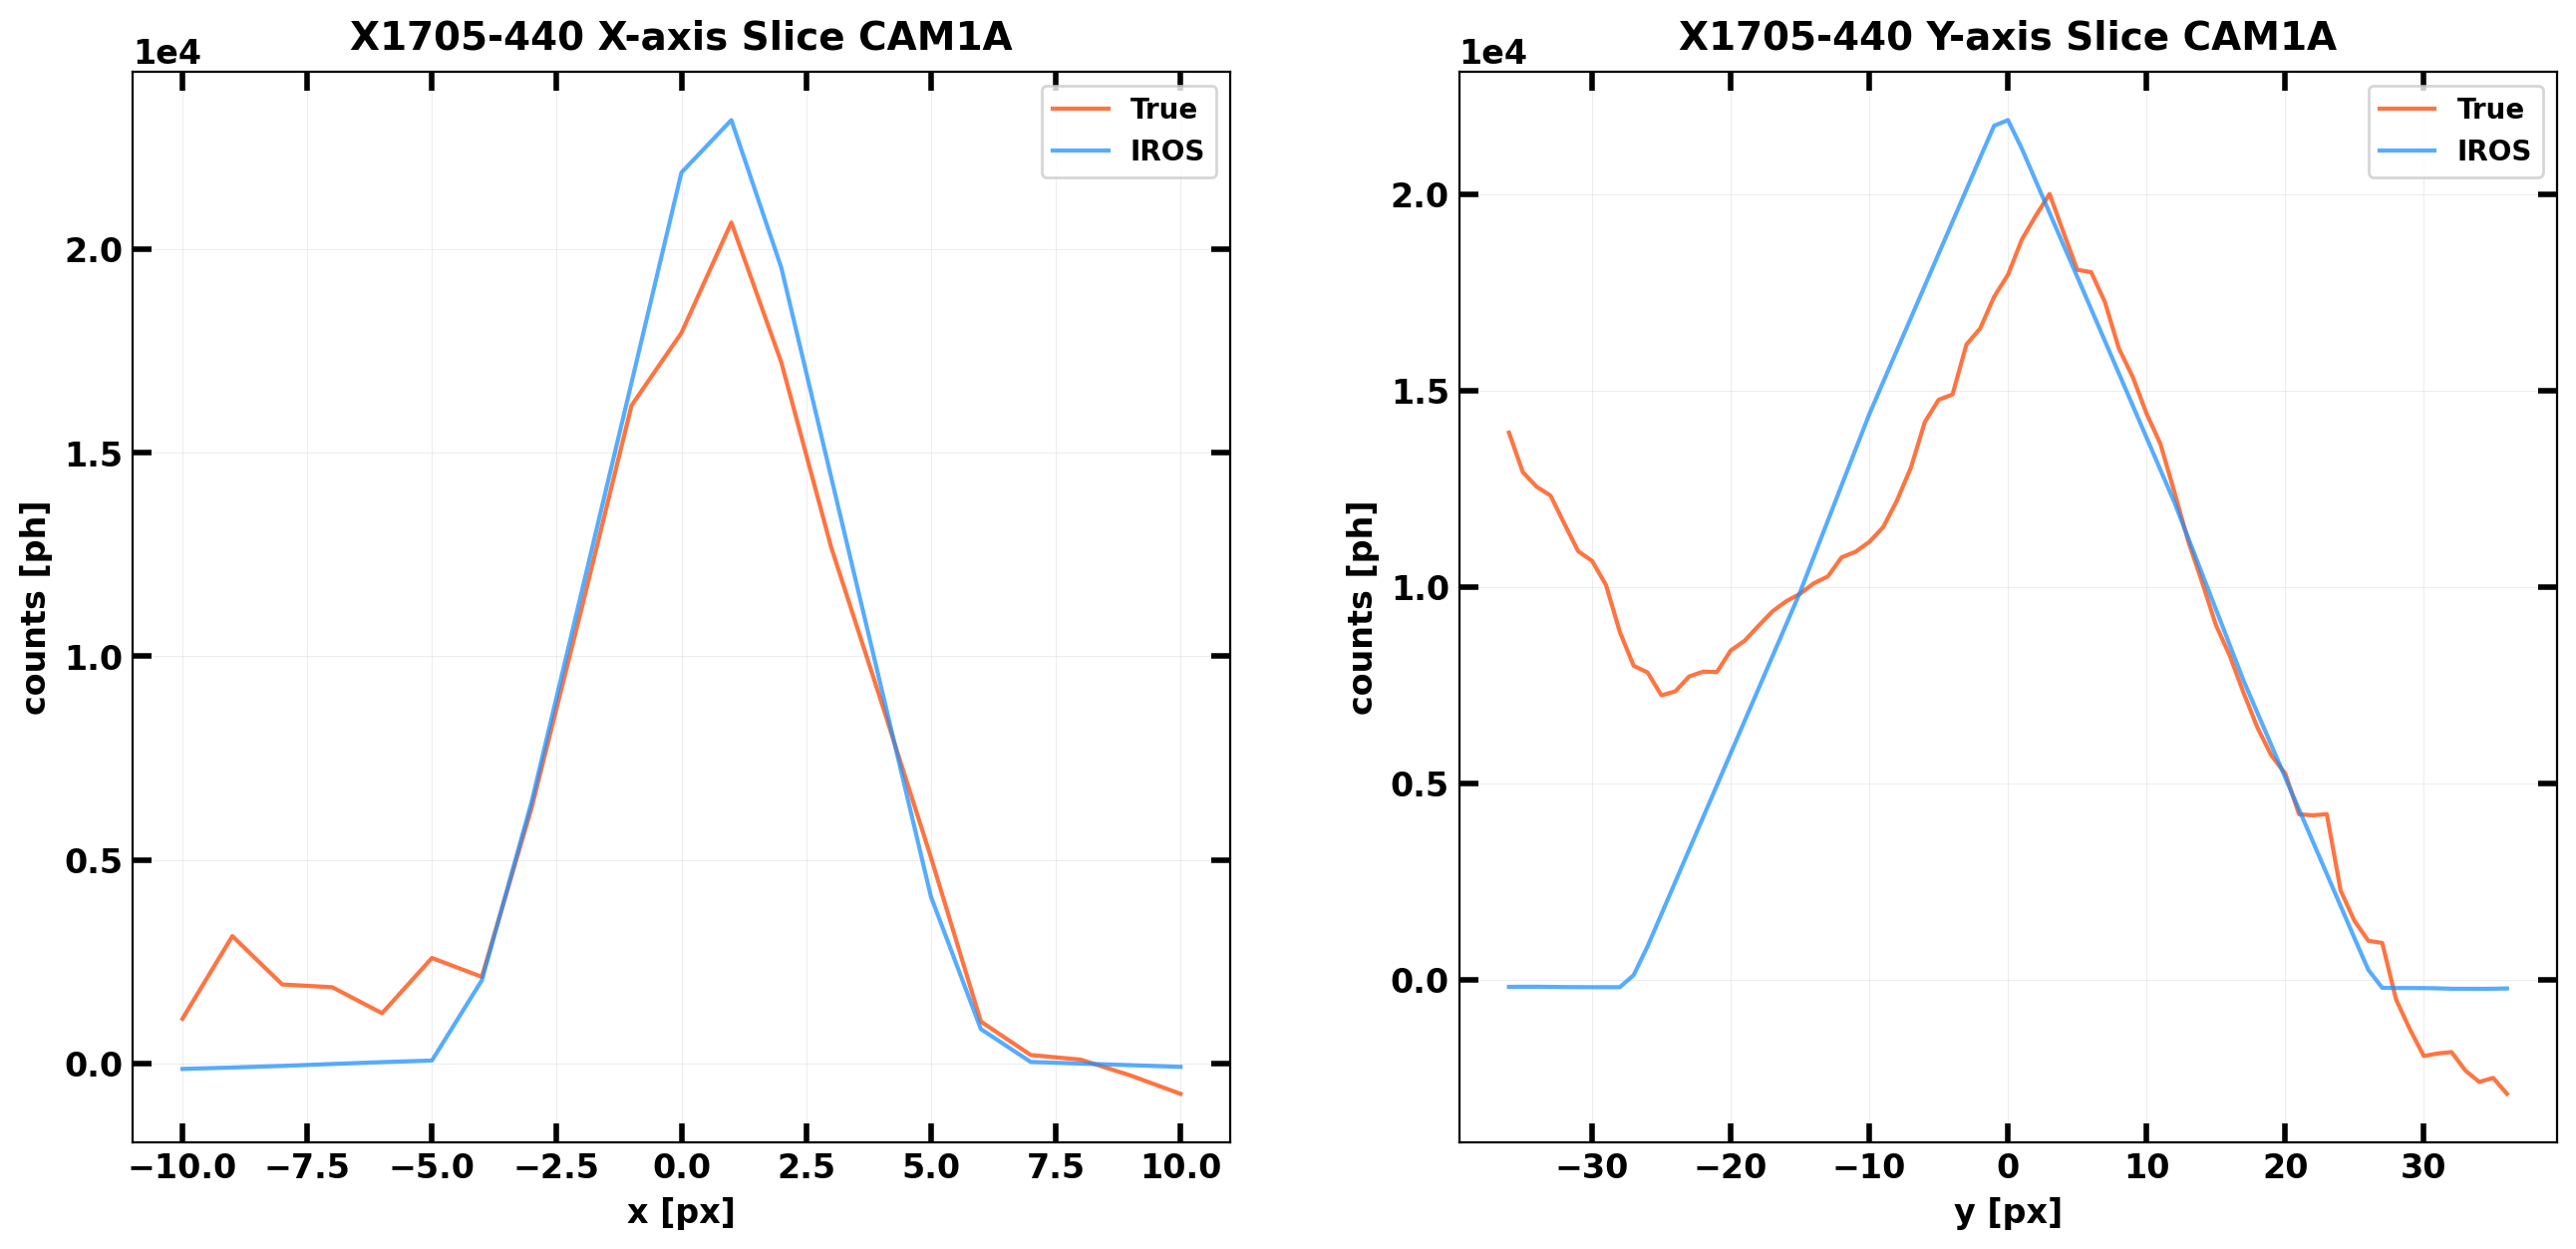

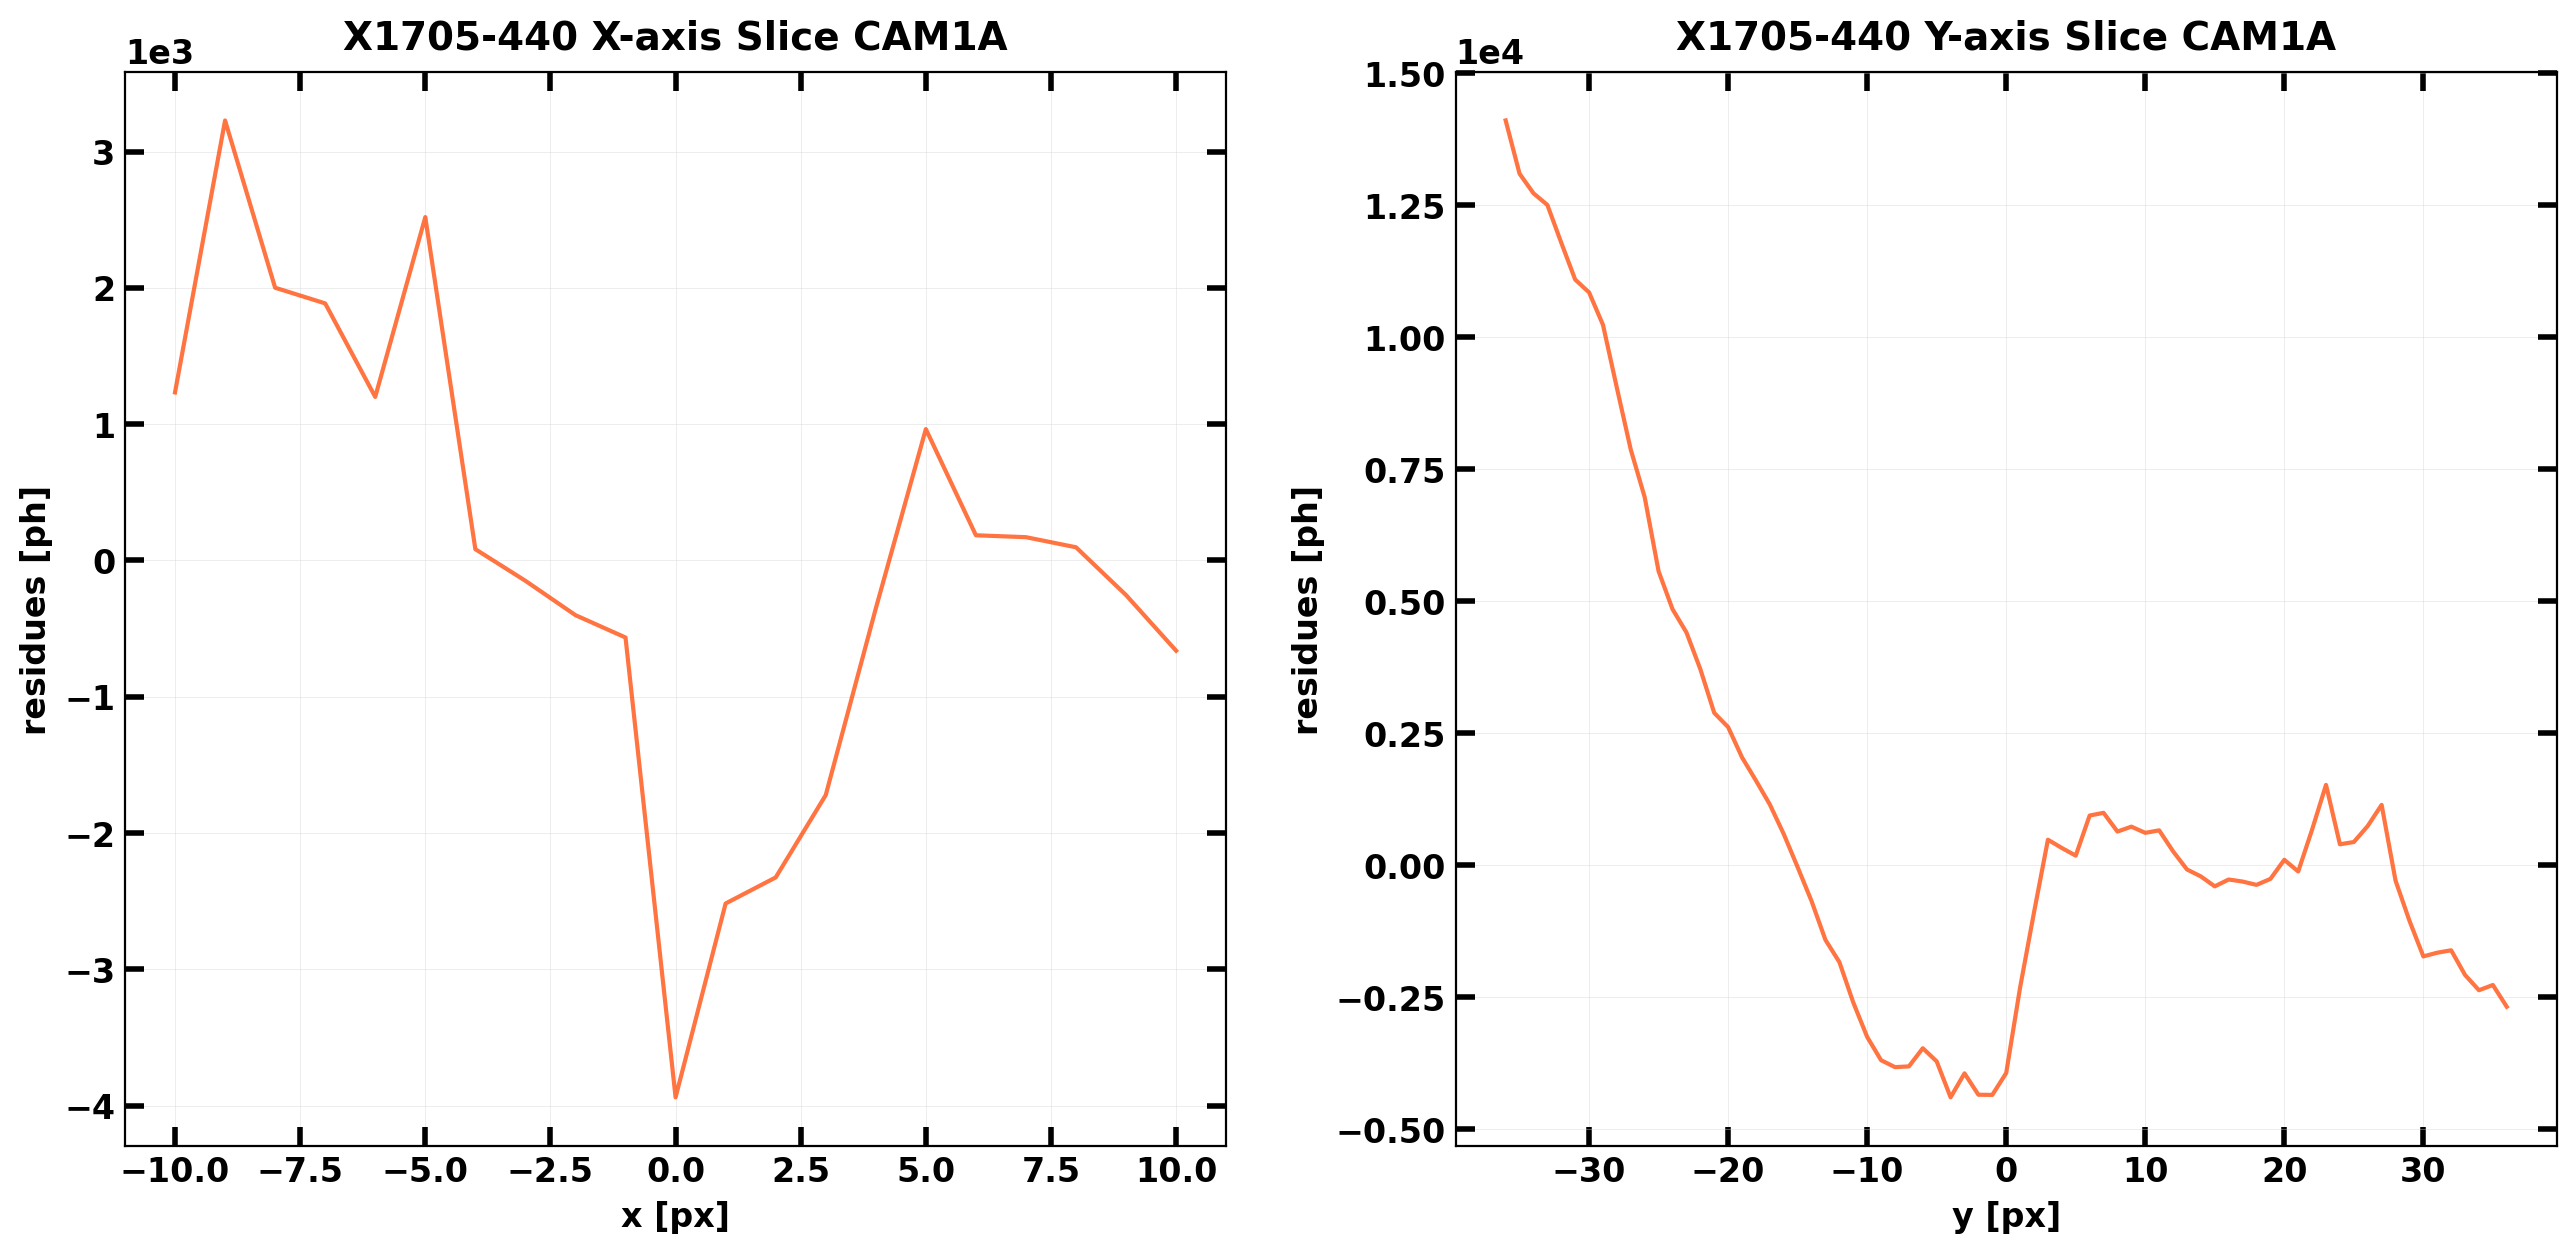

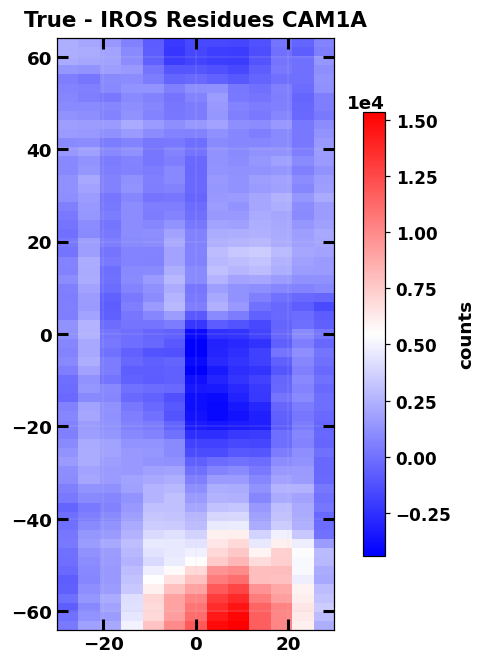

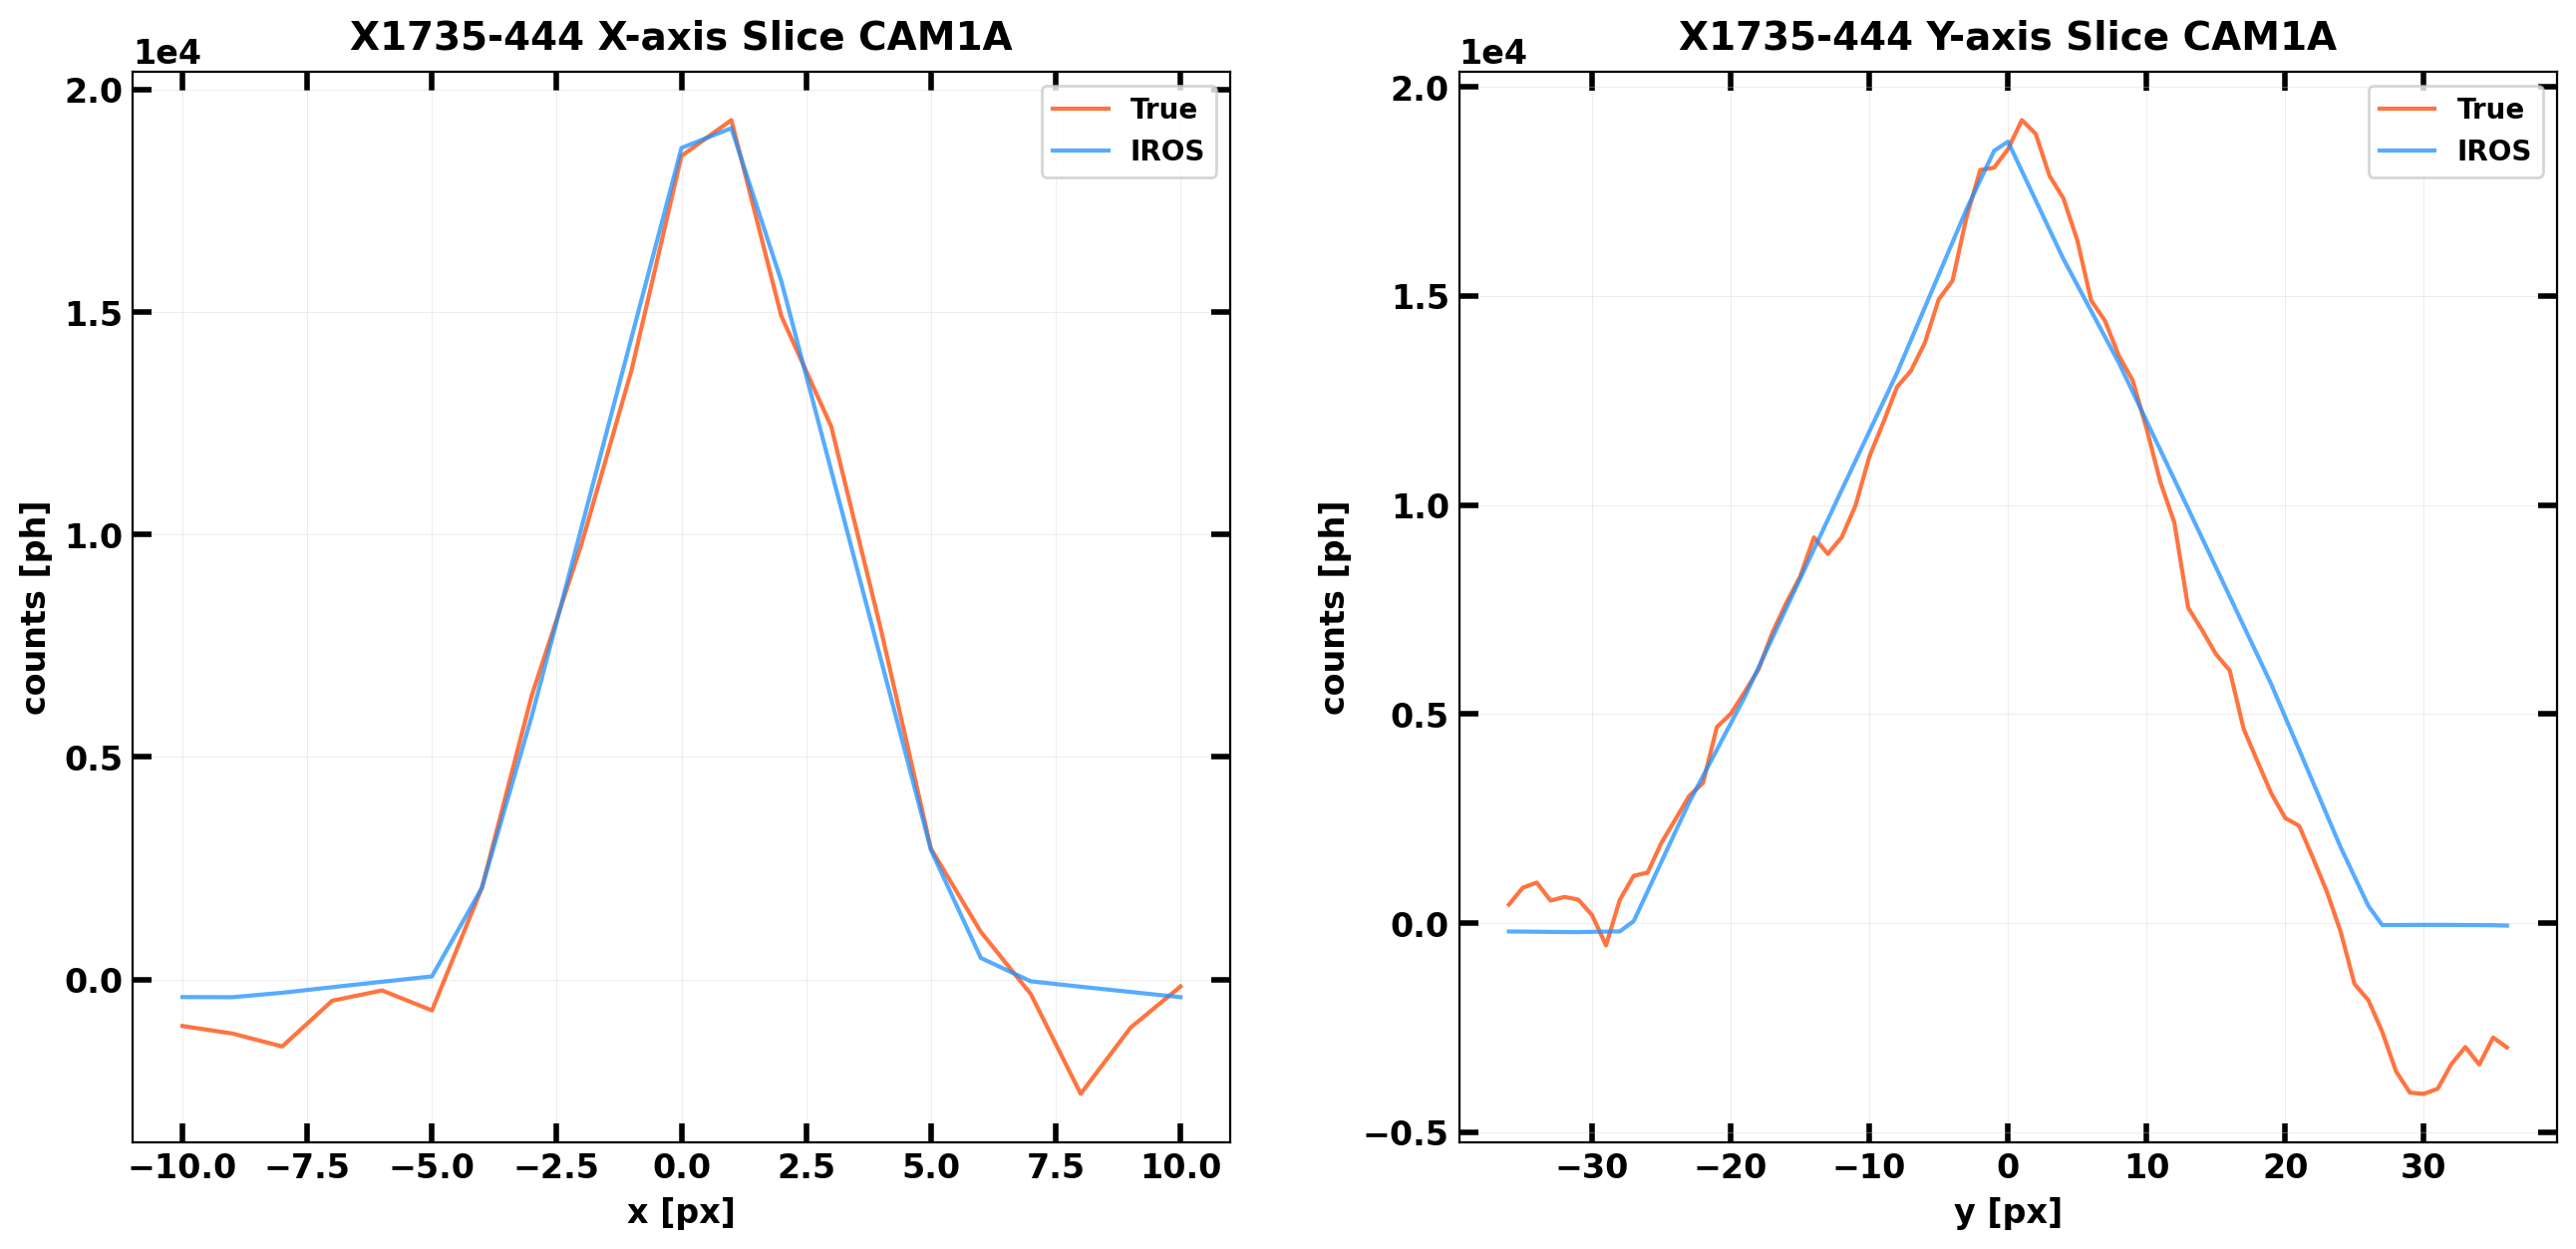

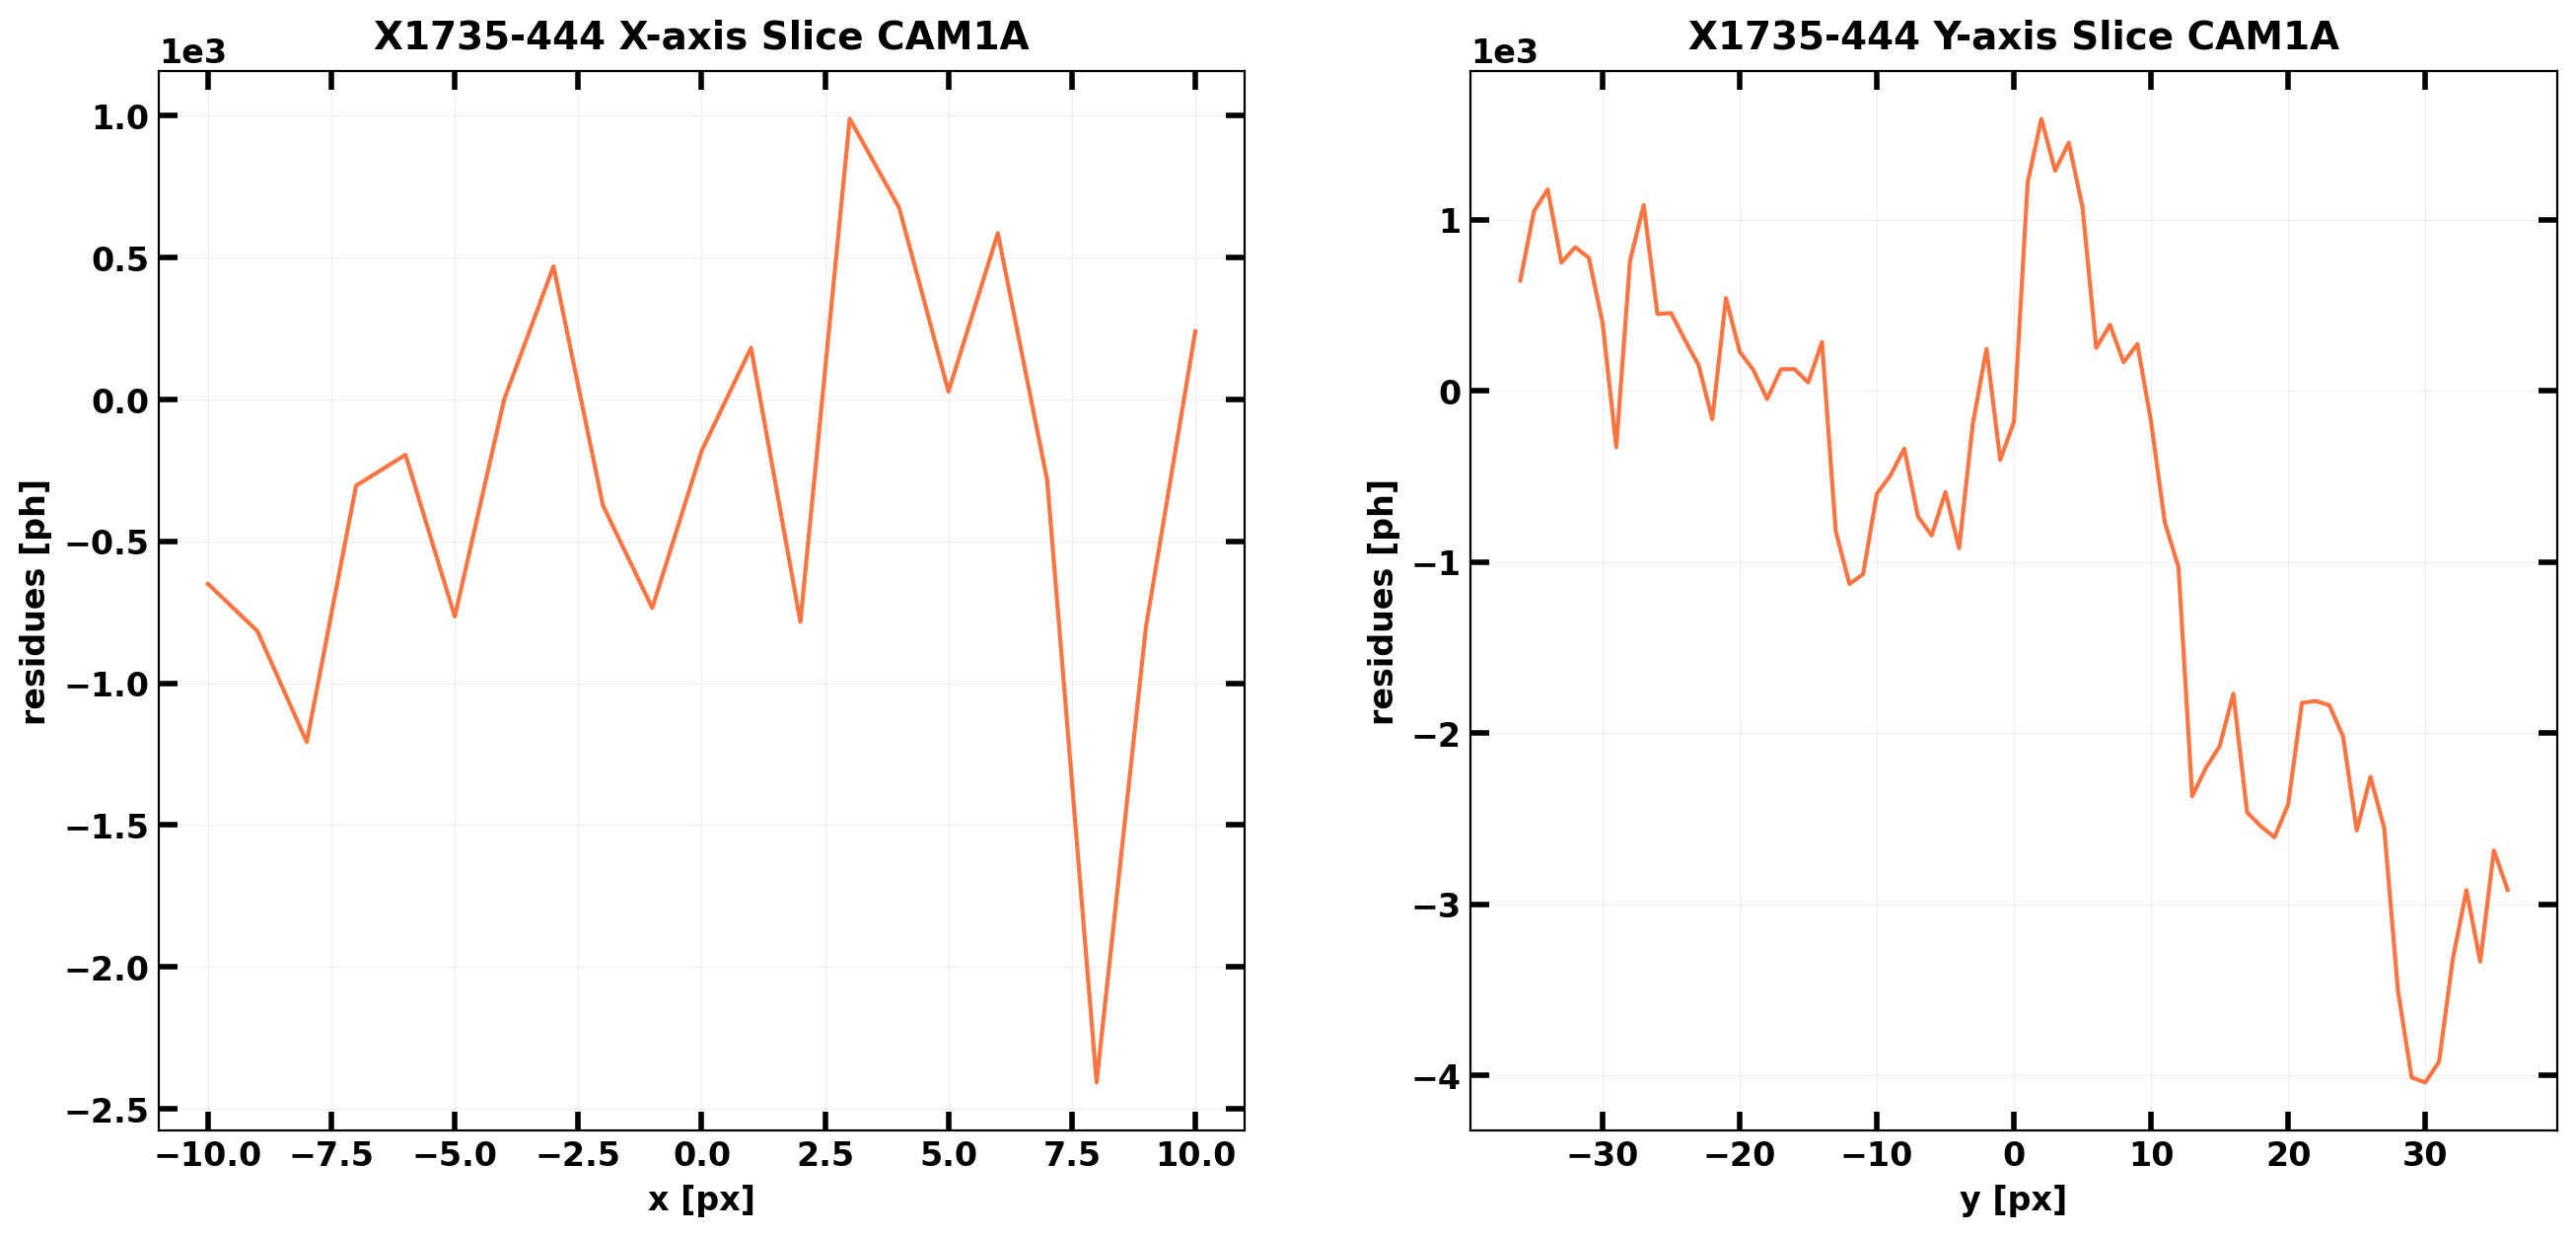

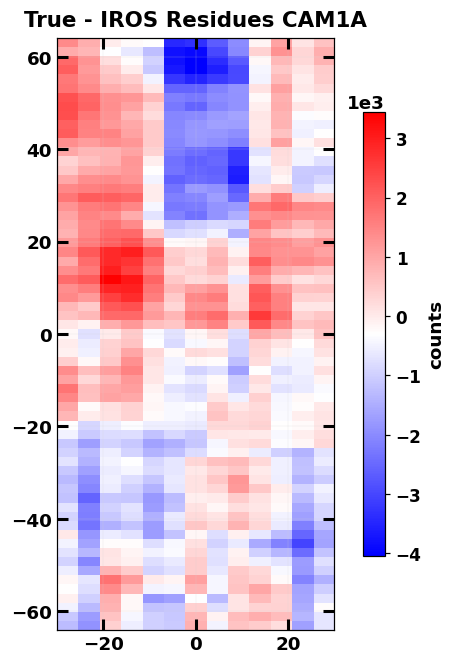

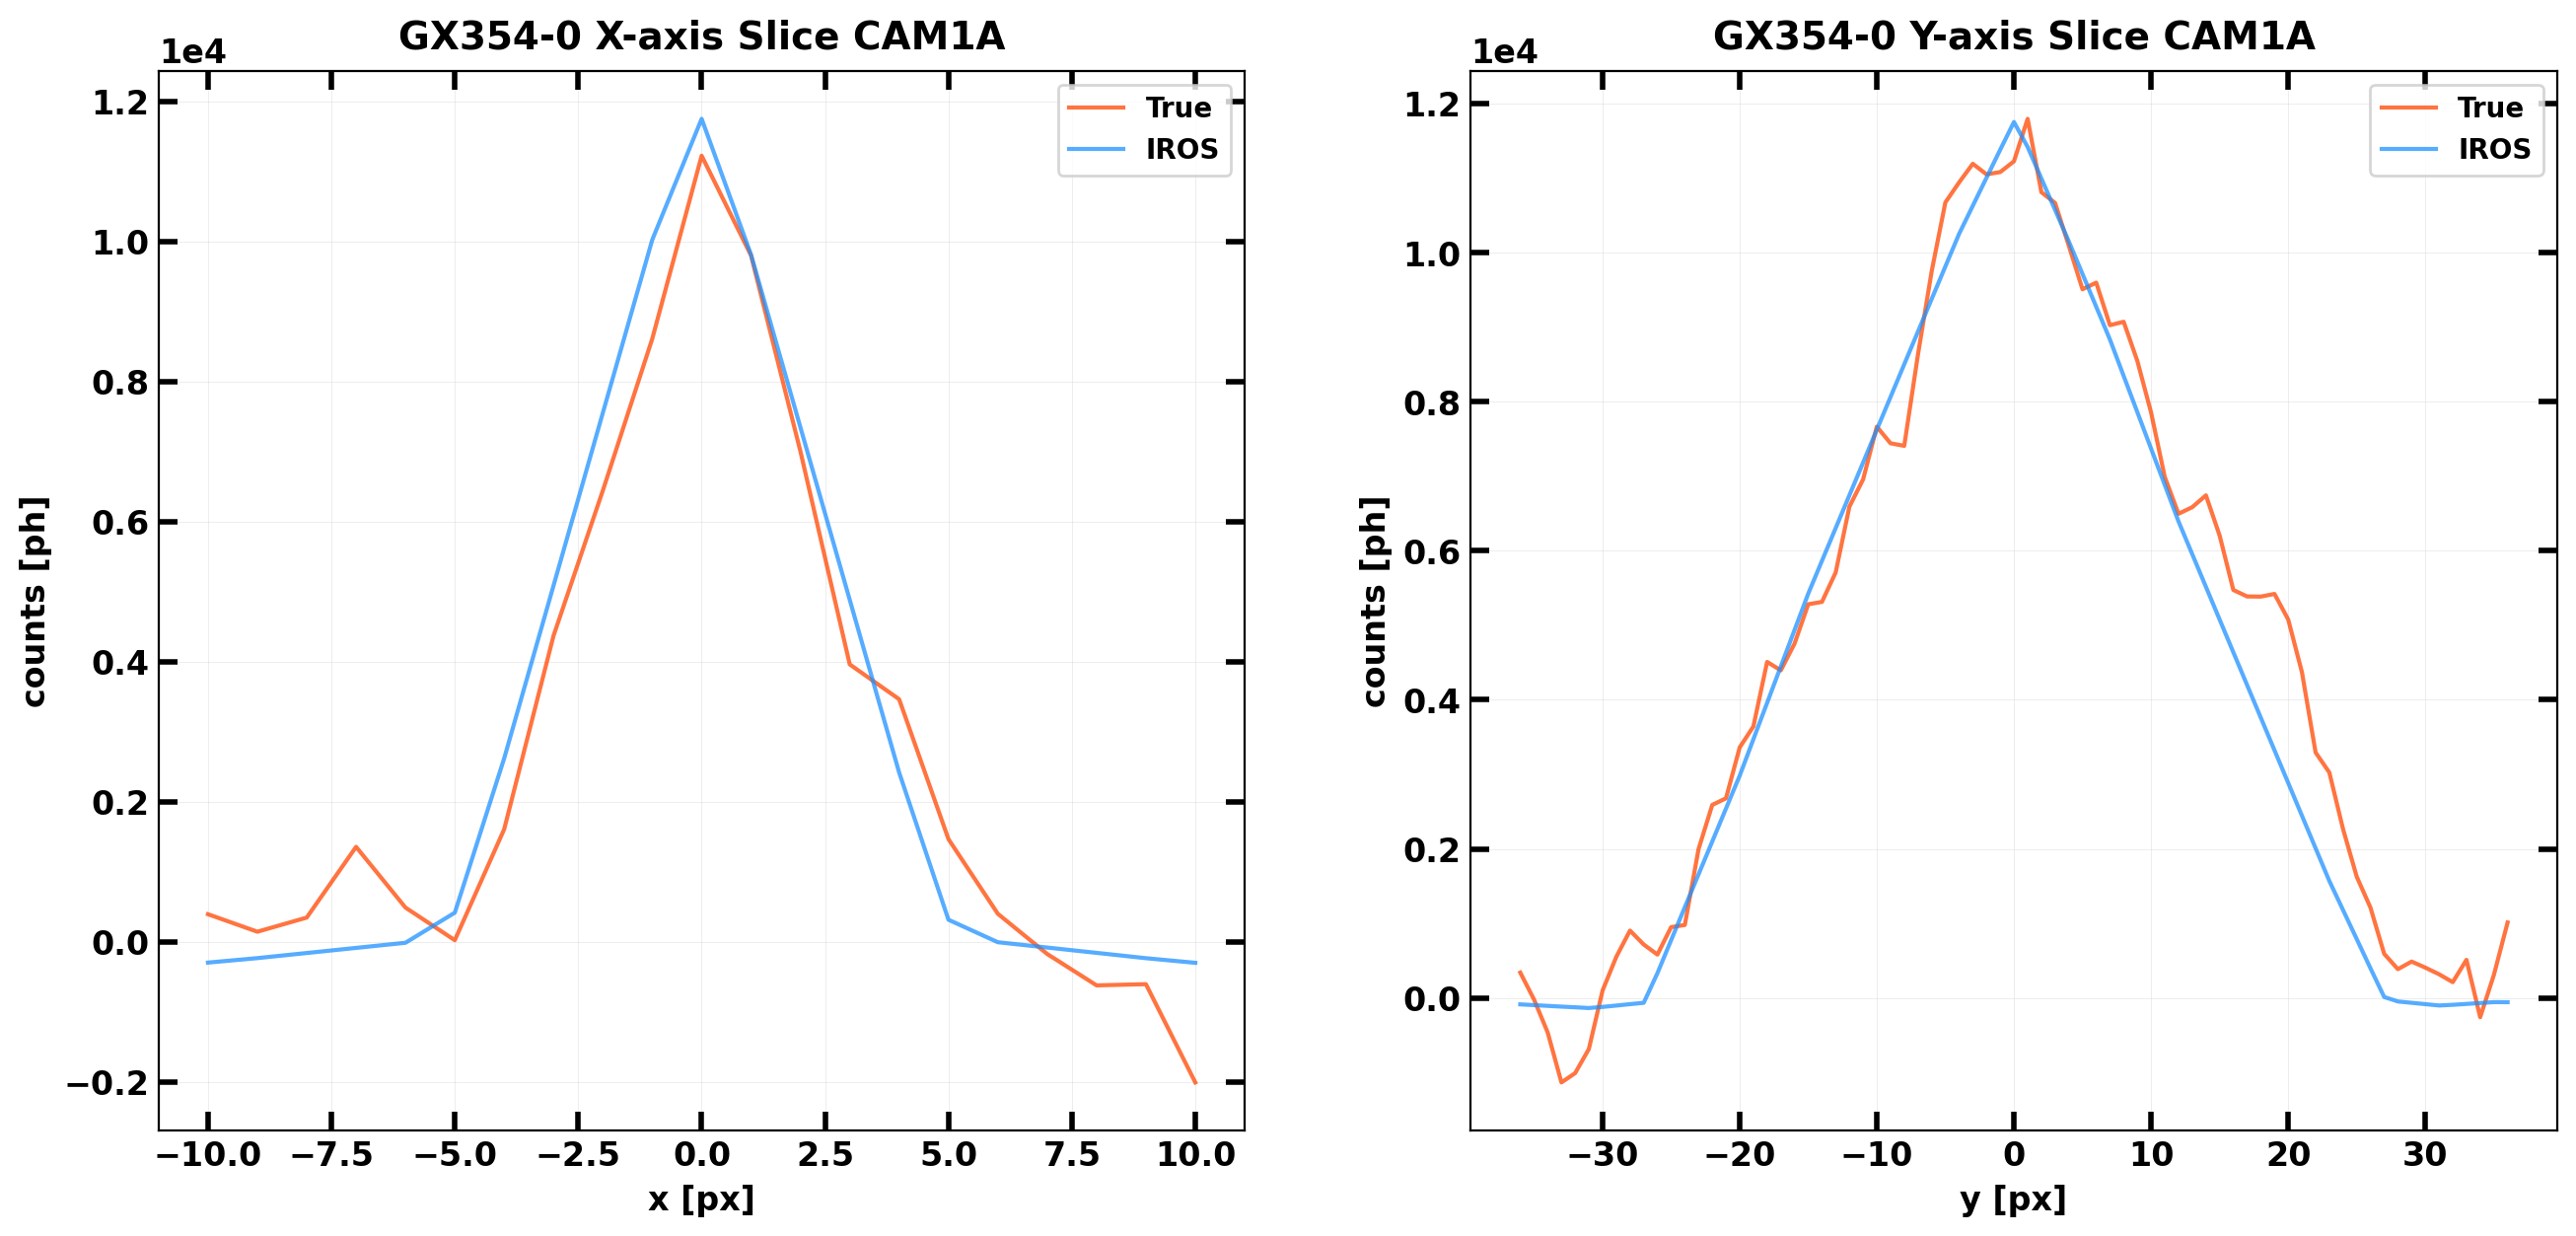

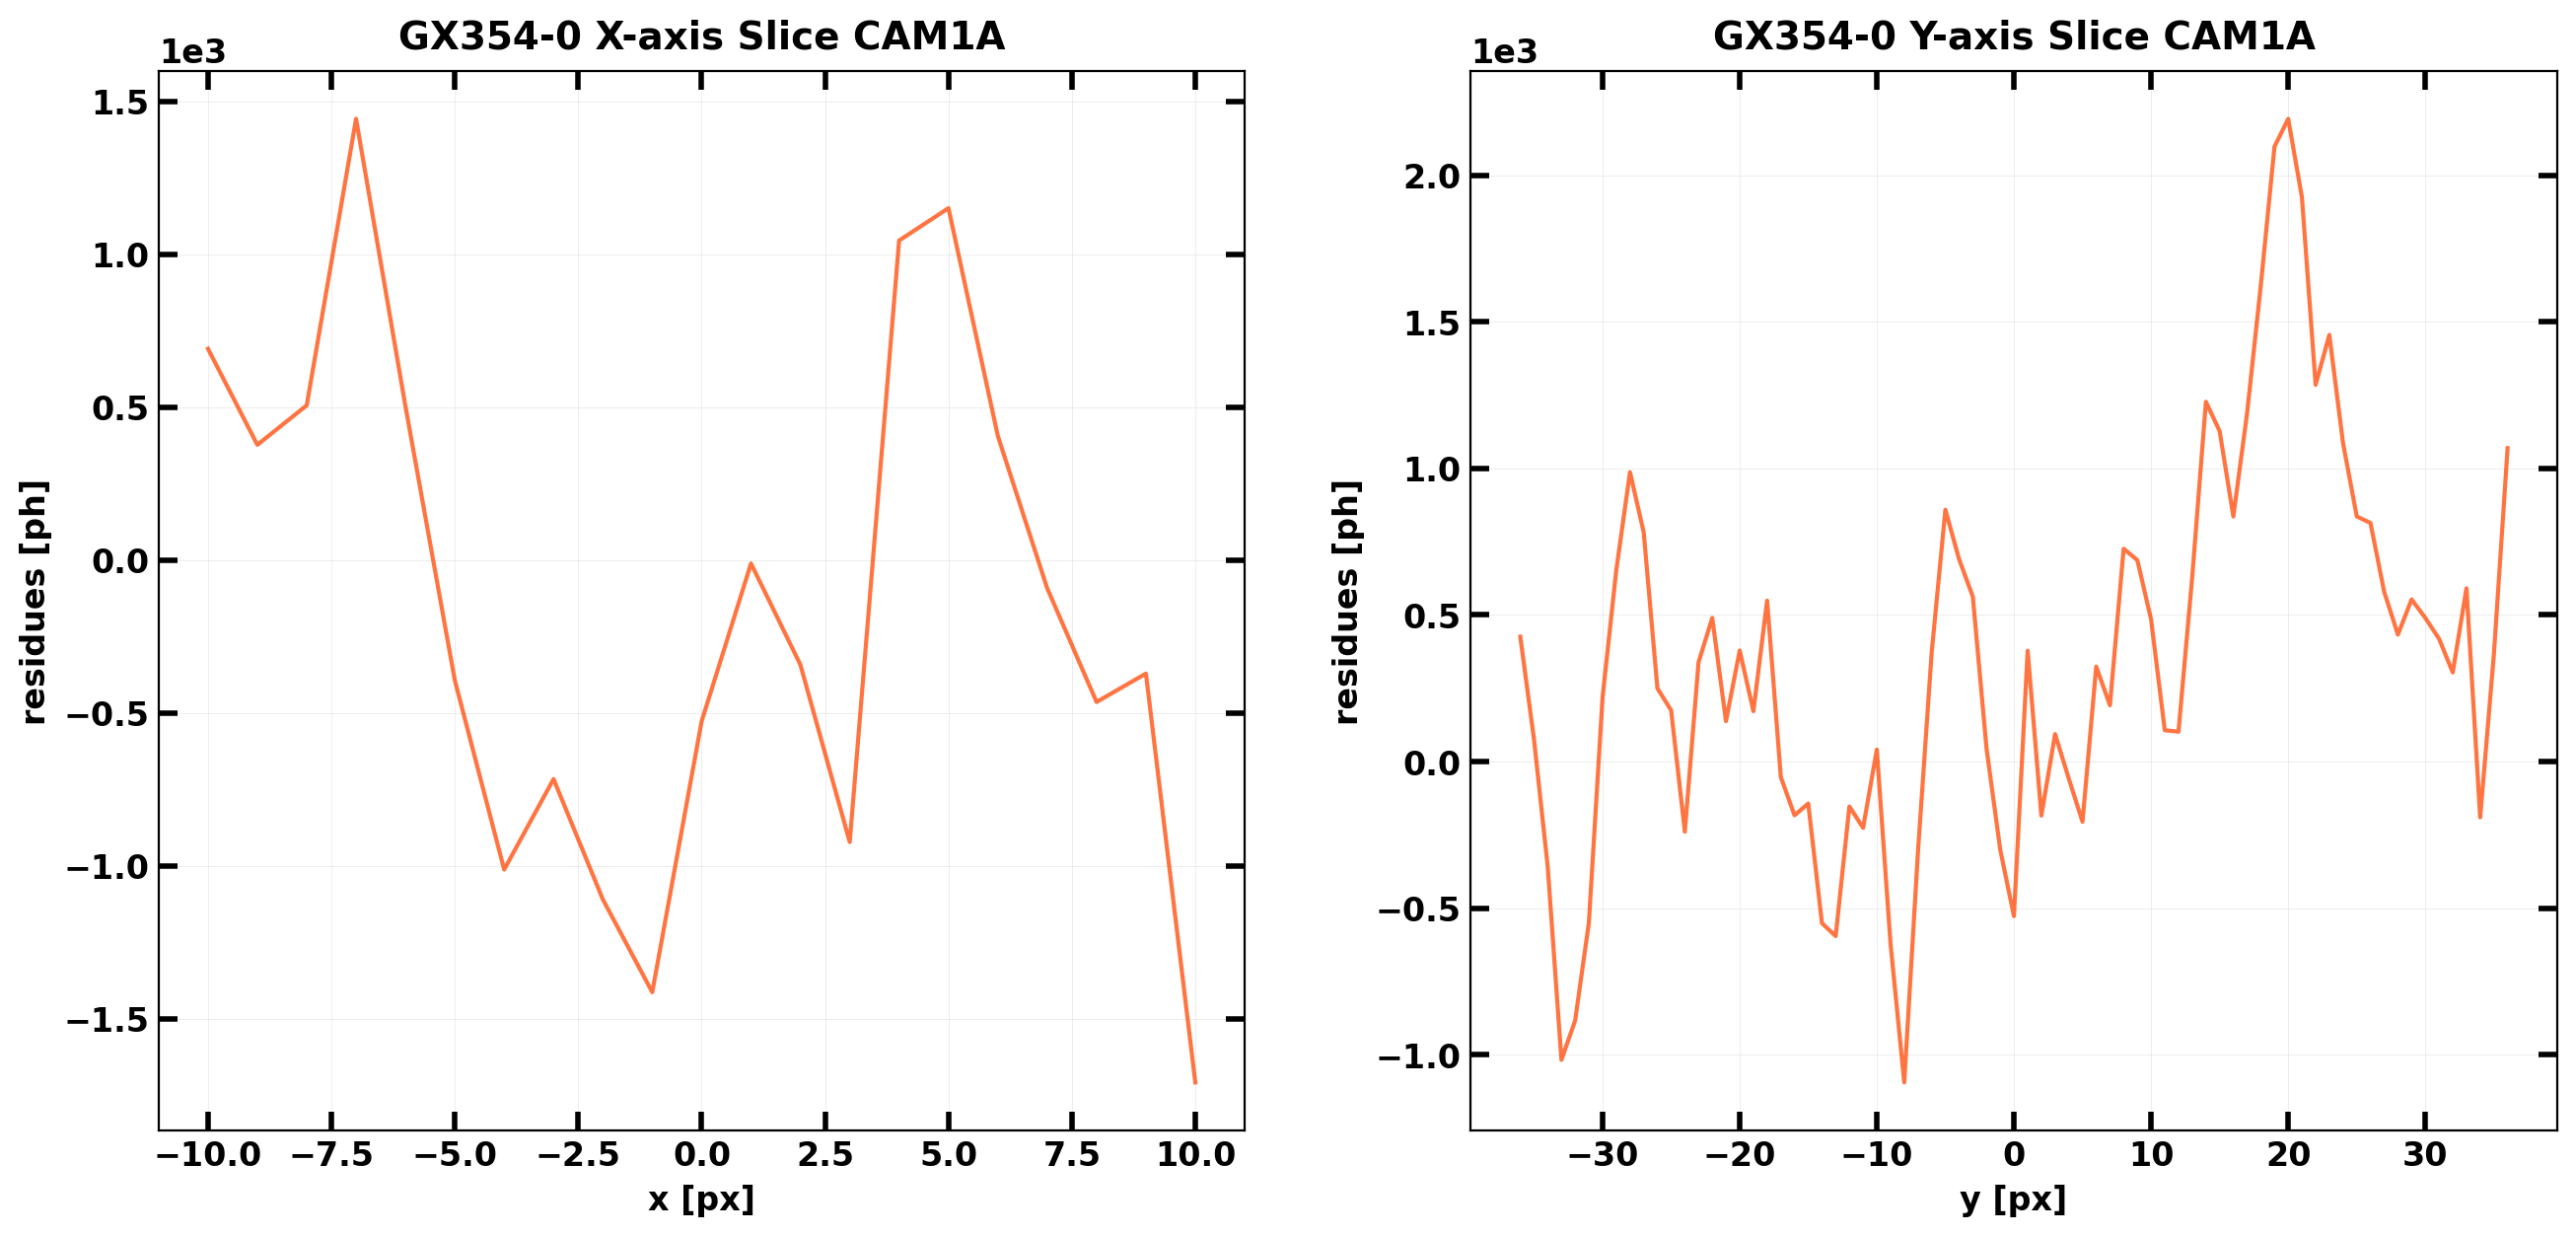

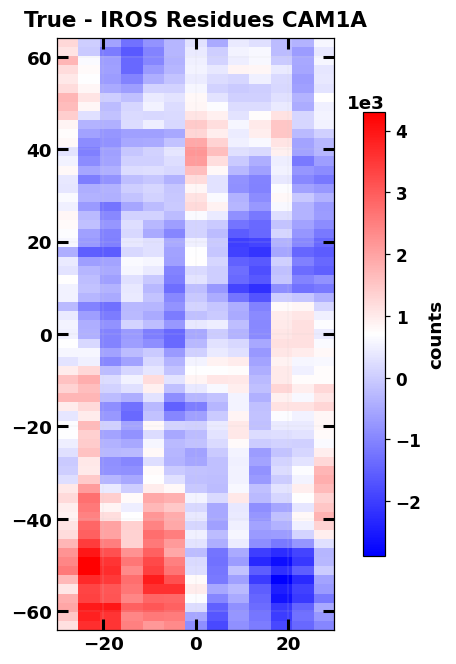

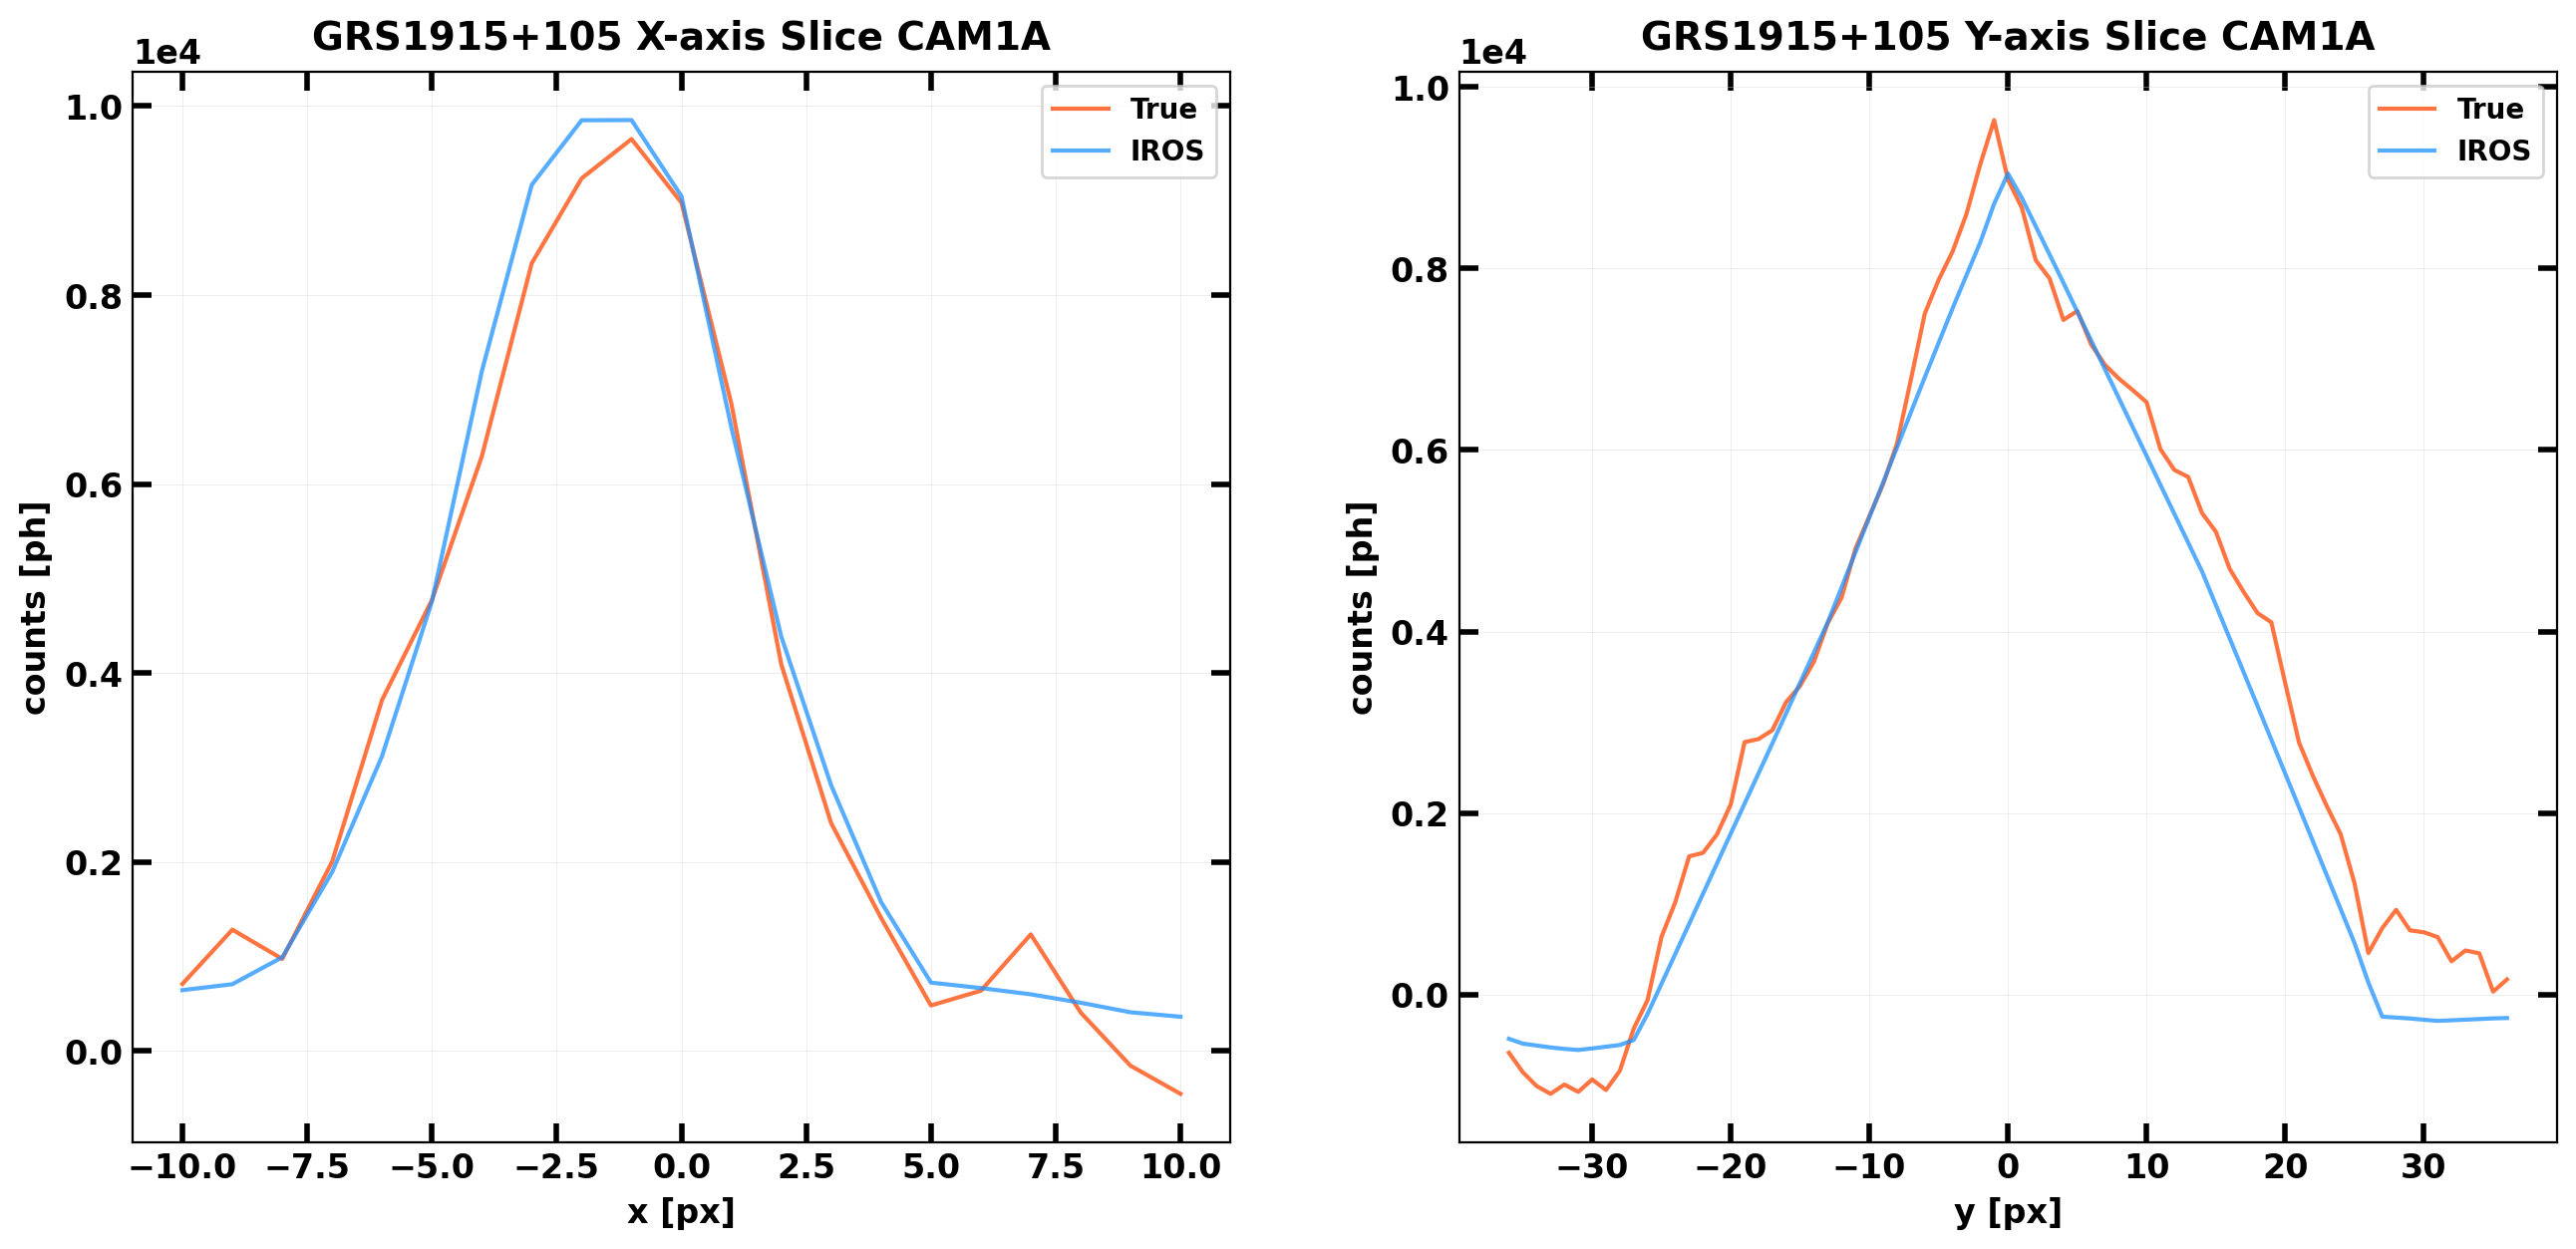

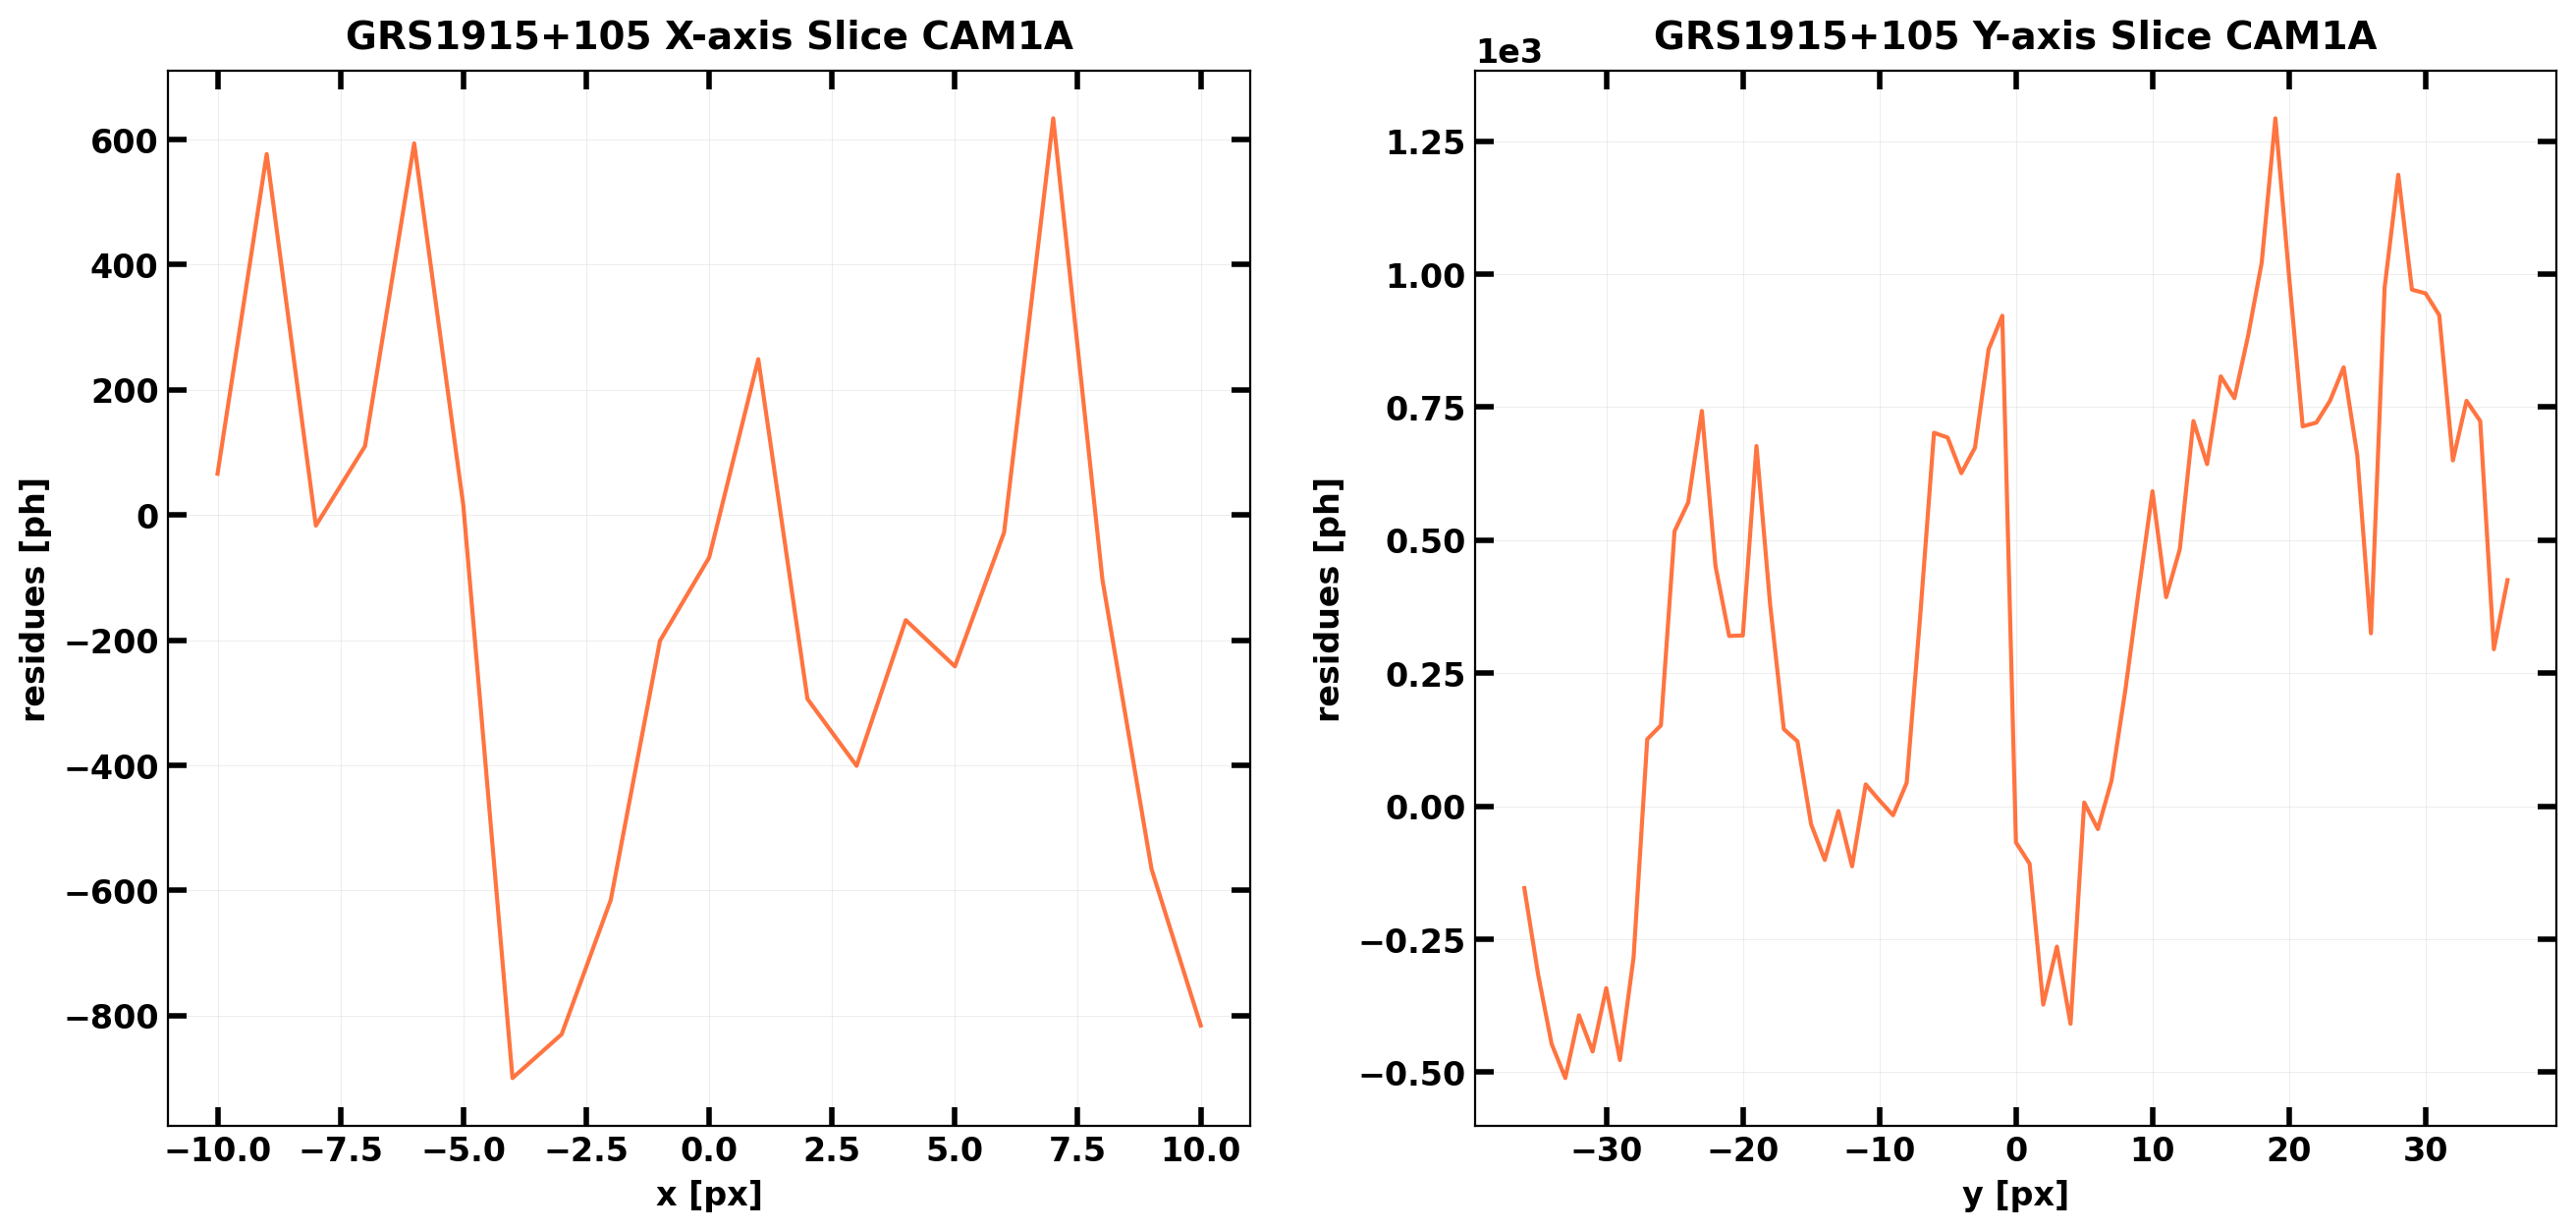

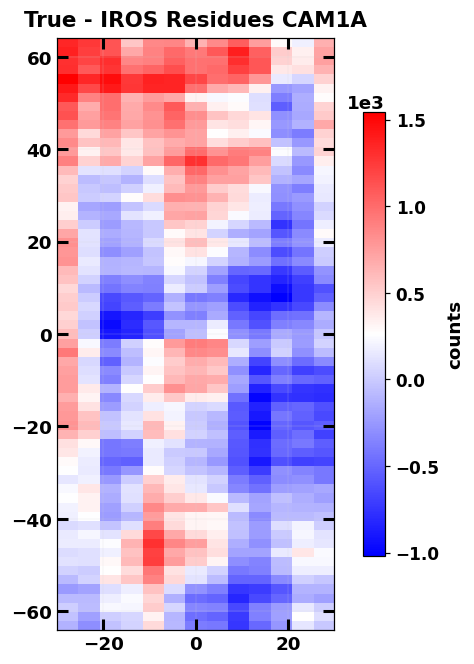

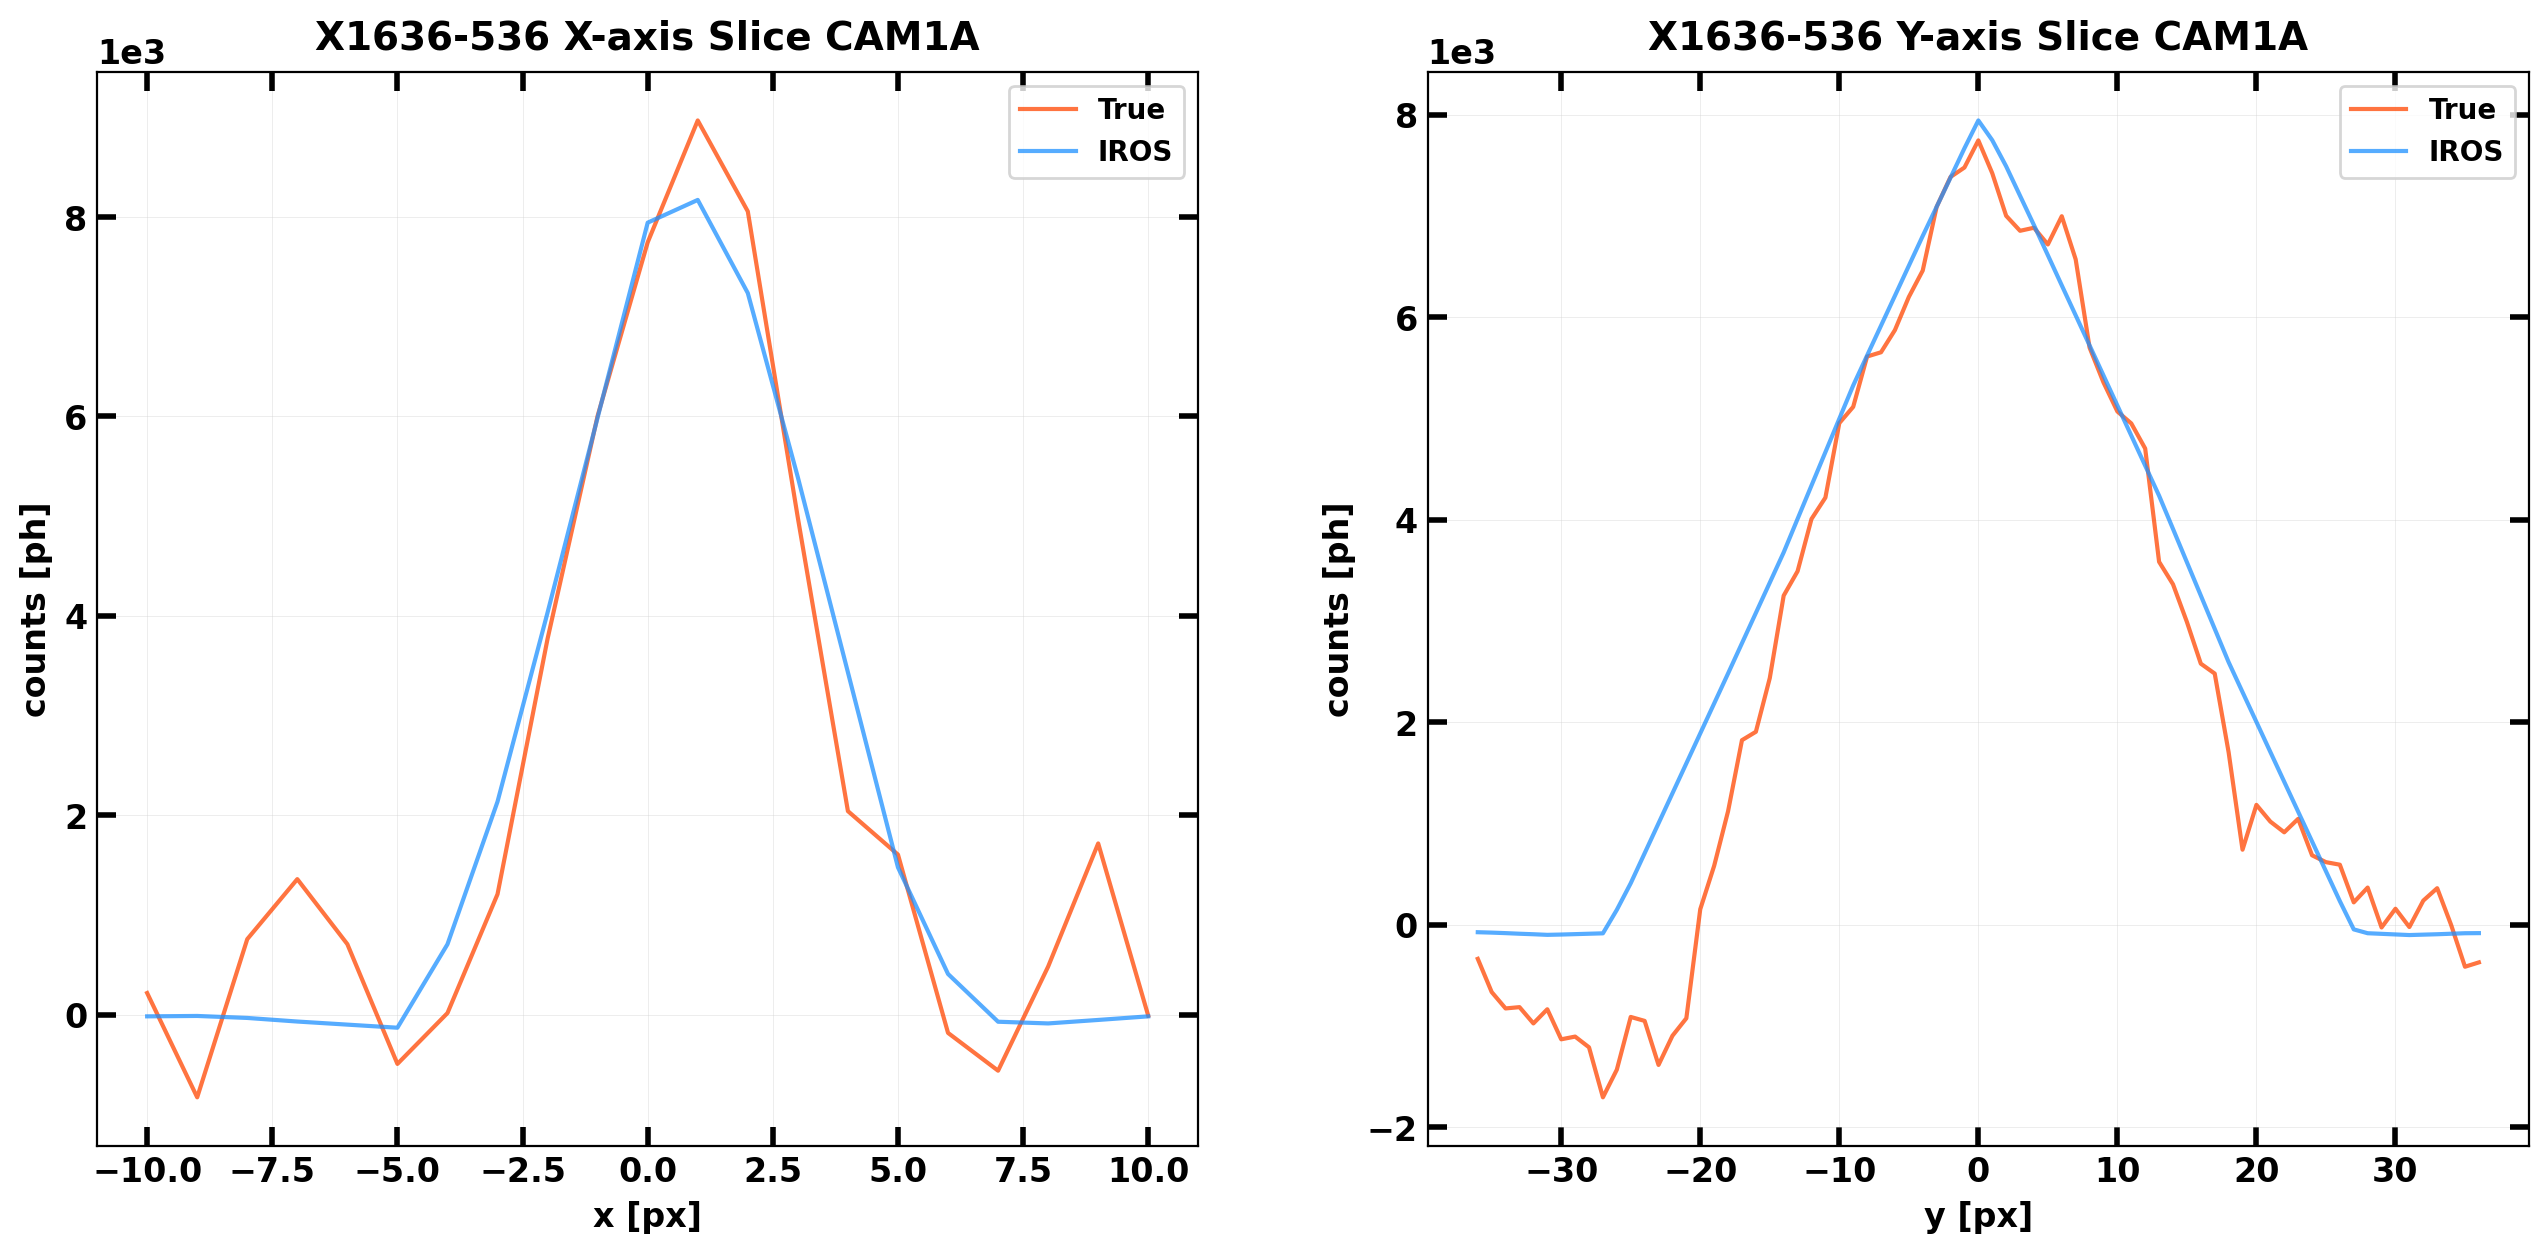

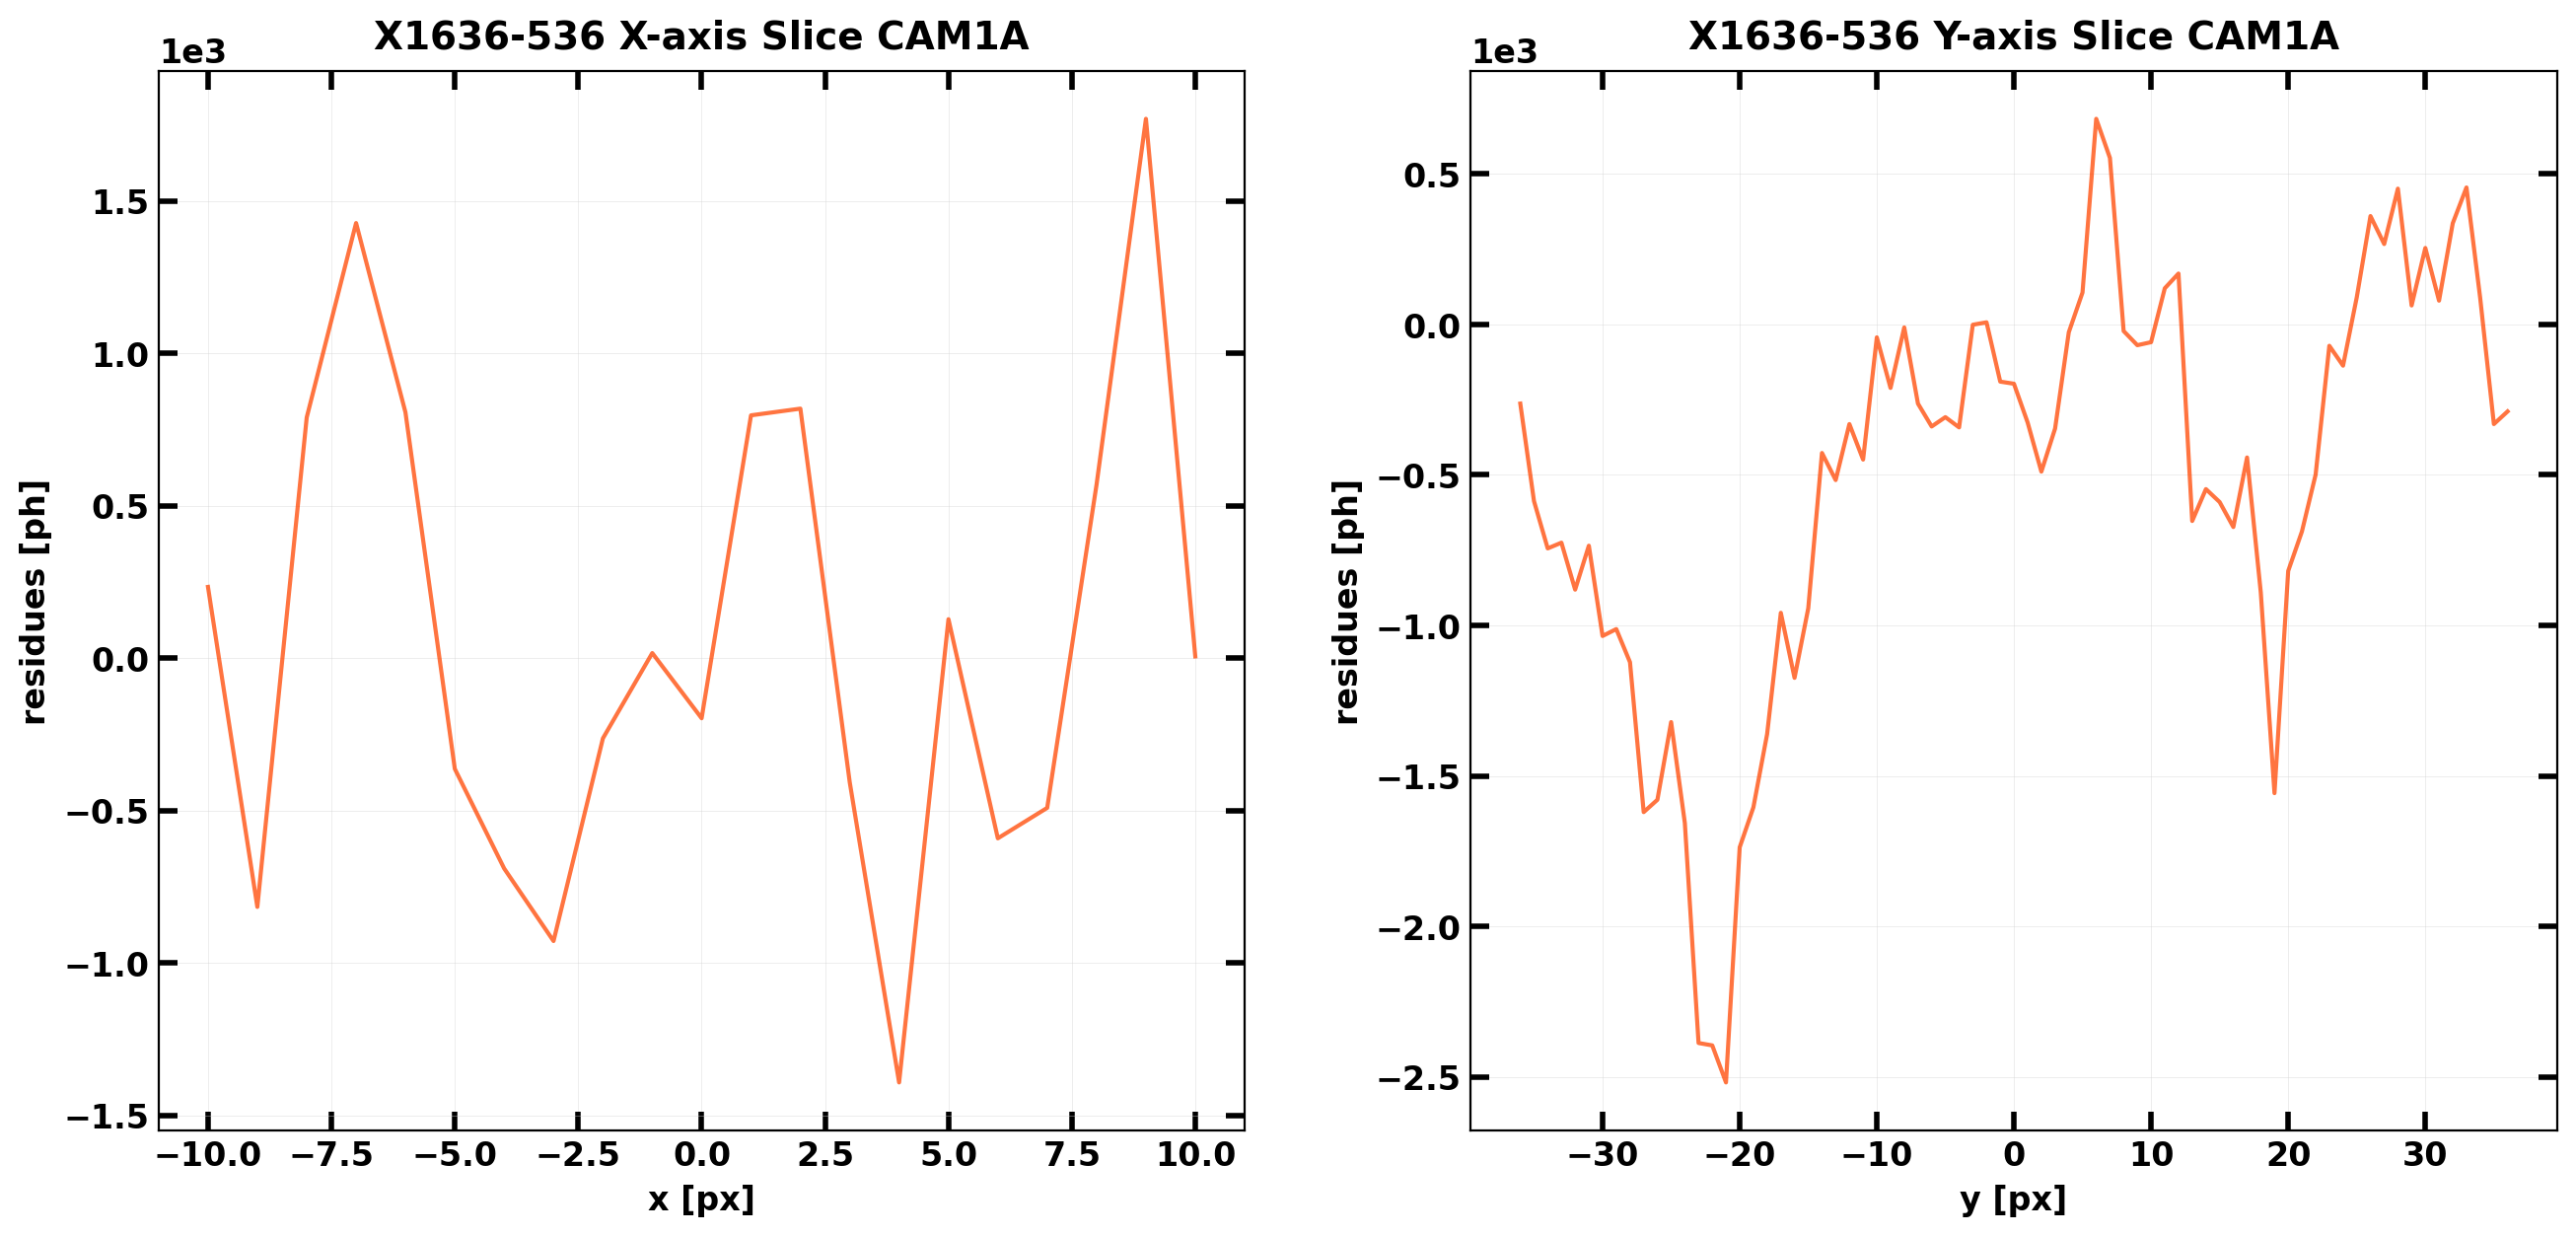

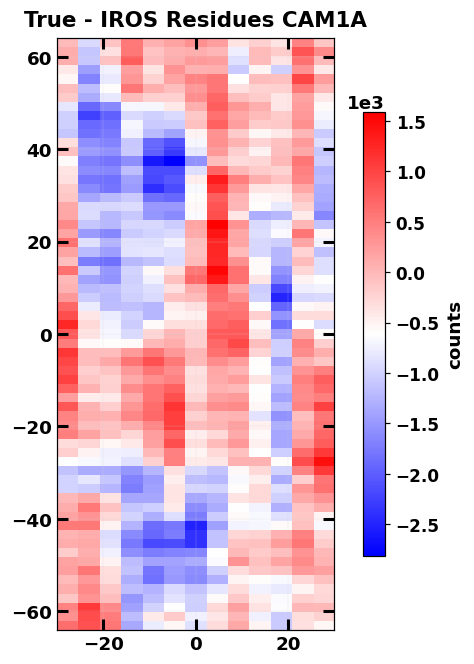

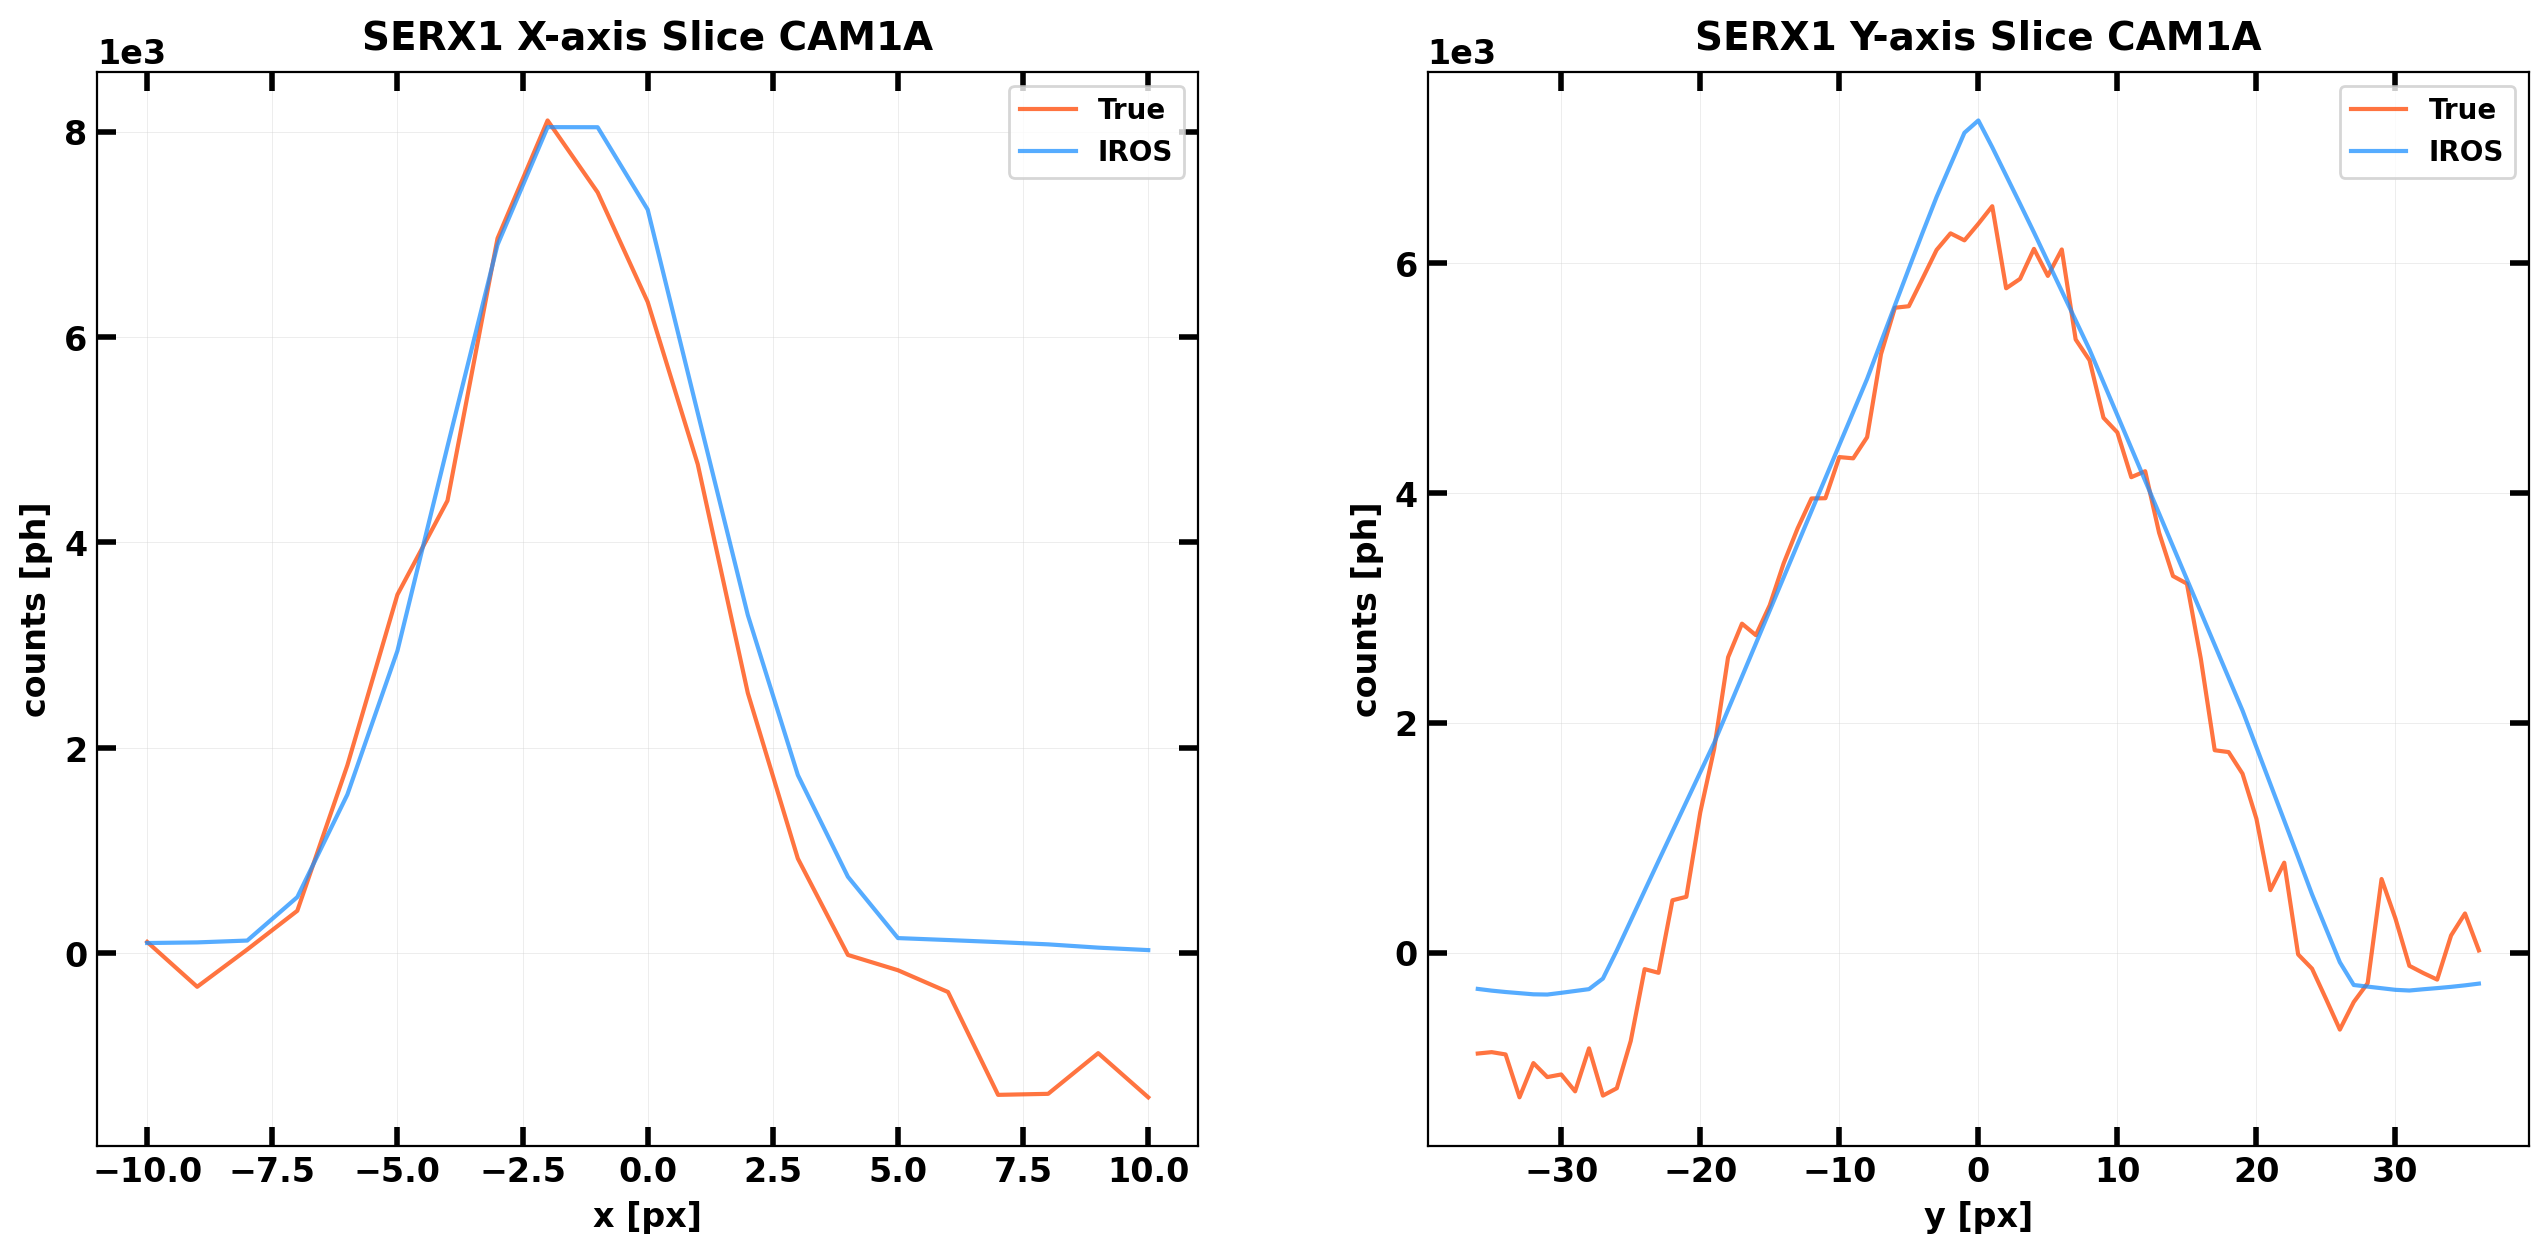

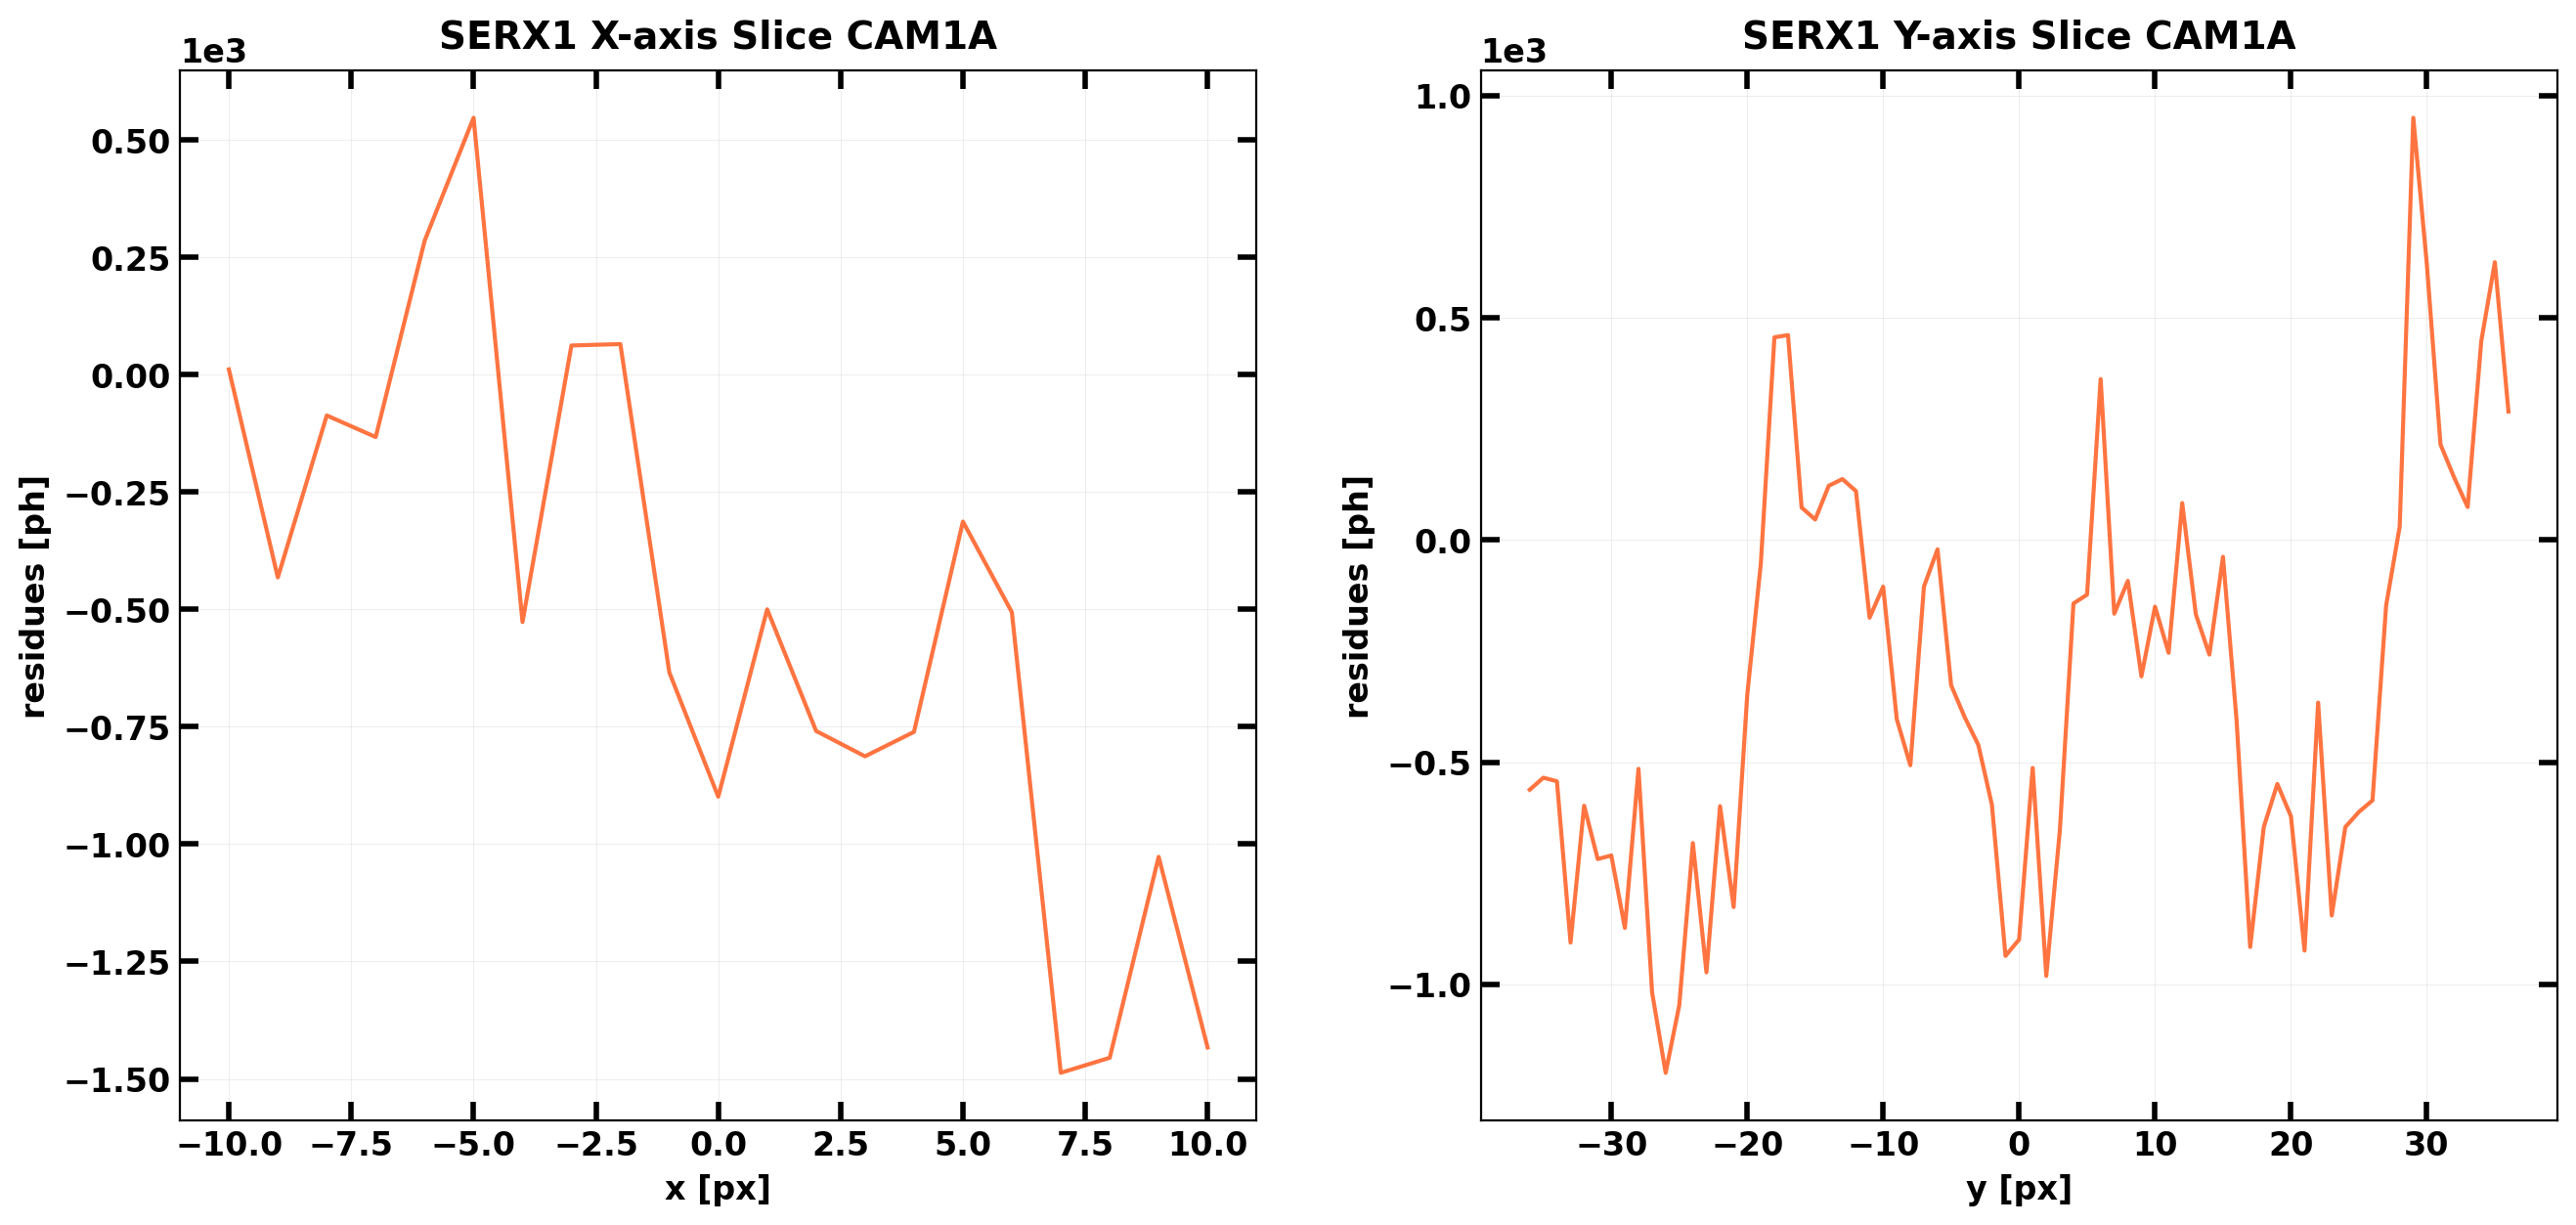

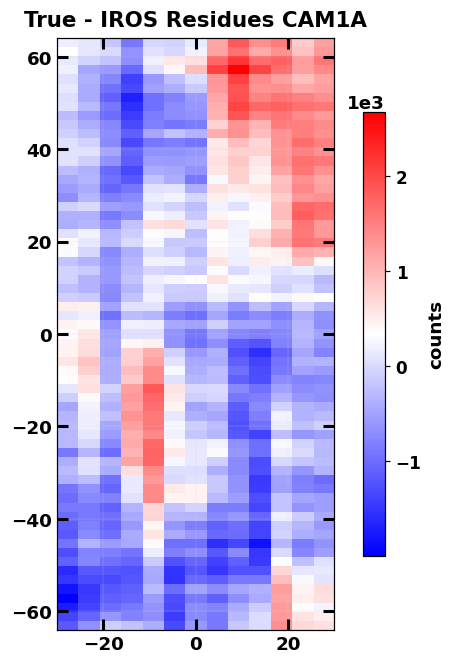

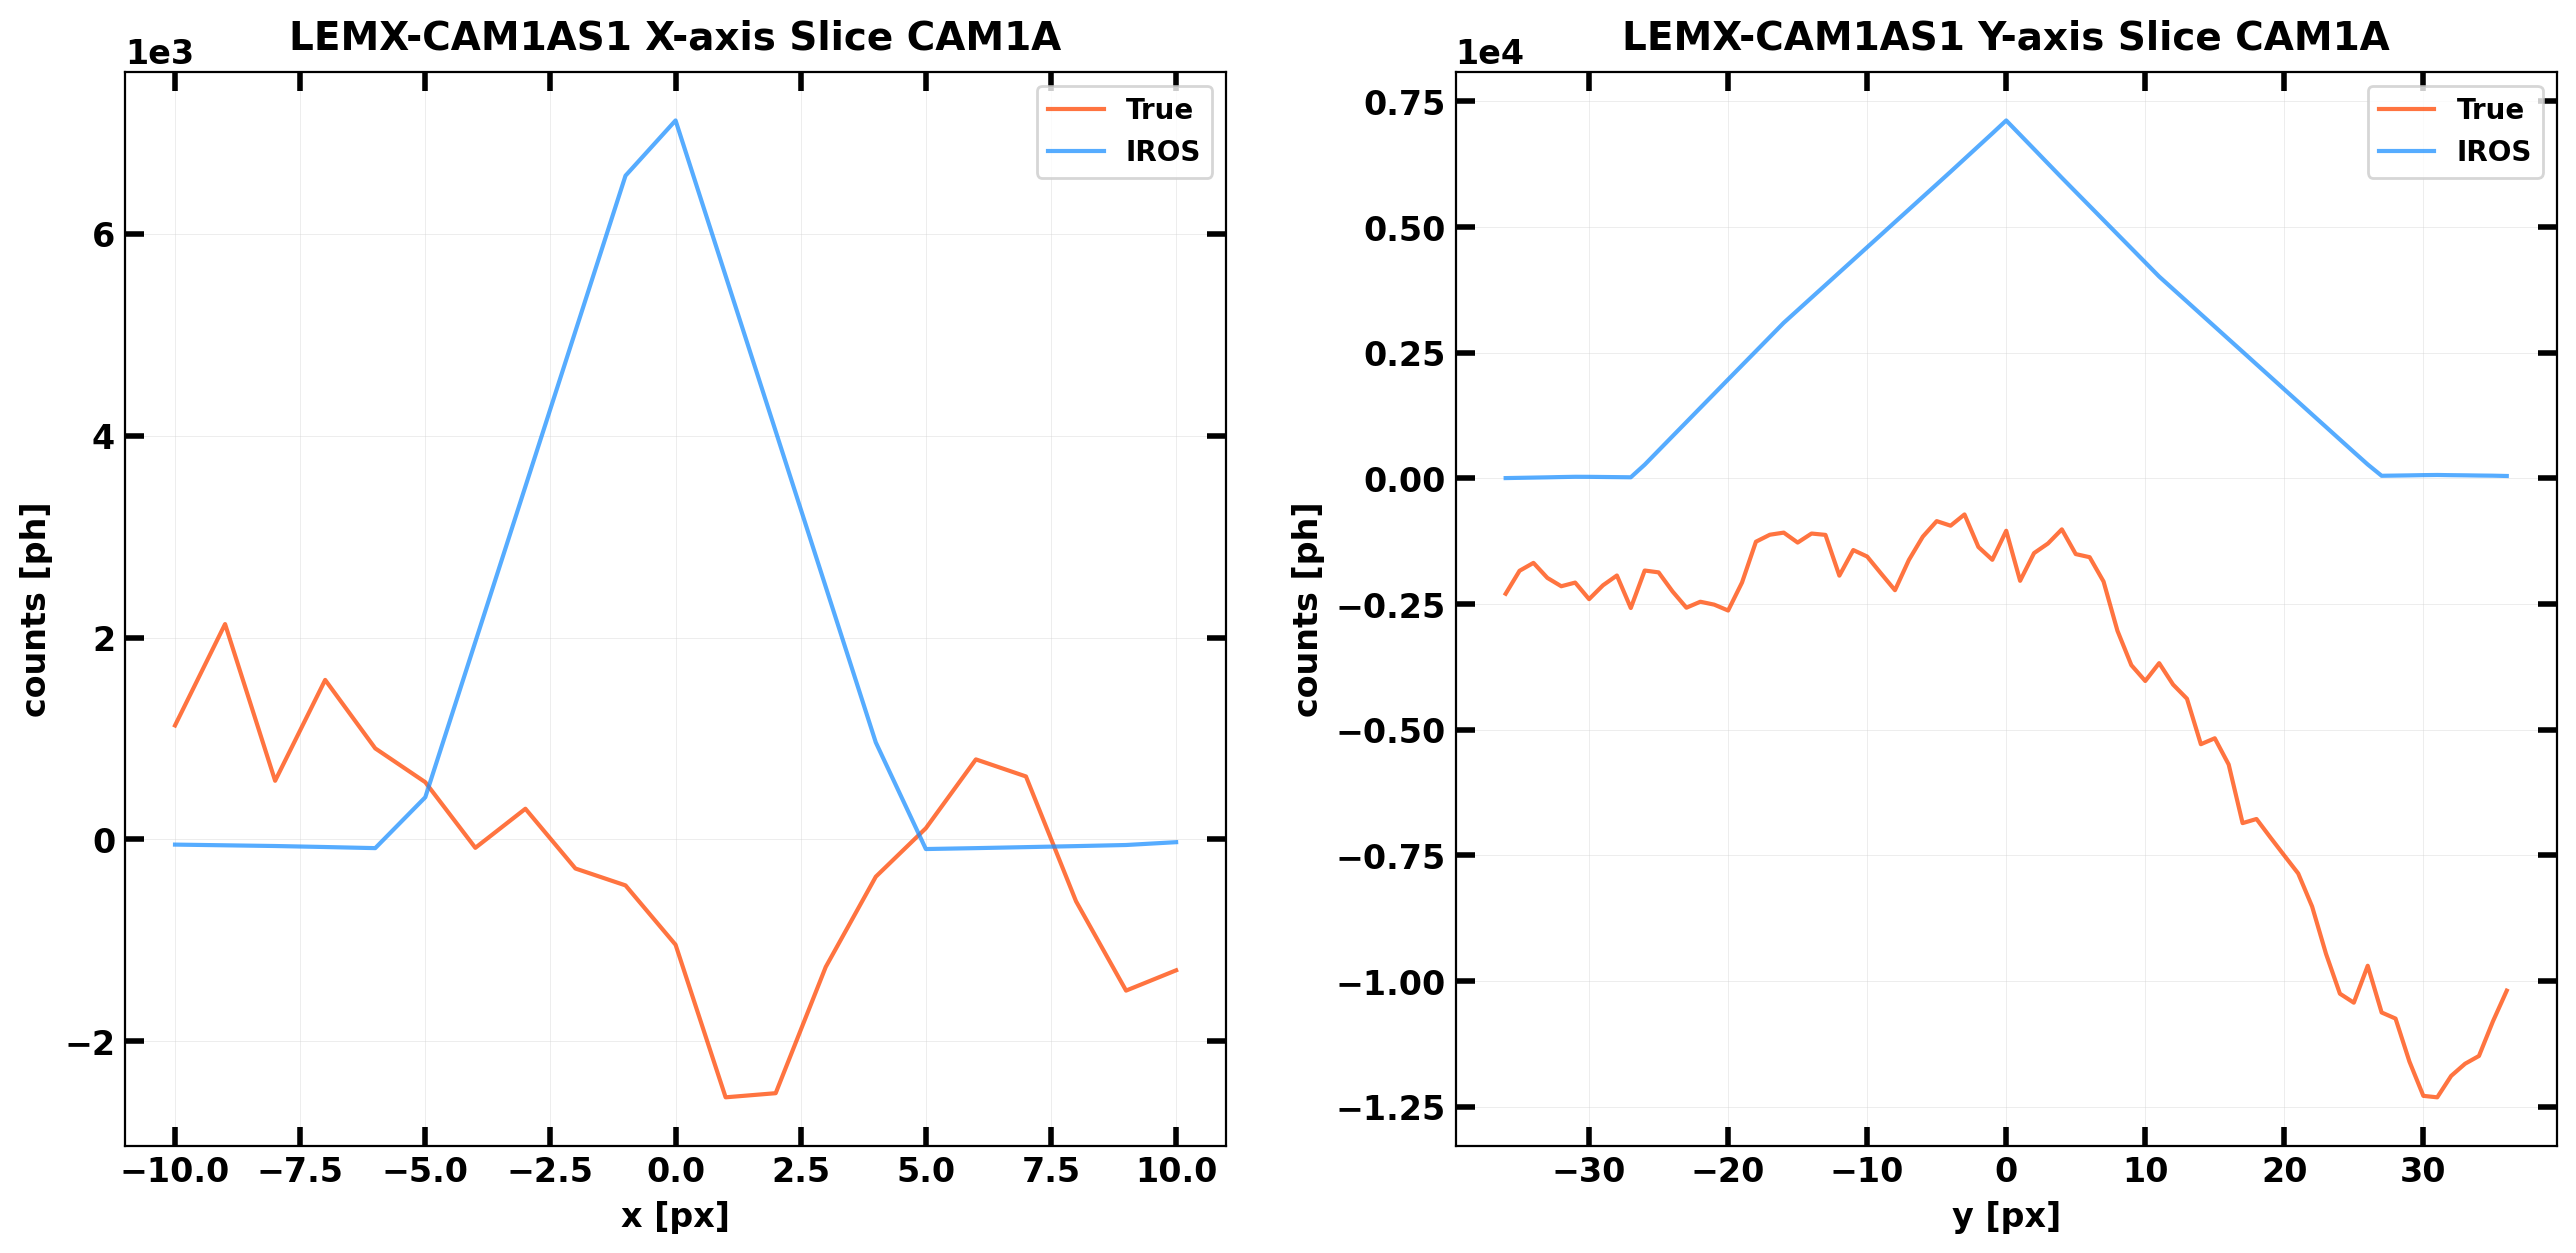

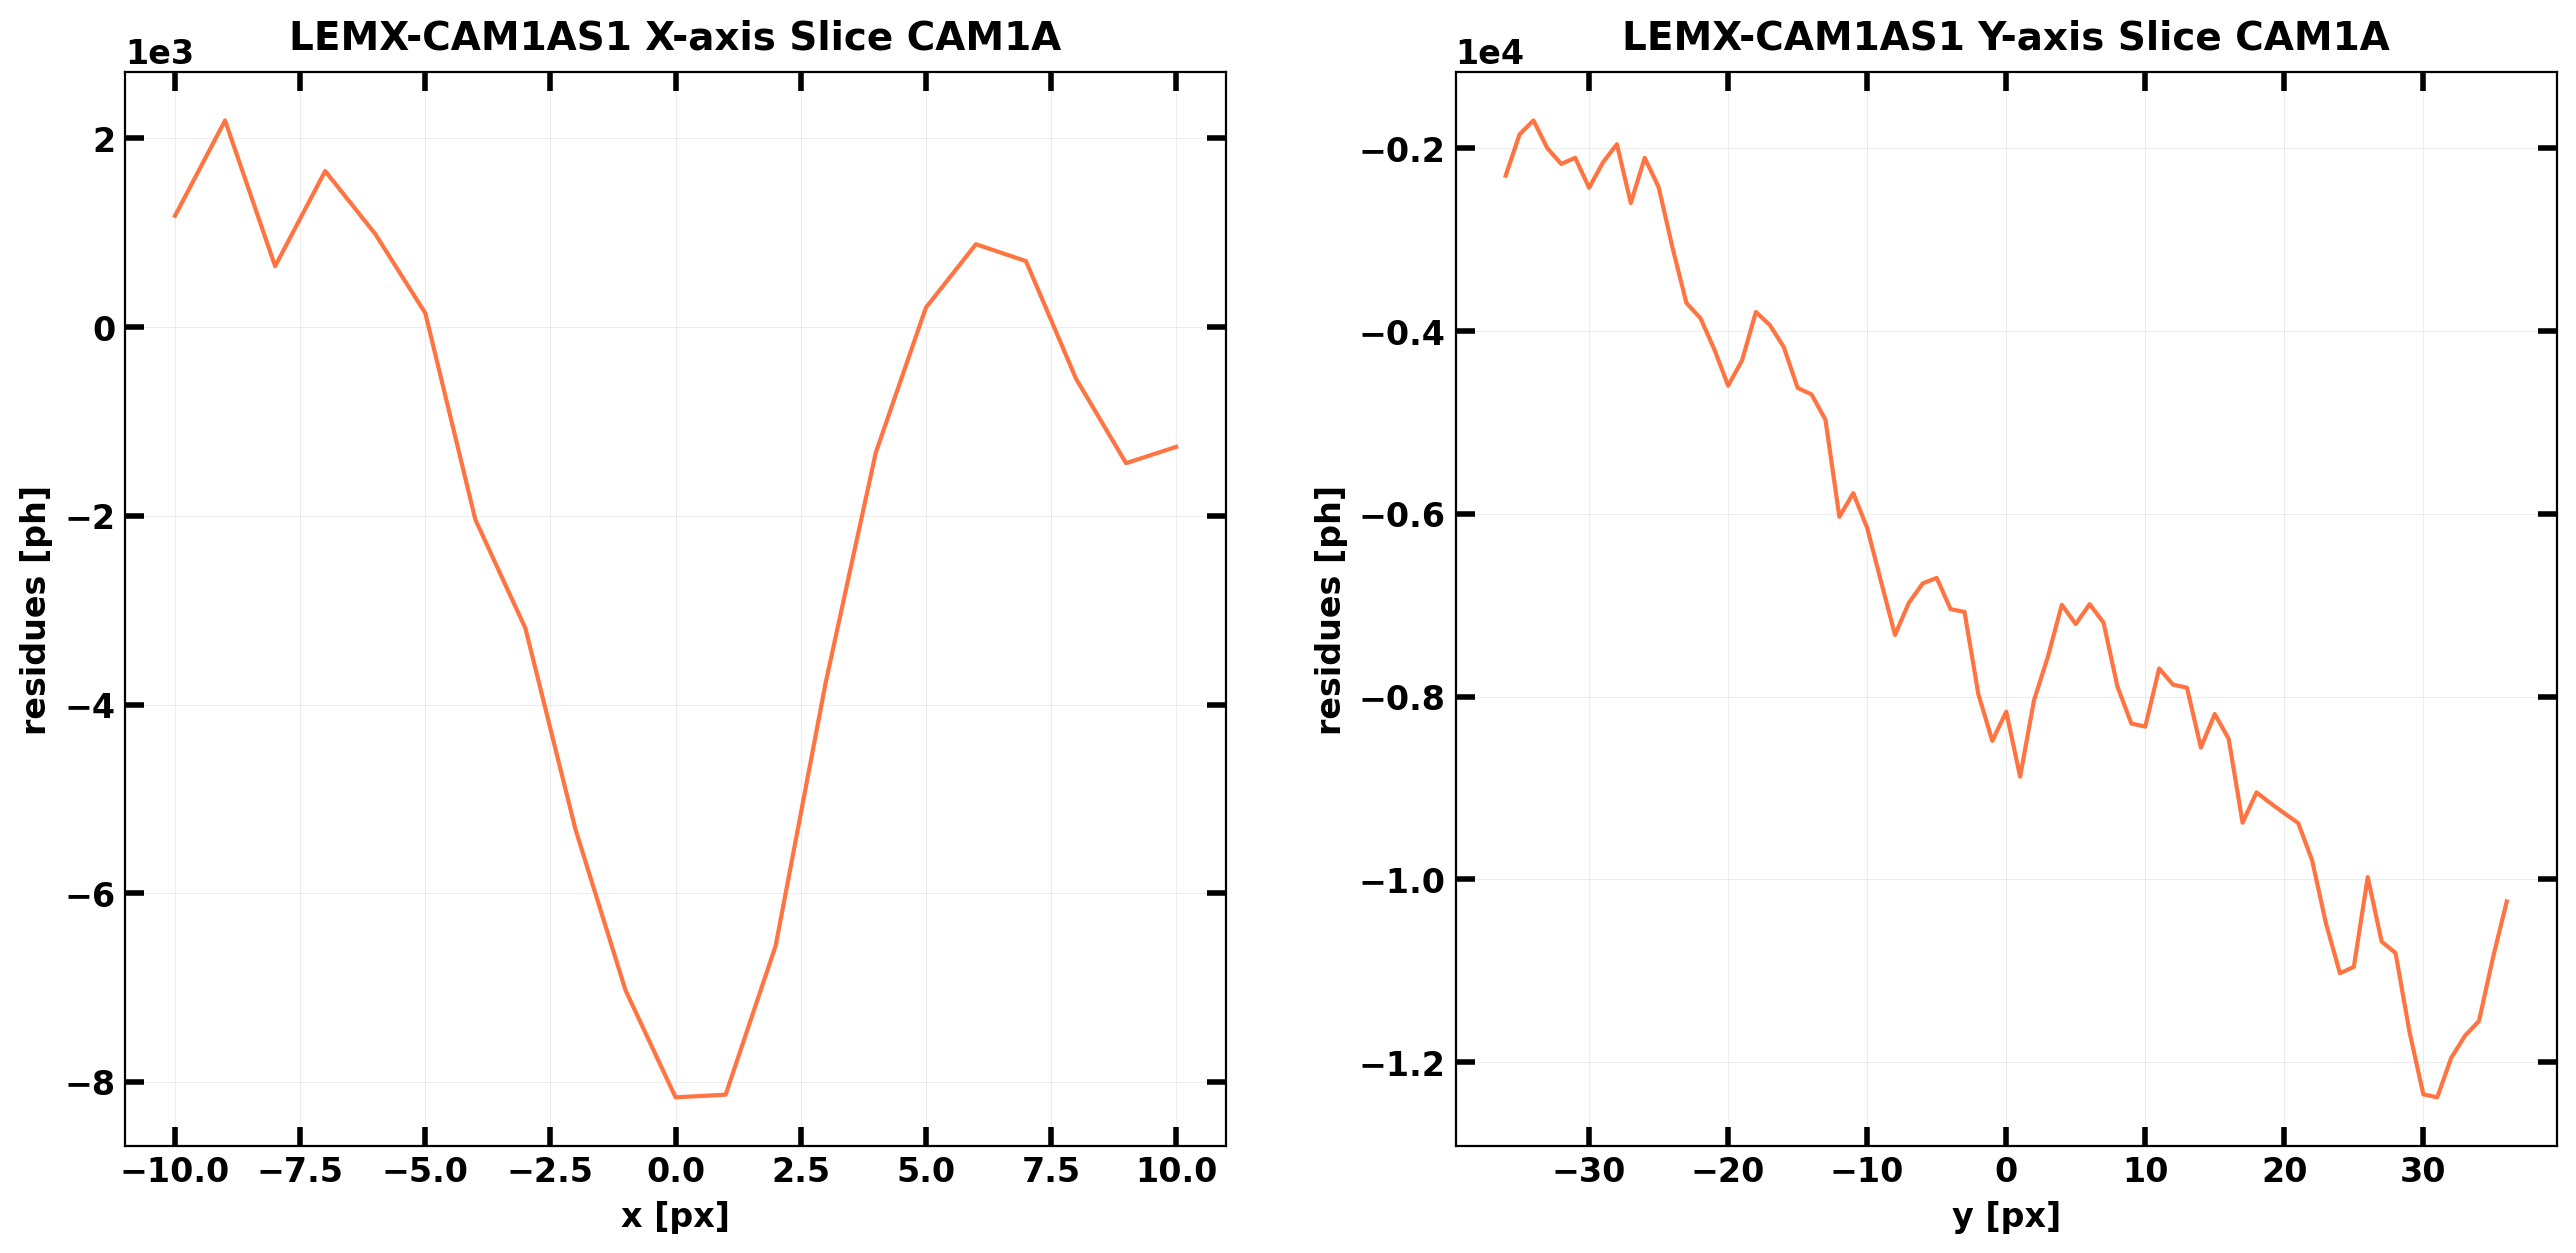

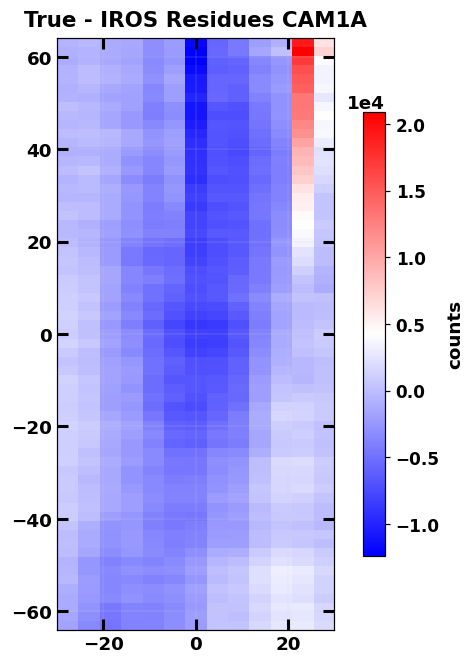

In [11]:
cropx, cropy = (
    int(wfm.specs["slit_deltax"] * UPX / wfm.specs["mask_deltax"] + 5),
    int(wfm.specs["slit_deltay"] * UPY / wfm.specs["mask_deltay"] + 5),
)
ds.reconstruction_plot(
    true_sky=simul_sky_camA,
    log=log_camA,
    crp=(cropy, cropx),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    savepath=is_img,
)